# Figuras de la tesis — generador

Escribe en `research/figures/` los PNG que espera cada `\includegraphics` de
`research/main.tex`. Las figuras salen **sin título ni subtítulo dentro de la imagen**
(eso va en el `\caption`) y sobre fondo blanco. Lo que en realidad es una tabla se
emite como `tabular` para pegar en el `.tex`, no como PNG.

`notebooks/dataset_report.ipynb` sigue siendo la fuente de las figuras del conjunto
(`annotations_per_pair`, `class_geometry`, `boxes_per_split`, `unreachable_events`,
`boxes_per_window`, `window_example`).

De arriba a abajo. Secciones 1–6: sólo `data/cleaned/`. Sección 7: además un
`checkpoint` y el caché de `data/processed/`; si falta alguno, sus celdas avisan y
siguen. Sección 8: plantillas, los números se editan en la celda. Sección 9: índice y
bloques `\begin{figure}`.

## 0. Setup

In [1]:
import json
import logging
import sys
import textwrap
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch, PathPatch, Rectangle
from matplotlib.path import Path as MplPath

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from core.config import P, settings  # noqa: E402
from core.setup import setup_project_path  # noqa: E402

setup_project_path(PROJECT_DIR)
logging.getLogger("domain.annotations").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

FIGURE_DIR = PROJECT_DIR / "research" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = PROJECT_DIR / "data" / "processed"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
LOG_DIR = PROJECT_DIR / "logs"

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
print("proyecto:", PROJECT_DIR)
print("figuras :", FIGURE_DIR.relative_to(PROJECT_DIR))

proyecto: /home/nhrot/Prog/tesis-primate
figuras : research/figures


In [2]:
# --- Estilo ------------------------------------------------------------------
SURFACE = "#ffffff"
INK = "#0b0b0b"
INK_2 = "#525252"
MUTED = "#8a8a8a"
GRID = "#e3e3e3"
BASELINE = "#c4c4c4"

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # slots categóricos 1-4
CRITICAL = "#d03b3b"
WARNING = "#eda100"
GOOD = "#1baf7a"
BLUE = "#2a78d6"
BLUE_FADED = "#b7d3f6"
BLUE_INK = "#0d366b"
PANEL = "#f3f3f3"  # relleno de caja de diagrama

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "savefig.edgecolor": SURFACE,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 9,
        "text.color": INK,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 10,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2,
    }
)


def style_value_axis(ax, axis="x"):
    """Rejilla fina sólo en el eje de valor; sin espina de línea base en ese eje."""
    ax.grid(True, axis=axis, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if axis == "x":
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_color(BASELINE)
    else:
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_color(BASELINE)


_K = 0.5523  # constante de control del arco circular en una Bezier cúbica


def _square_path(x0, y0, w, h):
    return MplPath(
        [(x0, y0), (x0 + w, y0), (x0 + w, y0 + h), (x0, y0 + h), (x0, y0)],
        [MplPath.MOVETO] + [MplPath.LINETO] * 3 + [MplPath.CLOSEPOLY],
    )


def _rounded_path(x0, y0, w, h, rx, ry, side="right"):
    """Rectángulo con las dos esquinas de `side` redondeadas: el extremo de dato."""
    rx, ry = min(abs(rx), abs(w)), min(abs(ry), abs(h) / 2)
    if rx <= 0 or ry <= 0 or w == 0 or h == 0:
        return _square_path(x0, y0, w, h)
    x1, y1 = x0 + w, y0 + h

    if side == "right":
        verts = [
            (x0, y0),
            (x1 - rx, y0),
            (x1 - rx + rx * _K, y0),
            (x1, y0 + ry - ry * _K),
            (x1, y0 + ry),
            (x1, y1 - ry),
            (x1, y1 - ry + ry * _K),
            (x1 - rx + rx * _K, y1),
            (x1 - rx, y1),
            (x0, y1),
            (x0, y0),
        ]
    else:  # "top"
        verts = [
            (x0, y0),
            (x1, y0),
            (x1, y1 - ry),
            (x1, y1 - ry + ry * _K),
            (x1 - rx + rx * _K, y1),
            (x1 - rx, y1),
            (x0 + rx, y1),
            (x0 + rx - rx * _K, y1),
            (x0, y1 - ry + ry * _K),
            (x0, y1 - ry),
            (x0, y0),
        ]
    codes = [
        MplPath.MOVETO,
        MplPath.LINETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CLOSEPOLY,
    ]
    return MplPath(verts, codes)


def _x_per_y(ax):
    """Unidades de x que se dibujan tan largas como una unidad de y."""
    box = ax.get_position()
    width_in = ax.figure.get_figwidth() * box.width
    height_in = ax.figure.get_figheight() * box.height
    x_range = abs(np.diff(ax.get_xlim())[0])
    y_range = abs(np.diff(ax.get_ylim())[0])
    return (x_range / width_in) / (y_range / height_in)


def barh(ax, ys, widths, color, height=0.62, left=None, radius_frac=0.30, **kw):
    """Barras horizontales con el extremo de dato redondeado. `left` apila."""
    ys = np.atleast_1d(np.asarray(ys, dtype=float))
    widths = np.asarray(widths, dtype=float)
    left = np.zeros_like(widths) if left is None else np.asarray(left, dtype=float)
    ry = height * radius_frac
    rx = ry * _x_per_y(ax)
    for y, w, x0 in zip(ys, widths, left):
        ax.add_patch(
            PathPatch(
                _rounded_path(x0, y - height / 2, w, height, rx, ry, "right"),
                facecolor=color,
                edgecolor="none",
                **kw,
            )
        )
    return ax


def barv(ax, xs, heights, color, width=0.68, radius_frac=0.30, bottom=None, **kw):
    """Barras verticales con la punta redondeada."""
    xs = np.atleast_1d(np.asarray(xs, dtype=float))
    heights = np.asarray(heights, dtype=float)
    bottom = np.zeros_like(heights) if bottom is None else np.asarray(bottom, dtype=float)
    rx = width * radius_frac
    ry = rx / _x_per_y(ax)
    for x, h, y0 in zip(xs, heights, bottom):
        ax.add_patch(
            PathPatch(
                _rounded_path(x - width / 2, y0, width, h, rx, ry, "top"),
                facecolor=color,
                edgecolor="none",
                **kw,
            )
        )
    return ax


# --- Registro de figuras ------------------------------------------------------
FIGURES: list[dict] = []


def save(fig, name, *, where="", caption="", width=r"\textwidth", label=None):
    path = FIGURE_DIR / f"{name}.png"
    fig.savefig(path)
    FIGURES.append(
        {
            "name": name,
            "where": where,
            "caption": caption,
            "width": width,
            "label": label or f"fig:{name.replace('_', '-')}",
            "kb": path.stat().st_size / 1024,
        }
    )
    print(f"guardada -> {path.relative_to(PROJECT_DIR)}  ({path.stat().st_size / 1024:.0f} kB)")

In [3]:
# --- Helpers de diagrama ------------------------------------------------------


def canvas(width_in=10.0, height_in=5.5):
    fig, ax = plt.subplots(figsize=(width_in, height_in))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100 * height_in / width_in)
    ax.set_aspect("equal")
    ax.axis("off")
    return fig, ax


def wrap_text(text, width=None):
    """Ajusta a `width` respetando los saltos de línea que ya trae el texto."""
    text = str(text)
    if not width:
        return text
    return "\n".join(
        textwrap.fill(line, width) if line.strip() else line for line in text.split("\n")
    )


def _units_per_point(ax):
    """Unidades del lienzo que mide un punto tipográfico (lienzo de 100 de ancho)."""
    return 100.0 / (ax.figure.get_figwidth() * 72.0)


def _stack(ax, blocks):
    """Alturas y separaciones de una pila de bloques de texto, en unidades del lienzo."""
    upt = _units_per_point(ax)
    heights = [(text.count("\n") + 1) * size * 1.34 * upt for text, size, _, _ in blocks]
    gaps = [1.15 * (blocks[i][1] + blocks[i + 1][1]) / 2 * upt for i in range(len(blocks) - 1)]
    return heights, gaps, sum(heights) + sum(gaps)


def _blocks(
    title, body, foot, fs, body_fs, foot_fs, ink, body_ink, foot_ink, weight, wrap, body_wrap
):
    blocks = []
    if title:
        blocks.append((wrap_text(title, wrap), fs, ink, weight))
    if body:
        blocks.append((wrap_text(body, body_wrap or wrap or 30), body_fs, body_ink, "normal"))
    if foot:
        blocks.append((wrap_text(foot, body_wrap or wrap or 30), foot_fs, foot_ink, "normal"))
    return blocks


def node(
    ax,
    cx,
    cy,
    w,
    h=None,
    title="",
    body=None,
    foot=None,
    *,
    fill=PANEL,
    edge=BASELINE,
    ink=INK,
    body_ink=INK_2,
    foot_ink=MUTED,
    lw=1.1,
    fs=9.0,
    body_fs=7.8,
    foot_fs=7.0,
    weight="bold",
    dashed=False,
    wrap=None,
    body_wrap=None,
    radius=1.4,
    pad_pt=9.0,
    zorder=2,
):
    """Caja redondeada centrada en (cx, cy) con hasta tres bloques de texto apilados.

    Con `h=None` la caja se ajusta al texto: es lo que evita las cajas medio vacías y
    los títulos encimados cuando el contenido cambia de largo.
    """
    blocks = _blocks(
        title, body, foot, fs, body_fs, foot_fs, ink, body_ink, foot_ink, weight, wrap, body_wrap
    )
    heights, gaps, total = _stack(ax, blocks)
    if h is None:
        h = total + 2 * pad_pt * _units_per_point(ax)

    ax.add_patch(
        FancyBboxPatch(
            (cx - w / 2, cy - h / 2),
            w,
            h,
            boxstyle=f"round,pad=0,rounding_size={radius}",
            linewidth=lw,
            edgecolor=edge,
            facecolor=fill,
            linestyle=(0, (4, 3)) if dashed else "-",
            zorder=zorder,
            mutation_aspect=1,
        )
    )

    y = cy + total / 2
    for i, (text, size, color, wt) in enumerate(blocks):
        ax.text(
            cx,
            y - heights[i] / 2,
            text,
            ha="center",
            va="center",
            fontsize=size,
            color=color,
            fontweight=wt,
            zorder=zorder + 1,
            linespacing=1.32,
        )
        y -= heights[i] + (gaps[i] if i < len(gaps) else 0)
    return cx, cy, w, h


def node_height(
    ax,
    title,
    body=None,
    foot=None,
    *,
    fs=9.0,
    body_fs=7.8,
    foot_fs=7.0,
    wrap=None,
    body_wrap=None,
    pad_pt=9.0,
):
    blocks = _blocks(
        title, body, foot, fs, body_fs, foot_fs, INK, INK_2, MUTED, "bold", wrap, body_wrap
    )
    return _stack(ax, blocks)[2] + 2 * pad_pt * _units_per_point(ax)


def flow_row(ax, items, cy, *, margin=2.5, gap=2.6, h=None, arrow_color=BLUE, arrows=True, **kw):
    """Fila de cajas que reparte el ancho del lienzo, con flechas entre ellas.

    `items` es una lista de dicts con `title` y, opcionalmente, `body`, `foot` y `kw`.
    El alto es común a toda la fila: el de la caja que más texto lleva.
    """
    n = len(items)
    w = (100 - 2 * margin - (n - 1) * gap) / n
    if h is None:
        h = max(
            node_height(
                ax,
                item["title"],
                item.get("body"),
                item.get("foot"),
                fs=kw.get("fs", 9.0),
                body_fs=kw.get("body_fs", 7.8),
                foot_fs=kw.get("foot_fs", 7.0),
                wrap=item.get("kw", {}).get("wrap", kw.get("wrap")),
                body_wrap=kw.get("body_wrap"),
            )
            for item in items
        )
    boxes = []
    for i, item in enumerate(items):
        cx = margin + w / 2 + i * (w + gap)
        options = dict(kw)
        options.update(item.get("kw", {}))
        boxes.append(
            node(ax, cx, cy, w, h, item["title"], item.get("body"), item.get("foot"), **options)
        )
        if arrows and i:
            arrow(ax, (cx - w / 2 - gap, cy), (cx - w / 2, cy), color=arrow_color, lw=1.3)
    return boxes


def arrow(ax, start, end, *, color=MUTED, lw=1.2, rad=0.0, dashed=False, head="-|>", zorder=1):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        zorder=zorder,
        arrowprops=dict(
            arrowstyle=head,
            color=color,
            linewidth=lw,
            shrinkA=1.5,
            shrinkB=1.5,
            linestyle=(0, (4, 3)) if dashed else "-",
            connectionstyle=f"arc3,rad={rad}",
            mutation_scale=11,
        ),
    )


def elbow(ax, points, *, color=BLUE, lw=1.3):
    """Conector en ángulo recto con punta de flecha en el último tramo."""
    xs, ys = zip(*points)
    ax.plot(xs, ys, color=color, linewidth=lw, solid_capstyle="round", zorder=1)
    arrow(ax, points[-2], points[-1], color=color, lw=lw)


def caption_at(ax, x, y, text, *, fs=7.8, color=INK_2, ha="center", va="center", wrap=None, **kw):
    ax.text(
        x,
        y,
        wrap_text(text, wrap),
        ha=ha,
        va=va,
        fontsize=fs,
        color=color,
        linespacing=1.35,
        **kw,
    )


def chip(ax, cx, cy, text, color=BLUE, *, fs=7.5, pad=1.0, ink=SURFACE):
    """Etiqueta pequeña de fondo lleno: para marcar una salida o un estado."""
    ax.text(
        cx,
        cy,
        text,
        ha="center",
        va="center",
        fontsize=fs,
        color=ink,
        fontweight="bold",
        zorder=5,
        bbox=dict(boxstyle=f"round,pad={pad * 0.3}", facecolor=color, edgecolor="none"),
    )

### Audio y espectrogramas

El mismo `MelSpectrogram` y el mismo `hz_to_y` que ve el modelo: si `P` cambia, las
figuras cambian con él.

In [4]:
import soundfile as sf  # noqa: E402
import torch  # noqa: E402
import torchaudio  # noqa: E402

from utils.audio import MelSpectrogram, hz_to_y, y_to_hz  # noqa: E402

MEL = MelSpectrogram(P)


def load_segment(audio_path, start_s=0.0, duration_s=3.0, params=P):
    """Trozo mono de un `.wav`, remuestreado a `params.target_sr`."""
    with sf.SoundFile(str(audio_path)) as handle:
        handle.seek(int(start_s * handle.samplerate))
        frames = handle.read(int(duration_s * handle.samplerate), dtype="float32", always_2d=True)
        waveform = torch.from_numpy(frames.mean(axis=1))
        if handle.samplerate != params.target_sr:
            waveform = torchaudio.functional.resample(waveform, handle.samplerate, params.target_sr)
    return waveform


def log_mel(waveform, params=P):
    return np.log(MEL(waveform).numpy() + params.eps)


def draw_spectrogram(ax, image, duration_s, *, params=P, cmap="magma", n_ticks=5, vrange=(2, 99.5)):
    """Espectrograma log-mel con el eje de frecuencia en el espacio mel normalizado."""
    lo, hi = np.percentile(image, vrange)
    ax.imshow(
        image,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        extent=(0, duration_s, 0, 1),
        interpolation="nearest",
        vmin=lo,
        vmax=hi,
    )
    ticks = np.linspace(0, 1, n_ticks)
    ax.set_yticks(ticks, [f"{y_to_hz(np.array([t]), params)[0] / 1000:.1f}" for t in ticks])
    ax.set_ylabel("frecuencia (kHz, eje mel)")
    ax.set_xlabel("tiempo (s)")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    return ax


def draw_box(
    ax,
    t0,
    t1,
    low_hz,
    high_hz,
    *,
    params=P,
    color=GOOD,
    label=None,
    lw=1.5,
    dashed=False,
    fs=7.5,
    label_below=False,
):
    """Caja tiempo–frecuencia sobre un espectrograma dibujado por `draw_spectrogram`."""
    y0 = float(hz_to_y(np.array([max(low_hz, params.f_min)]), params)[0])
    y1 = float(hz_to_y(np.array([min(high_hz, params.f_max)]), params)[0])
    ax.add_patch(
        FancyBboxPatch(
            (t0, y0),
            t1 - t0,
            y1 - y0,
            boxstyle="round,pad=0,rounding_size=0.012",
            linewidth=lw,
            edgecolor=color,
            facecolor="none",
            linestyle=(0, (4, 2)) if dashed else "-",
            zorder=4,
        )
    )
    if label:
        ax.text(
            t0,
            (y0 - 0.022) if label_below else (y1 + 0.014),
            label,
            color=color,
            fontsize=fs,
            fontweight="bold",
            va="top" if label_below else "bottom",
            ha="left",
            zorder=5,
        )
    return y0, y1

## 1. Los datos

`annotations`: todo `data/cleaned/`, sin excluir nada. `experiment`: el subconjunto que
selecciona `create_dataset.py`, con sus mismas constantes.

In [5]:
from create_dataset import (  # noqa: E402
    EXCLUDED_PAIRS,
    JOINED_PAIRS,
    LABEL_BY,
    LABEL_COLUMN,
    MIN_PAIR_COUNT,
)
from domain.annotations import load_annotations  # noqa: E402
from domain.species import CALL_TYPES, Species  # noqa: E402

SOURCE_DIR = settings.data_dir / "cleaned"
annotations = load_annotations(SOURCE_DIR)
annotations["pair"] = annotations.species + "/" + annotations.call_type

SPECIES_NAME = {s.name.lower(): s.value.replace("_", " ") for s in Species}
SPECIES_LATIN = {
    "aa": "Aotus azarae",
    "ac": "Ateles chamek",
    "as": "Alouatta sara",
    "cc": "Cebus cuscinus",
    "lw": "Leontocebus weddelli",
    "pt": "Plecturocebus toppini",
    "sb": "Saimiri boliviensis",
    "sm": "Sapajus macrocephalus",
}
CALL_NAME = {
    f"{s.name.lower()}/{code}": label.replace("_", " ")
    for s, codes in CALL_TYPES.items()
    for code, label in codes.items()
}
CALL_NAME["lw/trino"] = "trino (tr, tj, tt y tf fusionados)"


def select_experiment_from(df):
    """El mismo filtro de `create_dataset.select_experiment`, sin releer el disco."""
    out = df.copy()
    excluded = out[["species", "call_type"]].apply(tuple, axis=1).isin(EXCLUDED_PAIRS)
    out = out[~excluded]
    out["low_freq_hz"] = out["low_freq_hz"].clip(lower=P.f_min)
    for old_pairs, new_pair in JOINED_PAIRS.items():
        for old_pair in old_pairs:
            joined = (out["species"] == old_pair[0]) & (out["call_type"] == old_pair[1])
            out.loc[joined, ["species", "call_type"]] = new_pair
    pairs = out[["species", "call_type"]].apply(tuple, axis=1)
    counts = pairs.value_counts()
    keep = counts[counts >= MIN_PAIR_COUNT].index
    out = out[pairs.isin(keep)].copy()
    out["label"] = LABEL_COLUMN[LABEL_BY](out)
    out["pair"] = out["label"]
    return out


experiment = select_experiment_from(annotations)
CLASSES = sorted(experiment.pair.unique())


def recording_table():
    cache = CACHE_DIR / "recording_durations.csv"
    if cache.exists():
        return pd.read_csv(cache)
    rows = []
    for wav in sorted(SOURCE_DIR.rglob("*.wav")):
        try:
            info = sf.info(str(wav))
        except Exception:
            continue
        folder = next((p.name for p in wav.parents if "__" in p.name), wav.parent.name)
        rows.append(
            {
                "audio_path": str(wav),
                "species": folder.split("__")[-1].lower(),
                "duration_s": info.duration,
                "has_annotation": wav.with_suffix(".txt").exists(),
            }
        )
    table = pd.DataFrame(rows)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    table.to_csv(cache, index=False)
    return table


recordings = recording_table()

print(f"{len(annotations):,} anotaciones | {annotations.pair.nunique()} pares distintos")
print(
    f"{len(recordings):,} grabaciones en data/cleaned ({recordings.duration_s.sum() / 3600:,.0f} h)"
)
print(f"experimento: {len(experiment):,} anotaciones | {len(CLASSES)} clases")
print(", ".join(CLASSES))

19,042 anotaciones | 57 pares distintos
3,350 grabaciones en data/cleaned (33 h)
experimento: 17,605 anotaciones | 25 clases
aa/gc, aa/hm, aa/sc, ac/bc, ac/chc, ac/gc, ac/sc, as/bc, as/hc, lw/cs, lw/sqc, lw/ta, lw/trino, lw/vc, pt/dc, pt/sqc, sb/pcc, sb/ppc, sb/sc, sb/spc, sm/cc, sm/fs, sm/hic, sm/pc, sm/sc


In [6]:
# --- Elegir ejemplos reales de forma determinista -----------------------------


def pick_annotation(pair, *, df=None, rank=0, source=None):
    """Anotación de `pair` cuya duración es la `rank`-ésima más cercana a la mediana."""
    table = annotations if df is None else df
    rows = table[table.pair == pair]
    if source is not None:
        rows = rows[rows.audio_path.str.contains(source)]
    if rows.empty:
        raise LookupError(f"sin anotaciones para {pair}")
    order = (rows.duration_s - rows.duration_s.median()).abs().sort_values().index
    return rows.loc[order[min(rank, len(order) - 1)]]


def busiest_segment(pair, window_s=6.0, *, df=None, n_events=6):
    """Ventana de `window_s` con un número de eventos de `pair` cercano a `n_events`."""
    table = annotations if df is None else df
    rows = table[table.pair == pair]
    best = []
    for audio_path, group in rows.groupby("audio_path"):
        for start in group.begin_time_s.to_numpy():
            inside = group[(group.begin_time_s >= start) & (group.end_time_s <= start + window_s)]
            if len(inside):
                best.append(
                    (
                        abs(len(inside) - n_events),
                        -float(inside.duration_s.sum()),
                        audio_path,
                        start,
                    )
                )
    best.sort()
    _, _, audio_path, start = best[0]
    inside = table[
        (table.audio_path == audio_path)
        & (table.end_time_s > start)
        & (table.begin_time_s < start + window_s)
    ]
    return audio_path, float(start), inside


def segment_around(row, pad_ratio=0.9, min_pad_s=0.25, params=P):
    """Inicio y duración de un trozo centrado en la anotación `row`."""
    pad = max(row.duration_s * pad_ratio, min_pad_s)
    start = max(row.begin_time_s - pad, 0.0)
    return start, float(row.duration_s + 2 * pad)

## 2. Capítulo 1 — Generalidades

### 2.1 `annotation_example` (Figura 1.1)

guardada -> research/figures/annotation_example.png  (147 kB)


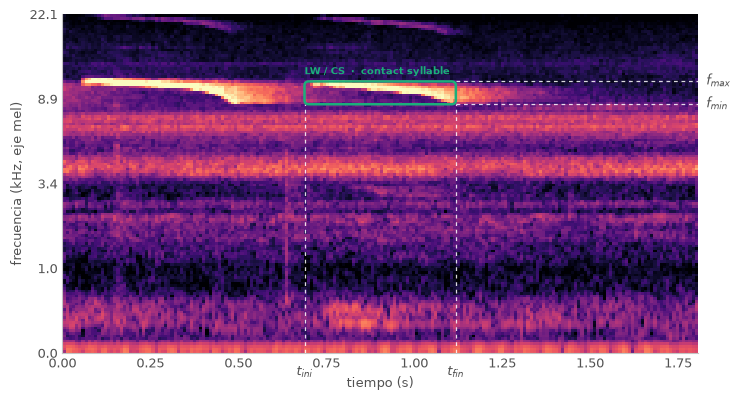

In [7]:
row = pick_annotation("lw/cs")
start_s, duration_s = segment_around(row, pad_ratio=1.6, min_pad_s=0.5)
waveform = load_segment(row.audio_path, start_s, duration_s)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
draw_spectrogram(ax, log_mel(waveform), duration_s)

t0, t1 = row.begin_time_s - start_s, row.end_time_s - start_s
y0, y1 = draw_box(
    ax,
    t0,
    t1,
    row.low_freq_hz,
    row.high_freq_hz,
    color=GOOD,
    label=f"{row.species.upper()} / {row.call_type.upper()}  ·  {CALL_NAME.get(row.pair, '')}",
    lw=1.8,
)

guide = dict(color=SURFACE, linewidth=0.9, linestyle=(0, (3, 3)), zorder=3, alpha=0.85)
for t in (t0, t1):
    ax.plot([t, t], [0, y0], **guide)
for y in (y0, y1):
    ax.plot([t1, duration_s], [y, y], **guide)

for t, name in ((t0, r"$t_{ini}$"), (t1, r"$t_{fin}$")):
    ax.annotate(
        name,
        xy=(t, 0),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
        color=INK_2,
        fontsize=9,
    )
for y, name in ((y0, r"$f_{min}$"), (y1, r"$f_{max}$")):
    ax.annotate(
        name,
        xy=(1, y),
        xycoords=("axes fraction", "data"),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        color=INK_2,
        fontsize=9,
        annotation_clip=False,
    )

save(
    fig,
    "annotation_example",
    where="Cap. 1, sección 1.1 (Figura 1.1) - antes de la Tabla 1.1",
    width=r"0.85\textwidth",
    caption=(
        "Ejemplo de anotación tiempo--frecuencia tal como la produce el analista en "
        "Raven: cada evento se delimita en tiempo y en banda de frecuencia, y se "
        "etiqueta con especie y tipo de llamada. Las cuatro coordenadas rotuladas son "
        "las cuatro primeras componentes de la ecuación~\\eqref{eq:tupla}."
    ),
)
plt.show()

### 2.2 `output_forms` (Figura 1.2)

Las tres capas derivan de la anotación de referencia, no de tres modelos entrenados.

guardada -> research/figures/output_forms.png  (339 kB)


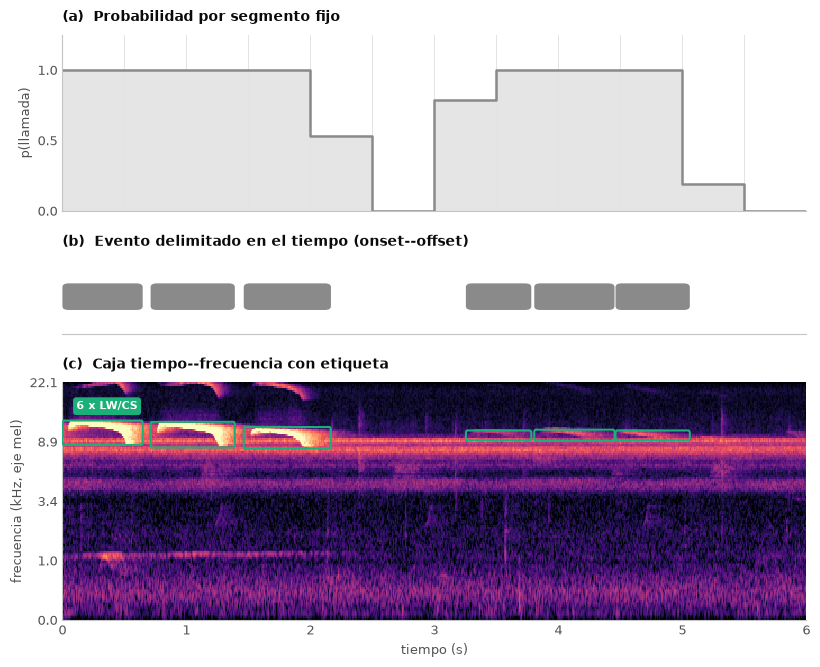

In [8]:
TARGET = "lw/cs"
duration_s = 6.0
audio_path, start_s, inside = busiest_segment(
    TARGET, window_s=duration_s, df=experiment, n_events=6
)
inside = inside[inside.pair == TARGET]
waveform = load_segment(audio_path, start_s, duration_s)
image = log_mel(waveform)
events = [
    (r.begin_time_s - start_s, r.end_time_s - start_s, r.low_freq_hz, r.high_freq_hz, r.pair)
    for r in inside.itertuples()
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9.6, 7.6),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 0.42, 1.35], "hspace": 0.30},
)

ax = axes[0]
seg = 0.5
edges = np.arange(0, duration_s + seg, seg)
covered = np.array(
    [
        sum(max(0, min(e, hi) - max(s, lo)) for s, e, *_ in events) / seg
        for lo, hi in zip(edges[:-1], edges[1:])
    ]
)
probability = np.clip(covered * 1.6, 0, 1)
ax.step(
    np.repeat(edges, 2)[1:-1],
    np.repeat(probability, 2),
    color=MUTED,
    linewidth=1.8,
    where="pre",
)
ax.fill_between(
    np.repeat(edges, 2)[1:-1], np.repeat(probability, 2), step="pre", color=GRID, alpha=0.9
)
for edge in edges:
    ax.axvline(edge, color=GRID, linewidth=0.7, zorder=0)
ax.set_ylim(0, 1.25)
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylabel("p(llamada)")
ax.set_title("(a)  Probabilidad por segmento fijo", fontsize=10, pad=10)

ax = axes[1]
for t0, t1, *_ in events:
    ax.add_patch(
        FancyBboxPatch(
            (t0, 0.32),
            t1 - t0,
            0.36,
            boxstyle="round,pad=0,rounding_size=0.05",
            facecolor=MUTED,
            edgecolor="none",
        )
    )
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title("(b)  Evento delimitado en el tiempo (onset--offset)", fontsize=10, pad=10)
for side in ("left", "top", "right"):
    ax.spines[side].set_visible(False)

ax = axes[2]
draw_spectrogram(ax, image, duration_s)
for i, (t0, t1, low, high, pair) in enumerate(events):
    draw_box(ax, t0, t1, low, high, color=GOOD, lw=1.5)
chip(ax, duration_s * 0.06, 0.90, f"{len(events)} x {TARGET.upper()}", GOOD, fs=8)
ax.set_title("(c)  Caja tiempo--frecuencia con etiqueta", fontsize=10, pad=10)

save(
    fig,
    "output_forms",
    where="Cap. 1, sección 1.1.3 (Figura 1.2) - cierre de 'Investigaciones anteriores'",
    caption=(
        "Las tres formas de salida que la literatura llama detección de eventos "
        "sonoros, sobre el mismo fragmento. Sólo la tercera devuelve la tupla completa "
        "de la ecuación~\\eqref{eq:tupla} y puede sustituir el insumo del analista; las "
        "dos primeras lo complementan. Es la causa C3 hecha visible."
    ),
)
plt.show()

### 2.3 `problem_tree` (Figura 1.3)

Los textos son los del capítulo 1: si allí cambian, cambialos acá.

guardada -> research/figures/problem_tree.png  (223 kB)


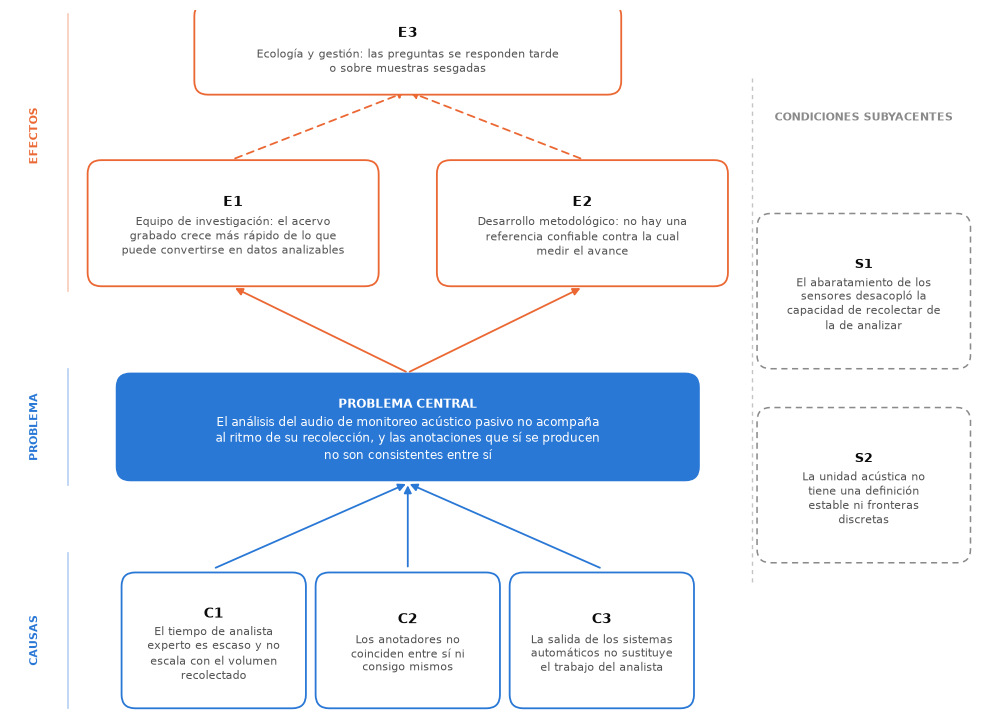

In [9]:
TREE = {
    "problem": (
        "El análisis del audio de monitoreo acústico pasivo no acompaña al ritmo de su "
        "recolección, y las anotaciones que sí se producen no son consistentes entre sí"
    ),
    "causes": [
        ("C1", "El tiempo de analista experto es escaso y no escala con el volumen recolectado"),
        ("C2", "Los anotadores no coinciden entre sí ni consigo mismos"),
        ("C3", "La salida de los sistemas automáticos no sustituye el trabajo del analista"),
    ],
    "effects": [
        (
            "E1",
            "Equipo de investigación: el acervo grabado crece más rápido de lo que puede "
            "convertirse en datos analizables",
        ),
        (
            "E2",
            "Desarrollo metodológico: no hay una referencia confiable contra la cual medir "
            "el avance",
        ),
    ],
    "indirect": (
        "E3",
        "Ecología y gestión: las preguntas se responden tarde o sobre muestras sesgadas",
    ),
    "conditions": [
        (
            "S1",
            "El abaratamiento de los sensores desacopló la capacidad de recolectar de la de analizar",
        ),
        ("S2", "La unidad acústica no tiene una definición estable ni fronteras discretas"),
    ],
}

fig, ax = canvas(12.6, 9.2)
TOP = 100 * 9.2 / 12.6  # 73.0

AXIS_X0, AXIS_X1 = 9, 73
COL = [21, 41, 61]

# --- causas (abajo) ---
for (code, text), cx in zip(TREE["causes"], COL):
    node(ax, cx, 8, 19, 14, code, text, wrap=25, fill=SURFACE, edge=BLUE, lw=1.3, fs=10)
    arrow(ax, (cx, 15.4), (cx if cx == COL[1] else 41, 24.2), color=BLUE, lw=1.3)

# --- problema central ---
node(
    ax,
    41,
    30,
    60,
    11,
    "PROBLEMA CENTRAL",
    TREE["problem"],
    wrap=64,
    fill=BLUE,
    edge=BLUE,
    ink=SURFACE,
    body_ink=SURFACE,
    fs=8.5,
    body_fs=8.6,
    lw=1.4,
)

# --- efectos directos ---
for (code, text), cx in zip(TREE["effects"], (23, 59)):
    arrow(ax, (41, 35.6), (cx, 44.4), color=SERIES[1], lw=1.3)
    node(ax, cx, 51, 30, 13, code, text, wrap=38, fill=SURFACE, edge=SERIES[1], lw=1.3, fs=10)
    arrow(ax, (cx, 57.6), (41, 64.6), color=SERIES[1], lw=1.3, dashed=True)

# --- efecto indirecto ---
code, text = TREE["indirect"]
node(ax, 41, 69, 44, 9.5, code, text, wrap=52, fill=SURFACE, edge=SERIES[1], lw=1.3, fs=10)

# --- condiciones subyacentes, fuera del eje causal ---
caption_at(ax, 88, 62, "CONDICIONES SUBYACENTES", fs=8, color=MUTED, weight="bold")
for (code, text), cy in zip(TREE["conditions"], (44, 24)):
    node(
        ax,
        88,
        cy,
        22,
        16,
        code,
        text,
        wrap=26,
        fill=SURFACE,
        edge=MUTED,
        dashed=True,
        lw=1.1,
        fs=9.5,
    )

for label, cy, color in (
    ("EFECTOS", 60, SERIES[1]),
    ("PROBLEMA", 30, BLUE),
    ("CAUSAS", 8, BLUE),
):
    ax.text(
        2.5,
        cy,
        label,
        rotation=90,
        ha="center",
        va="center",
        fontsize=8,
        color=color,
        fontweight="bold",
    )
ax.plot([6, 6], [1, 17], color=BLUE, linewidth=1.2, alpha=0.35)
ax.plot([6, 6], [24, 36], color=BLUE, linewidth=1.2, alpha=0.35)
ax.plot([6, 6], [44, TOP - 0.5], color=SERIES[1], linewidth=1.2, alpha=0.35)
ax.plot([76.5, 76.5], [14, 66], color=BASELINE, linewidth=1.0, linestyle=(0, (3, 3)))

save(
    fig,
    "problem_tree",
    where="Cap. 1, sección 1.2 (Figura 1.3) - tras el párrafo que cita a Veselý",
    caption=(
        "Árbol de problemas. Las tres causas sostienen el problema central y este "
        "produce dos efectos directos, de los que se deriva un tercero. Las condiciones "
        "subyacentes S1 y S2 se dibujan fuera del eje causal: enmarcan el problema pero "
        "esta tesis no actúa sobre ellas."
    ),
)
plt.show()

### 2.4 `crisp_dm`

guardada -> research/figures/crisp_dm.png  (137 kB)


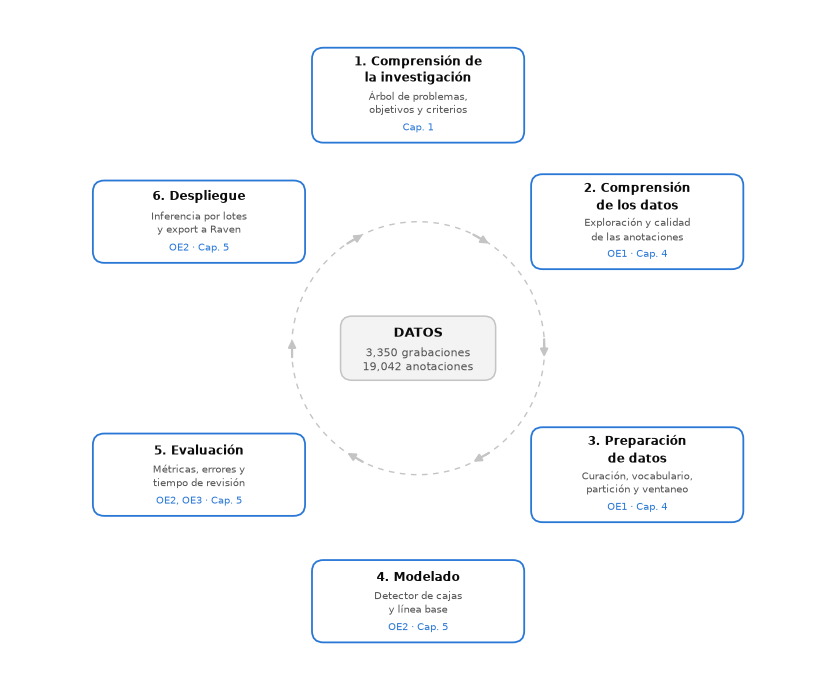

In [10]:
PHASES = [
    ("1. Comprensión de\nla investigación", "Árbol de problemas,\nobjetivos y criterios", "Cap. 1"),
    ("2. Comprensión\nde los datos", "Exploración y calidad\nde las anotaciones", "OE1 · Cap. 4"),
    ("3. Preparación\nde datos", "Curación, vocabulario,\npartición y ventaneo", "OE1 · Cap. 4"),
    ("4. Modelado", "Detector de cajas\ny línea base", "OE2 · Cap. 5"),
    ("5. Evaluación", "Métricas, errores y\ntiempo de revisión", "OE2, OE3 · Cap. 5"),
    ("6. Despliegue", "Inferencia por lotes\ny export a Raven", "OE2 · Cap. 5"),
]

fig, ax = canvas(10.6, 8.8)
TOP = 100 * 8.8 / 10.6
cx0, cy0, radius = 50, TOP / 2, 31.0

angles = np.linspace(90, -270, len(PHASES), endpoint=False)
positions = [
    (cx0 + radius * np.cos(np.radians(a)), cy0 + radius * np.sin(np.radians(a))) for a in angles
]

ring = 15.5
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(
    cx0 + ring * np.cos(theta),
    cy0 + ring * np.sin(theta),
    color=BASELINE,
    linewidth=1.0,
    linestyle=(0, (4, 4)),
)
for a in angles + 30:
    a0, a1 = np.radians(a + 5), np.radians(a - 5)
    arrow(
        ax,
        (cx0 + ring * np.cos(a0), cy0 + ring * np.sin(a0)),
        (cx0 + ring * np.cos(a1), cy0 + ring * np.sin(a1)),
        color=BASELINE,
        lw=1.6,
    )

for (x, y), (name, content, tag) in zip(positions, PHASES):
    node(
        ax,
        x,
        y,
        26,
        None,
        name,
        content,
        tag,
        wrap=24,
        fill=SURFACE,
        edge=BLUE,
        lw=1.3,
        fs=8.8,
        body_fs=7.4,
        foot_fs=7.2,
        foot_ink=BLUE,
    )

node(
    ax,
    cx0,
    cy0,
    19,
    None,
    "DATOS",
    f"{len(recordings):,} grabaciones\n{len(annotations):,} anotaciones",
    wrap=22,
    fill=PANEL,
    edge=BASELINE,
    fs=9,
    body_fs=7.6,
)

save(
    fig,
    "crisp_dm",
    where="Cap. 1, sección 1.6.1 - junto a la Tabla 1.6",
    width=r"0.9\textwidth",
    caption=(
        "Las seis fases de CRISP-DM aplicadas al proyecto, con el objetivo específico "
        "que atiende cada una y el capítulo que la documenta. El proceso es cíclico: la "
        "evaluación devuelve preguntas a la comprensión de los datos."
    ),
)
plt.show()

### 2.5 `recorded_vs_annotated`

Lee la cabecera de cada `.wav`; la primera corrida tarda ~1 min y cachea.

3,350 grabaciones · 33 h grabadas · 26 h con archivo de anotación (81%) · 8.6 h de evento anotado (26.35% del acervo)
guardada -> research/figures/recorded_vs_annotated.png  (139 kB)


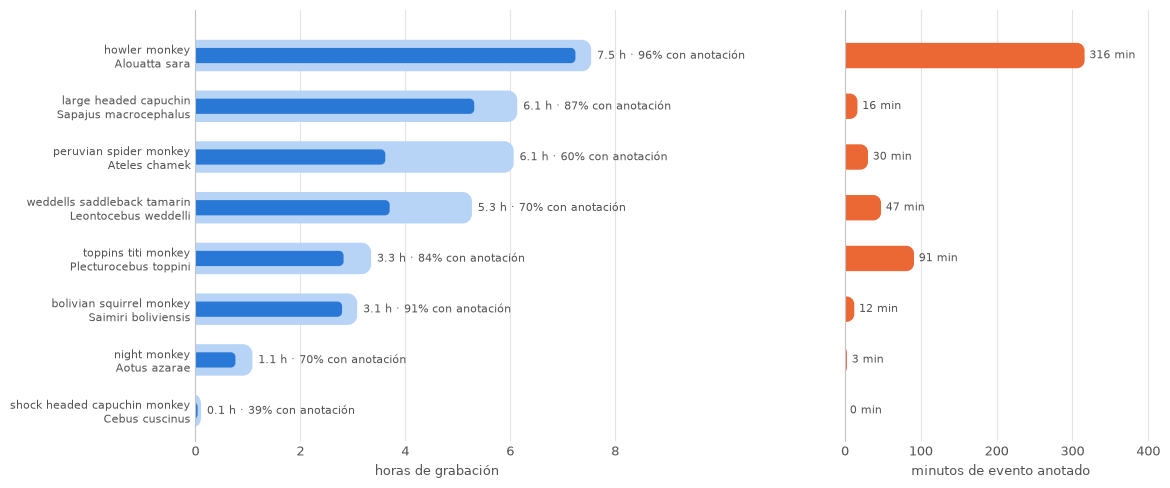

In [11]:
per_species = recordings.groupby("species").agg(
    recorded_h=("duration_s", lambda s: s.sum() / 3600),
    files=("audio_path", "count"),
)
per_species["reviewed_h"] = (
    (recordings[recordings.has_annotation].groupby("species").duration_s.sum() / 3600)
    .reindex(per_species.index)
    .fillna(0)
)
per_species["event_min"] = (
    (annotations.groupby("species").duration_s.sum() / 60).reindex(per_species.index).fillna(0)
)
per_species["share"] = per_species.reviewed_h / per_species.recorded_h
per_species = per_species.sort_values("recorded_h", ascending=False)

total_h = per_species.recorded_h.sum()
reviewed_h = per_species.reviewed_h.sum()
event_h = per_species.event_min.sum() / 60
print(
    f"{len(recordings):,} grabaciones · {total_h:,.0f} h grabadas · "
    f"{reviewed_h:,.0f} h con archivo de anotación ({reviewed_h / total_h:.0%}) · "
    f"{event_h:,.1f} h de evento anotado ({event_h / total_h:.2%} del acervo)"
)

order = per_species.index.tolist()
names = [f"{SPECIES_NAME[s]}\n{SPECIES_LATIN.get(s, '')}" for s in order]
ys = np.arange(len(order))

fig, axes = plt.subplots(
    1, 2, figsize=(12.4, 5.6), gridspec_kw={"width_ratios": [1.55, 1], "wspace": 0.42}
)

ax = axes[0]
peak = per_species.recorded_h.max()
ax.set_xlim(0, peak * 1.22)
ax.set_ylim(len(order) - 0.4, -0.9)
barh(ax, ys, per_species.recorded_h.values, BLUE_FADED, height=0.62)
barh(ax, ys, per_species.reviewed_h.values, BLUE, height=0.30)
for y, (_, r) in zip(ys, per_species.iterrows()):
    ax.text(
        r.recorded_h + peak * 0.015,
        y,
        f"{r.recorded_h:,.1f} h · {r.share:.0%} con anotación",
        va="center",
        ha="left",
        fontsize=7.6,
        color=INK_2,
    )
ax.set_yticks(ys, names, fontsize=8)
style_value_axis(ax, "x")
ax.set_xlabel("horas de grabación")

ax = axes[1]
peak = per_species.event_min.max()
ax.set_xlim(0, peak * 1.30)
ax.set_ylim(len(order) - 0.4, -0.9)
barh(ax, ys, per_species.event_min.values, SERIES[1], height=0.5)
for y, value in zip(ys, per_species.event_min.values):
    ax.text(
        value + peak * 0.02,
        y,
        f"{value:,.0f} min",
        va="center",
        ha="left",
        fontsize=7.6,
        color=INK_2,
    )
ax.set_yticks(ys, [""] * len(order))
style_value_axis(ax, "x")
ax.set_xlabel("minutos de evento anotado")

save(
    fig,
    "recorded_vs_annotated",
    where="Cap. 1, sección 1.1.1 (evidencia local) y Cap. 4, sección 4.1.3",
    caption=(
        "Composición del material recibido por especie: horas de audio entregadas, "
        "horas que llegaron acompañadas de un archivo de anotación de Raven y minutos "
        "de evento efectivamente delimitado. Sobre "
        f"{total_h:,.0f} horas de grabación hay {event_h:,.1f} horas de evento anotado, "
        f"el {event_h / total_h:.1%} del material."
    ),
)
plt.show()

## 3. Capítulo 2 — Marco referencial

### 3.1 `signal_chain`

guardada -> research/figures/signal_chain.png  (98 kB)


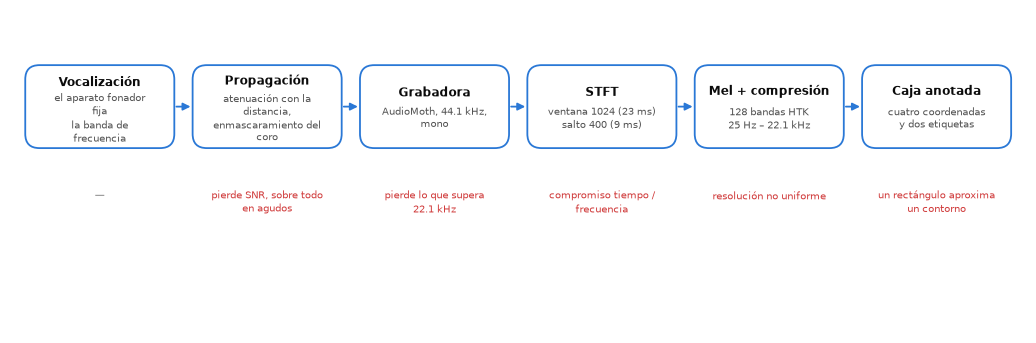

In [12]:
CHAIN = [
    ("Vocalización", "el aparato fonador fija\nla banda de frecuencia", "—"),
    (
        "Propagación",
        "atenuación con la distancia,\nenmascaramiento del coro",
        "pierde SNR, sobre todo en agudos",
    ),
    (
        "Grabadora",
        f"AudioMoth, {P.target_sr / 1000:.1f} kHz,\nmono",
        f"pierde lo que supera {P.f_max / 1000:.1f} kHz",
    ),
    (
        "STFT",
        f"ventana {P.win_length} ({P.win_length / P.target_sr * 1000:.0f} ms)\nsalto {P.hop_length} ({P.hop_length / P.target_sr * 1000:.0f} ms)",
        "compromiso tiempo / frecuencia",
    ),
    (
        "Mel + compresión",
        f"{P.n_mels} bandas HTK\n{P.f_min:.0f} Hz – {P.f_max / 1000:.1f} kHz",
        "resolución no uniforme",
    ),
    ("Caja anotada", "cuatro coordenadas\ny dos etiquetas", "un rectángulo aproxima un contorno"),
]

fig, ax = canvas(13.2, 4.2)
TOP = 100 * 4.2 / 13.2
boxes = flow_row(
    ax,
    [{"title": name, "body": body} for name, body, _ in CHAIN],
    TOP * 0.70,
    margin=1.5,
    gap=1.8,
    wrap=21,
    fill=SURFACE,
    edge=BLUE,
    lw=1.3,
    fs=8.8,
    body_fs=7.2,
)
for (cx, cy, w, h), (_, _, loss) in zip(boxes, CHAIN):
    caption_at(
        ax,
        cx,
        cy - h / 2 - 4.0,
        loss,
        fs=7.0,
        color=CRITICAL if loss != "—" else MUTED,
        wrap=24,
        va="top",
    )
save(
    fig,
    "signal_chain",
    where="Cap. 2, apertura del Marco Conceptual (sección 2.2)",
    caption=(
        "Recorrido de la señal desde la vocalización hasta la etiqueta revisable, con la "
        "pérdida que introduce cada eslabón. Los valores son los parámetros efectivos "
        "de preprocesamiento del proyecto."
    ),
)
plt.show()

### 3.2 `stft_tradeoff`

guardada -> research/figures/stft_tradeoff.png  (266 kB)


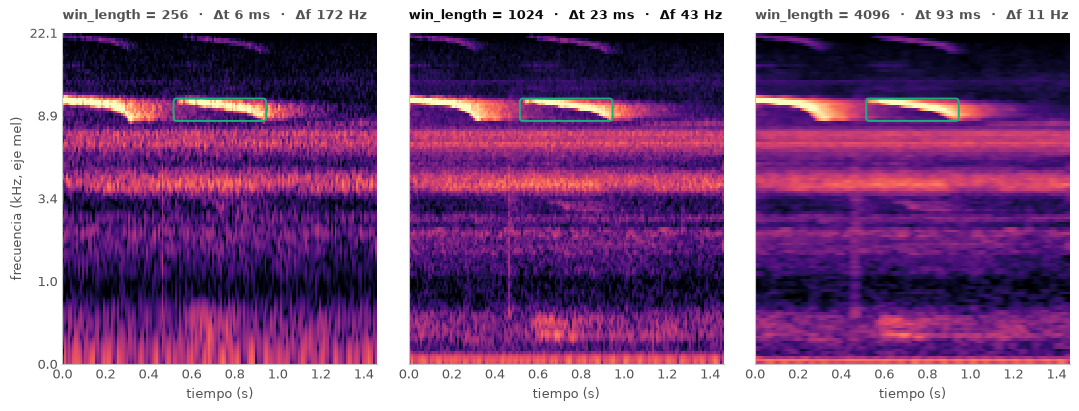

In [13]:
row = pick_annotation("lw/cs")
start_s, duration_s = segment_around(row, pad_ratio=1.2, min_pad_s=0.35)
waveform = load_segment(row.audio_path, start_s, duration_s)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.3), sharey=True, gridspec_kw={"wspace": 0.10})
for ax, win in zip(axes, (256, P.win_length, 4096)):
    transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=P.target_sr,
        n_fft=P.n_fft,
        win_length=win,
        hop_length=P.hop_length,
        n_mels=P.n_mels,
        f_min=P.f_min,
        f_max=P.f_max,
        power=2.0,
        mel_scale=P.mel_scale,
    )
    image = np.log(transform(waveform).numpy() + P.eps)
    draw_spectrogram(ax, image, duration_s)
    draw_box(
        ax,
        row.begin_time_s - start_s,
        row.end_time_s - start_s,
        row.low_freq_hz,
        row.high_freq_hz,
        color=GOOD,
        lw=1.4,
    )
    chosen = win == P.win_length
    ax.set_title(
        f"win_length = {win}  ·  Δt {win / P.target_sr * 1000:.0f} ms"
        f"  ·  Δf {P.target_sr / win:.0f} Hz",
        fontsize=9.5,
        color=INK if chosen else INK_2,
        pad=10,
    )
    if ax is not axes[0]:
        ax.set_ylabel("")

save(
    fig,
    "stft_tradeoff",
    where="Cap. 2, sección 2.1.2 - o junto a la tabla de preprocesamiento del Cap. 4",
    caption=(
        "Efecto de la ventana de análisis sobre el mismo evento. Una ventana corta "
        "resuelve el tiempo y difumina la frecuencia; una larga hace lo contrario. El "
        "proyecto usa 1024 muestras (23\\,ms), por debajo de la duración del evento más "
        "corto del corpus."
    ),
)
plt.show()

### 3.3 `mel_axis`

guardada -> research/figures/mel_axis.png  (140 kB)


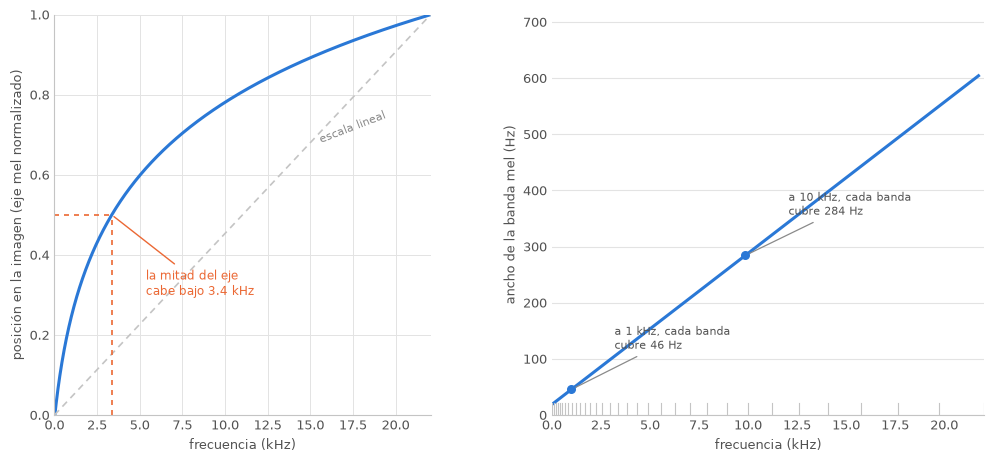

In [14]:
hz = np.linspace(0, P.f_max, 2000)
y = hz_to_y(hz, P)

fig, axes = plt.subplots(
    1, 2, figsize=(12.0, 5.2), gridspec_kw={"width_ratios": [1, 1.15], "wspace": 0.30}
)

ax = axes[0]
ax.plot(hz / 1000, y, color=BLUE, linewidth=2.2)
ax.plot([0, P.f_max / 1000], [0, 1], color=BASELINE, linewidth=1.2, linestyle=(0, (4, 3)))
ax.set_xlim(0, P.f_max / 1000)
ax.set_ylim(0, 1)
half = float(y_to_hz(np.array([0.5]), P)[0])
ax.plot([0, half / 1000], [0.5, 0.5], color=SERIES[1], linewidth=1.2, linestyle=(0, (3, 3)))
ax.plot([half / 1000, half / 1000], [0, 0.5], color=SERIES[1], linewidth=1.2, linestyle=(0, (3, 3)))
ax.annotate(
    f"la mitad del eje\ncabe bajo {half / 1000:.1f} kHz",
    xy=(half / 1000, 0.5),
    xytext=(half / 1000 + 2.0, 0.30),
    color=SERIES[1],
    fontsize=8.5,
    arrowprops=dict(arrowstyle="-", color=SERIES[1], linewidth=1),
)
ax.text(P.f_max / 1000 * 0.70, 0.68, "escala lineal", color=MUTED, fontsize=8, rotation=21)
ax.set_xlabel("frecuencia (kHz)")
ax.set_ylabel("posición en la imagen (eje mel normalizado)")
ax.grid(True, color=GRID, linewidth=0.7)
ax.set_axisbelow(True)

# --- derecha: qué le cuesta a la resolución --------------------------------
ax = axes[1]
edges = y_to_hz(np.linspace(0, 1, P.n_mels + 1), P)
centres = (edges[:-1] + edges[1:]) / 2
widths = np.diff(edges)
ax.plot(centres / 1000, widths, color=BLUE, linewidth=2.2)
ax.set_xlim(0, P.f_max / 1000)
ax.set_ylim(0, widths.max() * 1.18)
for target in (1000.0, 10000.0):
    index = int(np.argmin(np.abs(centres - target)))
    ax.scatter([centres[index] / 1000], [widths[index]], s=30, color=BLUE, zorder=5)
    ax.annotate(
        f"a {centres[index] / 1000:.0f} kHz, cada banda\ncubre {widths[index]:.0f} Hz",
        xy=(centres[index] / 1000, widths[index]),
        xytext=(centres[index] / 1000 + 2.2, widths[index] + widths.max() * 0.12),
        fontsize=8,
        color=INK_2,
        arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.9),
    )
for edge in edges[::4]:
    ax.plot([edge / 1000] * 2, [0, widths.max() * 0.035], color=BASELINE, linewidth=0.8)
ax.set_xlabel("frecuencia (kHz)")
ax.set_ylabel("ancho de la banda mel (Hz)")
style_value_axis(ax, "y")

save(
    fig,
    "mel_axis",
    where="Cap. 2, sección 2.2.3 (De la señal a la representación)",
    caption=(
        "La escala mel y su precio. El mapa \\texttt{hz\\_to\\_y} concentra la mitad del "
        "alto de la imagen por debajo de unos pocos kilohercios, donde caen las especies "
        "graves; a cambio, cada banda cubre cada vez más hercios conforme sube la "
        "frecuencia, y con ella crece el error de la coordenada vertical de la caja."
    ),
)
plt.show()

### 3.4 `pcen_vs_logmel`

PCEN con sus parámetros de inicialización, sin entrenar.

guardada -> research/figures/pcen_vs_logmel.png  (351 kB)


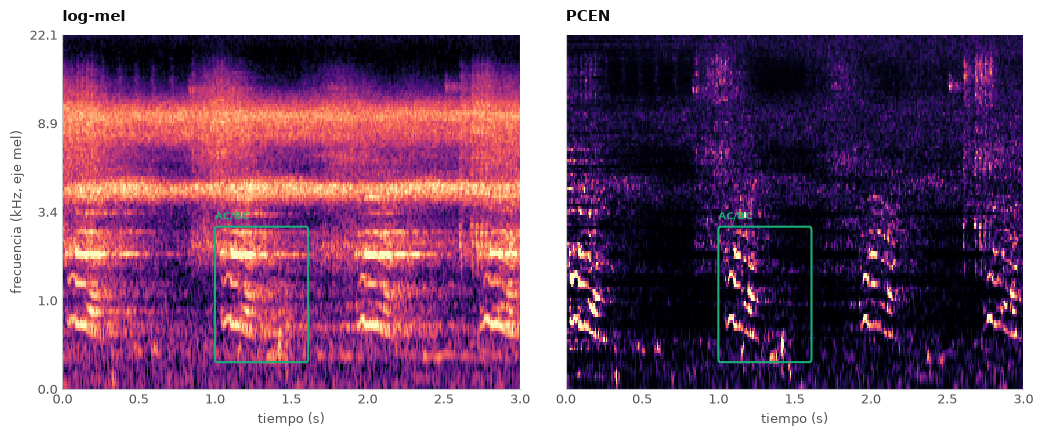

In [15]:
from architectures.trainable_pcen import TrainablePCEN  # noqa: E402

sample = experiment.sample(min(24, len(experiment)), random_state=7)
noisiest, best_floor = None, -np.inf
for r in sample.itertuples():
    try:
        clip = load_segment(r.audio_path, max(r.begin_time_s - 1.0, 0.0), P.clip_len_s)
    except Exception:
        continue
    power = MEL(clip)
    floor = float(np.percentile(np.log(power.numpy() + P.eps), 25))
    if floor > best_floor:
        noisiest, best_floor = r, floor

clip = load_segment(noisiest.audio_path, max(noisiest.begin_time_s - 1.0, 0.0), P.clip_len_s)
clip_start = max(noisiest.begin_time_s - 1.0, 0.0)
power = MEL(clip).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
    pcen = TrainablePCEN(n_mels=P.n_mels)(power)[0, 0].numpy()
log_image = np.log(power[0, 0].numpy() + P.eps)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6), sharey=True, gridspec_kw={"wspace": 0.10})
for ax, image, name in ((axes[0], log_image, "log-mel"), (axes[1], pcen, "PCEN")):
    draw_spectrogram(ax, image, P.clip_len_s)
    draw_box(
        ax,
        max(noisiest.begin_time_s - clip_start, 0),
        min(noisiest.end_time_s - clip_start, P.clip_len_s),
        noisiest.low_freq_hz,
        noisiest.high_freq_hz,
        color=GOOD,
        label=noisiest.pair.upper(),
        lw=1.5,
    )
    ax.set_title(name, fontsize=10.5, pad=10)
axes[1].set_ylabel("")

save(
    fig,
    "pcen_vs_logmel",
    where="Cap. 2, sección 2.2.3 - donde se declara el criterio de comparación",
    caption=(
        "Compresión logarítmica frente a normalización de energía por canal sobre el "
        "mismo clip. La comparación se resuelve en el Capítulo~5 bajo el criterio "
        "declarado: el \\textit{recall} de eventos de baja relación señal-ruido al punto "
        "de operación."
    ),
)
plt.show()

### 3.5 Exigencias por familia de arquitectura

Es una matriz de celdas: va como tabla de LaTeX, no como figura.

In [16]:
FAMILIES = ["CNN", "CRNN", "ResNet", "Transformer (AST)", "Detector de objetos"]
DEMANDS = [
    ("Reconocer un patrón espectro-temporal local", [2, 2, 2, 1, 2]),
    ("Sostener el contexto a lo largo de una frase", [0, 2, 1, 2, 1]),
    ("Ganar profundidad sin degradación", [0, 0, 2, 2, 2]),
    ("Dependencias a larga distancia sin recurrencia", [0, 0, 0, 2, 2]),
    ("Preservar la posición en frecuencia", [0, 0, 0, 1, 1]),
    ("Emitir $f_{min}$ y $f_{max}$ (forma de la salida)", [0, 0, 0, 0, 2]),
]
MARK = {2: r"$\bullet$", 1: r"$\circ$", 0: "--"}


def tabular(header, rows, align, caption, label, note=None):
    """Bloque `table` con booktabs, listo para pegar en `main.tex`."""
    body = [
        r"\begin{table}[htbp]",
        r"    \centering",
        "    \\caption{" + caption + "}",
        f"    \\label{{{label}}}",
        f"    \\begin{{tabular}}{{{align}}}",
        r"    \toprule",
        "    " + " & ".join(header) + r" \\",
        r"    \midrule",
    ]
    body += ["    " + " & ".join(row) + r" \\" for row in rows]
    body += [r"    \bottomrule", r"    \end{tabular}"]
    if note:
        body.append(r"    \par\smallskip\footnotesize " + note)
    body.append(r"\end{table}")
    return "\n".join(body)


print(
    tabular(
        ["Exigencia"] + FAMILIES,
        [[demand] + [MARK[s] for s in states] for demand, states in DEMANDS],
        "p{5.4cm}ccccc",
        "Exigencias del problema frente a familias de arquitecturas. "
        "$\\bullet$ la resuelve, $\\circ$ parcialmente, -- no la resuelve. "
        "La última fila es el criterio de descarte: sólo una cabeza de detección "
        "emite la banda de frecuencia.",
        "tab:familias",
    )
)

\begin{table}[htbp]
    \centering
    \caption{Exigencias del problema frente a familias de arquitecturas. $\bullet$ la resuelve, $\circ$ parcialmente, -- no la resuelve. La última fila es el criterio de descarte: sólo una cabeza de detección emite la banda de frecuencia.}
    \label{tab:familias}
    \begin{tabular}{p{5.4cm}ccccc}
    \toprule
    Exigencia & CNN & CRNN & ResNet & Transformer (AST) & Detector de objetos \\
    \midrule
    Reconocer un patrón espectro-temporal local & $\bullet$ & $\bullet$ & $\bullet$ & $\circ$ & $\bullet$ \\
    Sostener el contexto a lo largo de una frase & -- & $\bullet$ & $\circ$ & $\bullet$ & $\circ$ \\
    Ganar profundidad sin degradación & -- & -- & $\bullet$ & $\bullet$ & $\bullet$ \\
    Dependencias a larga distancia sin recurrencia & -- & -- & -- & $\bullet$ & $\bullet$ \\
    Preservar la posición en frecuencia & -- & -- & -- & $\circ$ & $\circ$ \\
    Emitir $f_{min}$ y $f_{max}$ (forma de la salida) & -- & -- & -- & -- & $\bullet$ \\
 

### 3.6 `box_coordinates`

guardada -> research/figures/box_coordinates.png  (214 kB)


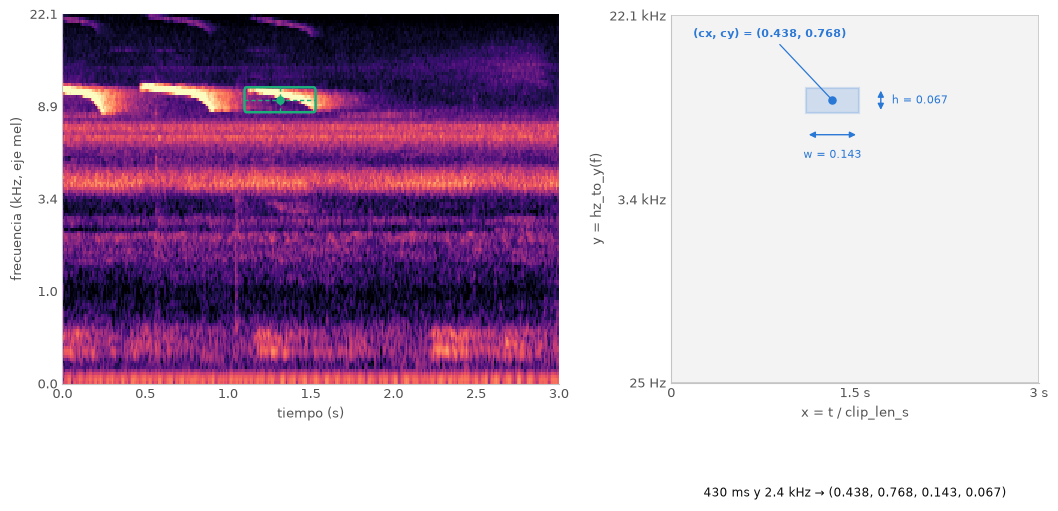

In [17]:
from domain.dataset import _boxes_in_window  # noqa: E402

row = pick_annotation("lw/cs")
clip_start = max(row.begin_time_s - 1.1, 0.0)
group = annotations.loc[[row.name]]
boxes, _ = _boxes_in_window(group, np.zeros(1), clip_start, P)
cx, cy, w, h = boxes[0, :4]
waveform = load_segment(row.audio_path, clip_start, P.clip_len_s)

fig = plt.figure(figsize=(12.6, 4.8))
grid = fig.add_gridspec(1, 2, width_ratios=[1.35, 1], wspace=0.26)

ax = fig.add_subplot(grid[0])
draw_spectrogram(ax, log_mel(waveform), P.clip_len_s)
t0, t1 = row.begin_time_s - clip_start, row.end_time_s - clip_start
y0, y1 = draw_box(ax, t0, t1, row.low_freq_hz, row.high_freq_hz, color=GOOD, lw=1.8)
ax.plot([t0, t1], [(y0 + y1) / 2] * 2, color=GOOD, linewidth=1, linestyle=(0, (3, 2)))
ax.plot([(t0 + t1) / 2] * 2, [y0, y1], color=GOOD, linewidth=1, linestyle=(0, (3, 2)))
ax.scatter([(t0 + t1) / 2], [(y0 + y1) / 2], s=26, color=GOOD, zorder=6)

ax = fig.add_subplot(grid[1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=PANEL, edgecolor=BASELINE, linewidth=1.1))
ax.add_patch(
    Rectangle(
        (cx - w / 2, cy - h / 2), w, h, facecolor=BLUE, alpha=0.18, edgecolor=BLUE, linewidth=1.6
    )
)
ax.scatter([cx], [cy], s=26, color=BLUE, zorder=5)
ax.annotate(
    "",
    xy=(cx - w / 2, cy - h / 2 - 0.06),
    xytext=(cx + w / 2, cy - h / 2 - 0.06),
    arrowprops=dict(arrowstyle="<|-|>", color=BLUE, linewidth=1, mutation_scale=9),
)
ax.text(cx, cy - h / 2 - 0.10, f"w = {w:.3f}", ha="center", va="top", fontsize=8, color=BLUE)
ax.annotate(
    "",
    xy=(cx + w / 2 + 0.06, cy - h / 2),
    xytext=(cx + w / 2 + 0.06, cy + h / 2),
    arrowprops=dict(arrowstyle="<|-|>", color=BLUE, linewidth=1, mutation_scale=9),
)
ax.text(cx + w / 2 + 0.09, cy, f"h = {h:.3f}", ha="left", va="center", fontsize=8, color=BLUE)
ax.annotate(
    f"(cx, cy) = ({cx:.3f}, {cy:.3f})",
    xy=(cx, cy),
    xytext=(0.06, min(cy + 0.22, 0.94)),
    fontsize=8,
    color=BLUE,
    fontweight="bold",
    arrowprops=dict(arrowstyle="-", color=BLUE, linewidth=0.9),
)
ax.grid(True, color=GRID, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_xticks([0, 0.5, 1], ["0", "1.5 s", f"{P.clip_len_s:g} s"])
ax.set_yticks(
    [0, 0.5, 1],
    ["25 Hz", f"{y_to_hz(np.array([0.5]), P)[0] / 1000:.1f} kHz", f"{P.f_max / 1000:.1f} kHz"],
)
ax.set_xlabel("x = t / clip_len_s")
ax.set_ylabel("y = hz_to_y(f)")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
caption_at(
    ax,
    0.5,
    -0.30,
    f"{row.duration_s * 1000:.0f} ms y {row.bandwidth_hz / 1000:.1f} kHz "
    f"→ ({cx:.3f}, {cy:.3f}, {w:.3f}, {h:.3f})",
    fs=8.5,
    color=INK,
)

save(
    fig,
    "box_coordinates",
    where="Cap. 4, sección 4.3.4 (Representación y normalización de las cajas)",
    caption=(
        "De la anotación al marco normalizado. El tiempo se divide entre la longitud del "
        "clip y la frecuencia pasa por la escala mel de \\texttt{hz\\_to\\_y}, de modo que "
        "una caja significa lo mismo en píxeles que en pantalla y eventos de escalas muy "
        "distintas son comparables por IoU."
    ),
)
plt.show()

### 3.7 `iou_criterion`

guardada -> research/figures/iou_criterion.png  (41 kB)


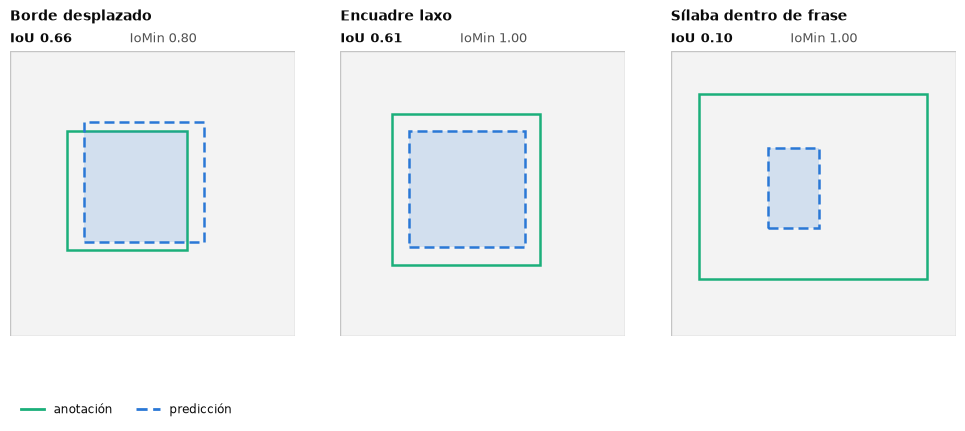

In [18]:
from architectures.iou import box_iou_pairwise, min_area_box_iou  # noqa: E402

CASES = [
    (
        "Borde desplazado",
        (0.20, 0.30, 0.62, 0.72),
        (0.26, 0.33, 0.68, 0.75),
        "el anotador y el modelo no cierran el evento en el mismo sitio",
    ),
    (
        "Encuadre laxo",
        (0.18, 0.25, 0.70, 0.78),
        (0.24, 0.31, 0.65, 0.72),
        "misma detección, caja más floja: castiga IoU 0,75 y no IoU 0,25",
    ),
    (
        "Sílaba dentro de frase",
        (0.10, 0.20, 0.90, 0.85),
        (0.34, 0.38, 0.52, 0.66),
        "IoU la separa; IoMin la delata como anidada",
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.6), gridspec_kw={"wspace": 0.16})
for ax, (name, a, b, _note) in zip(axes, CASES):
    box_a = torch.tensor([a], dtype=torch.float32)
    box_b = torch.tensor([b], dtype=torch.float32)
    iou = float(box_iou_pairwise(box_a, box_b)[0])
    iomin = float(min_area_box_iou(box_a, box_b)[0, 0])

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=PANEL, edgecolor=BASELINE, linewidth=1.0))
    ax.add_patch(
        Rectangle(
            (a[0], a[1]), a[2] - a[0], a[3] - a[1], facecolor="none", edgecolor=GOOD, linewidth=1.8
        )
    )
    ax.add_patch(
        Rectangle(
            (b[0], b[1]),
            b[2] - b[0],
            b[3] - b[1],
            facecolor="none",
            edgecolor=BLUE,
            linewidth=1.8,
            linestyle=(0, (4, 2)),
        )
    )
    lo = (max(a[0], b[0]), max(a[1], b[1]))
    hi = (min(a[2], b[2]), min(a[3], b[3]))
    ax.add_patch(
        Rectangle(lo, hi[0] - lo[0], hi[1] - lo[1], facecolor=BLUE, alpha=0.16, edgecolor="none")
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.set_title(name, fontsize=10, pad=22)
    ax.annotate(
        f"IoU {iou:.2f}",
        xy=(0, 1),
        xytext=(0, 4),
        xycoords="axes fraction",
        textcoords="offset points",
        fontsize=9.5,
        color=INK,
        fontweight="bold",
        va="bottom",
    )
    ax.annotate(
        f"IoMin {iomin:.2f}",
        xy=(0.42, 1),
        xytext=(0, 4),
        xycoords="axes fraction",
        textcoords="offset points",
        fontsize=9.5,
        color=INK_2,
        va="bottom",
    )

handles = [
    plt.Line2D([], [], color=GOOD, linewidth=2, label="anotación"),
    plt.Line2D([], [], color=BLUE, linewidth=2, linestyle=(0, (4, 2)), label="predicción"),
]
axes[0].legend(handles=handles, loc="lower left", bbox_to_anchor=(0, -0.32), ncol=2)
save(
    fig,
    "iou_criterion",
    where="Cap. 1 sección 1.6.1 (Tabla de métricas) o Cap. 5 (protocolo de evaluación)",
    caption=(
        "IoU e IoMin sobre los tres casos que decide el criterio de evaluación. Como la "
        "frontera del evento es borrosa incluso entre anotadores, el barrido de umbrales "
        "incluye valores bajos; IoMin, implementado en \\texttt{architectures/iou.py}, es "
        "el que reconoce el anidamiento."
    ),
)
plt.show()

## 4. Capítulo 3 — Estado del arte

### 4.1 `prisma_flow` (Figura 3.1)

Editá `PRISMA` con los conteos del gestor bibliográfico; lo que quede en `None` se
dibuja como hueco rojo.

claves citadas en el capítulo 3 de main.tex: 9
   bonet-sola_comparative_2021, he_deep_2016, kahl_birdnet_2021, kath_leveraging_2024, lostanlen_robust_2019, meedeniya_survey_2023, nolasco_learning_2023, politis_dataset_2020 ...
sugerencia: 'incluidos' >= ese número; confirma los conteos intermedios antes de entregar
guardada -> research/figures/prisma_flow.png  (95 kB)


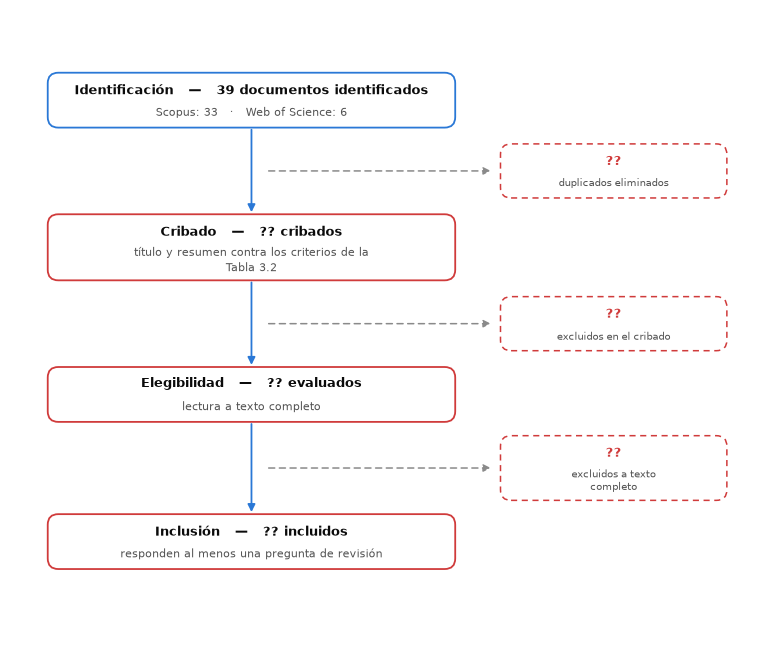

In [19]:
import re  # noqa: E402

PRISMA = {
    "scopus": 33,
    "wos": 6,
    "duplicates": None,  # duplicados eliminados
    "screened": None,  # cribados por título y resumen
    "screened_out": None,  # excluidos en el cribado
    "eligible": None,  # evaluados a texto completo
    "eligible_out": None,  # excluidos a texto completo
    "included": None,  # incluidos en la síntesis
}

main_tex = (PROJECT_DIR / "research" / "main.tex").read_text(encoding="utf-8")
chapter_3 = main_tex[
    main_tex.find(r"\chapter{Estado del Arte}") : main_tex.find(r"\chapter{Curación")
]
cited = sorted(
    {
        k.strip()
        for group in re.findall(r"\\cite[tp]?\{([^}]*)\}", chapter_3)
        for k in group.split(",")
    }
)
print(f"claves citadas en el capítulo 3 de main.tex: {len(cited)}")
print("  ", ", ".join(cited[:8]), "...")
print("sugerencia: 'incluidos' >= ese número; confirma los conteos intermedios antes de entregar")


def prisma_value(key):
    value = PRISMA.get(key)
    return (f"{value}", INK) if value is not None else ("??", CRITICAL)


fig, ax = canvas(9.8, 8.2)
TOP = 100 * 8.2 / 9.8
identified = PRISMA["scopus"] + PRISMA["wos"]
STAGES = [
    (
        "Identificación",
        f"Scopus: {PRISMA['scopus']}   ·   Web of Science: {PRISMA['wos']}",
        f"{identified} documentos identificados",
        None,
    ),
    (
        "Cribado",
        "título y resumen contra los criterios de la Tabla 3.2",
        prisma_value("screened")[0] + " cribados",
        ("duplicates", "duplicados eliminados"),
    ),
    (
        "Elegibilidad",
        "lectura a texto completo",
        prisma_value("eligible")[0] + " evaluados",
        ("screened_out", "excluidos en el cribado"),
    ),
    (
        "Inclusión",
        "responden al menos una pregunta de revisión",
        prisma_value("included")[0] + " incluidos",
        ("eligible_out", "excluidos a texto completo"),
    ),
]

pitch = 19.5
previous = None
for i, (stage, detail, count, excluded) in enumerate(STAGES):
    cy = TOP - 12 - i * pitch
    missing = "??" in count
    box = node(
        ax,
        32,
        cy,
        54,
        None,
        f"{stage}   —   {count}",
        detail,
        wrap=48,
        fill=SURFACE,
        edge=CRITICAL if missing else BLUE,
        lw=1.3,
        fs=9.6,
        body_fs=7.8,
    )
    if previous:
        gap_top, gap_bottom = previous[1] - previous[3] / 2, cy + box[3] / 2
        arrow(ax, (32, gap_top), (32, gap_bottom), color=BLUE, lw=1.3)
        if excluded:
            key, note = excluded
            value, color = prisma_value(key)
            mid = (gap_top + gap_bottom) / 2
            ex = node(
                ax,
                80,
                mid,
                30,
                None,
                value,
                note,
                wrap=24,
                fill=SURFACE,
                edge=color,
                dashed=True,
                lw=1.1,
                fs=9.6,
                body_fs=7.4,
                ink=color,
            )
            arrow(ax, (34, mid), (ex[0] - ex[2] / 2 - 1, mid), color=MUTED, lw=1.1, dashed=True)
    previous = box

save(
    fig,
    "prisma_flow",
    where="Cap. 3, sección 3.1.3 (Figura 3.1) - tras la tabla de criterios",
    width=r"0.8\textwidth",
    caption=(
        "Flujo de la revisión de literatura. De los 39 documentos identificados en "
        "Scopus y Web of Science, los criterios de inclusión y exclusión de la "
        "Tabla~\\ref{tab:criterios} dejan el conjunto que sostiene las cinco preguntas "
        "de revisión."
    ),
)
plt.show()

### 4.2 Mapa del estado del arte

Dominio contra dimensionalidad de la salida: es una tabla, va como `tabular`.

In [20]:
COLUMNS = ["Probabilidad por segmento", "Evento onset--offset", "Caja tiempo--frecuencia"]
ROWS = ["Genérico / DCASE", "Aves", "Mamíferos", "Primates"]
CELLS = {
    (0, 0): ["Bonet-Solà (2021)"],
    (0, 1): ["Ebbers (SEBB)", "Venkatesh (YOHO)", "He (SoundDet)", "Schmid (2026)", "Nolasco"],
    (0, 2): ["Zhu (2025)", "González (YOLO)", "Jin (segmentación)"],
    (1, 0): ["Kahl (BirdNET)"],
    (1, 2): ["Airalé (NBM)"],
    (2, 0): ["Campos (HOWLish)"],
    (2, 2): ["Escobar-Amado (2024)"],
    (3, 0): ["Heinicke (2015)"],
    (3, 2): [r"\textbf{Esta tesis}"],
}

print(
    tabular(
        ["Dominio"] + COLUMNS,
        [
            [name] + ["; ".join(CELLS.get((i, j), ["--"])) for j in range(len(COLUMNS))]
            for i, name in enumerate(ROWS)
        ],
        "p{2.6cm}p{3.1cm}p{3.9cm}p{3.4cm}",
        "Trabajos revisados por dominio y por dimensionalidad de la salida. La celda "
        "que cruza primates con caja tiempo--frecuencia está vacía en la literatura "
        "recuperada, y es donde se sitúa esta tesis.",
        "tab:sota-map",
    )
)

\begin{table}[htbp]
    \centering
    \caption{Trabajos revisados por dominio y por dimensionalidad de la salida. La celda que cruza primates con caja tiempo--frecuencia está vacía en la literatura recuperada, y es donde se sitúa esta tesis.}
    \label{tab:sota-map}
    \begin{tabular}{p{2.6cm}p{3.1cm}p{3.9cm}p{3.4cm}}
    \toprule
    Dominio & Probabilidad por segmento & Evento onset--offset & Caja tiempo--frecuencia \\
    \midrule
    Genérico / DCASE & Bonet-Solà (2021) & Ebbers (SEBB); Venkatesh (YOHO); He (SoundDet); Schmid (2026); Nolasco & Zhu (2025); González (YOLO); Jin (segmentación) \\
    Aves & Kahl (BirdNET) & -- & Airalé (NBM) \\
    Mamíferos & Campos (HOWLish) & -- & Escobar-Amado (2024) \\
    Primates & Heinicke (2015) & -- & \textbf{Esta tesis} \\
    \bottomrule
    \end{tabular}
\end{table}


## 5. Capítulo 4 — Curación del conjunto

### 5.1 El manifiesto, con los parámetros de `create_dataset.py`

In [21]:
BUILD_MANIFEST = True

manifest = splits = None
if BUILD_MANIFEST:
    from domain.dataset import build_manifest, split_manifest  # noqa: E402
    from domain.species import LabelSet  # noqa: E402

    labels = LabelSet(CLASSES)
    manifest = build_manifest(experiment, labels, empty_ratio=0.25, seed=42)
    splits = dict(
        zip(
            ("train", "val", "test"),
            split_manifest(manifest, seed=42, n_classes=len(labels), ratios=(0.6, 0.225, 0.175)),
        )
    )
    n_boxes = sum(len(w.boxes) for w in manifest)
    print(
        f"{len(manifest):,} ventanas · {n_boxes:,} cajas · "
        + " · ".join(f"{name} {len(split):,}" for name, split in splits.items())
    )

39,419 ventanas · 45,097 cajas · train 21,966 · val 9,446 · test 8,007


### 5.2 `curation_pipeline`

guardada -> research/figures/curation_pipeline.png  (160 kB)


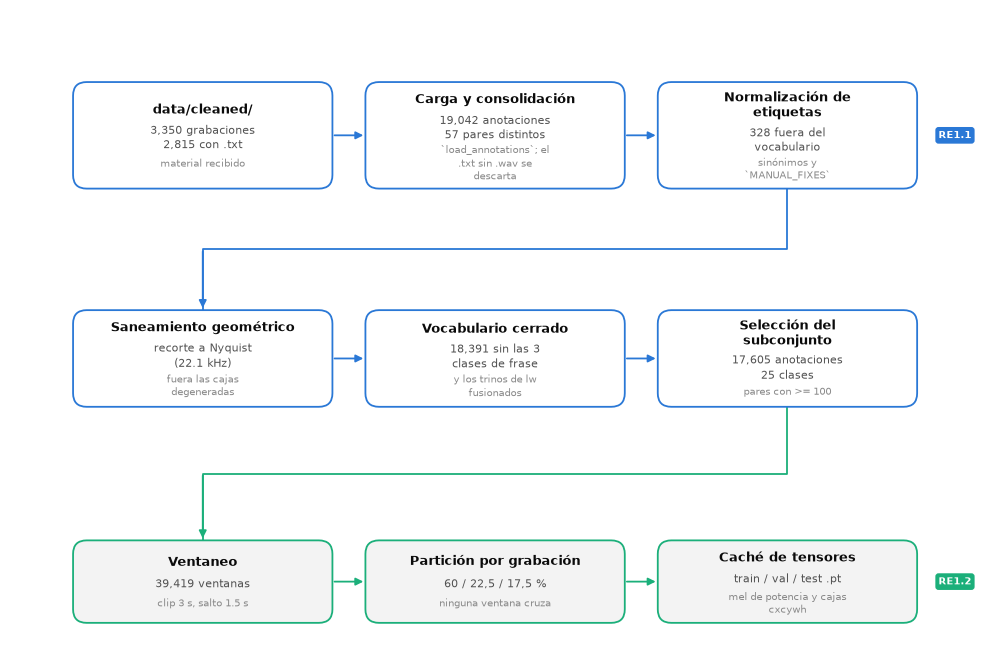

In [22]:
n_loaded = len(annotations)
n_pairs = annotations.pair.nunique()
excluded_mask = annotations[["species", "call_type"]].apply(tuple, axis=1).isin(EXCLUDED_PAIRS)
n_no_phrase = int((~excluded_mask).sum())
n_experiment = len(experiment)
n_review = int(annotations.requires_review.sum())

STEPS = [
    (
        "data/cleaned/",
        f"{len(recordings):,} grabaciones\n{recordings.has_annotation.sum():,} con .txt",
        "material recibido",
    ),
    (
        "Carga y consolidación",
        f"{n_loaded:,} anotaciones\n{n_pairs} pares distintos",
        "`load_annotations`; el .txt sin .wav se descarta",
    ),
    (
        "Normalización de etiquetas",
        f"{n_review:,} fuera del\nvocabulario",
        "sinónimos y `MANUAL_FIXES`",
    ),
    (
        "Saneamiento geométrico",
        f"recorte a Nyquist\n({P.f_max / 1000:.1f} kHz)",
        "fuera las cajas degeneradas",
    ),
    (
        "Vocabulario cerrado",
        f"{n_no_phrase:,} sin las 3\nclases de frase",
        "y los trinos de lw fusionados",
    ),
    (
        "Selección del subconjunto",
        f"{n_experiment:,} anotaciones\n{len(CLASSES)} clases",
        f"pares con >= {MIN_PAIR_COUNT}",
    ),
]
WINDOW_STEPS = [
    (
        "Ventaneo",
        f"{len(manifest):,} ventanas" if manifest else "ventanas de 3 s",
        f"clip {P.clip_len_s:g} s, salto {P.clip_hop_s:g} s",
    ),
    ("Partición por grabación", "60 / 22,5 / 17,5 %", "ninguna ventana cruza"),
    ("Caché de tensores", "train / val / test .pt", "mel de potencia y cajas cxcywh"),
]

fig, ax = canvas(12.6, 8.4)
TOP = 100 * 8.4 / 12.6
ROWS = [STEPS[:3], STEPS[3:], WINDOW_STEPS]
row_y = [TOP - 13, TOP - 36, TOP - 59]
placed = []
for r, (row, cy) in enumerate(zip(ROWS, row_y)):
    edge = SERIES[2] if r == 2 else BLUE
    placed.append(
        flow_row(
            ax,
            [{"title": name, "body": count, "foot": note} for name, count, note in row],
            cy,
            margin=6.5,
            gap=3.4,
            wrap=24,
            fill=PANEL if r == 2 else SURFACE,
            edge=edge,
            arrow_color=edge,
            lw=1.3,
            fs=9.0,
            body_fs=7.8,
            foot_fs=6.9,
        )
    )
for r in range(2):
    cx_last, cy_last, w_last, h_last = placed[r][-1]
    cx_first, cy_next, w_first, h_next = placed[r + 1][0]
    mid = (cy_last - h_last / 2 + cy_next + h_next / 2) / 2
    elbow(
        ax,
        [
            (cx_last, cy_last - h_last / 2),
            (cx_last, mid),
            (cx_first, mid),
            (cx_first, cy_next + h_next / 2),
        ],
        color=SERIES[2] if r == 1 else BLUE,
    )

chip(ax, 97.4, row_y[0], "RE1.1", BLUE, fs=7.5)
chip(ax, 97.4, row_y[2], "RE1.2", SERIES[2], fs=7.5)
save(
    fig,
    "curation_pipeline",
    where="Cap. 4, apertura de la sección 4.2 (Protocolo de curación)",
    caption=(
        "El protocolo de curación con el conteo que sobrevive a cada paso. Las dos "
        "primeras filas corresponden a RE1.1 (limpieza y estandarización) y la tercera a "
        "RE1.2 (particionado y ventaneo)."
    ),
)
plt.show()

### 5.3 `windowing`

guardada -> research/figures/windowing.png  (88 kB)


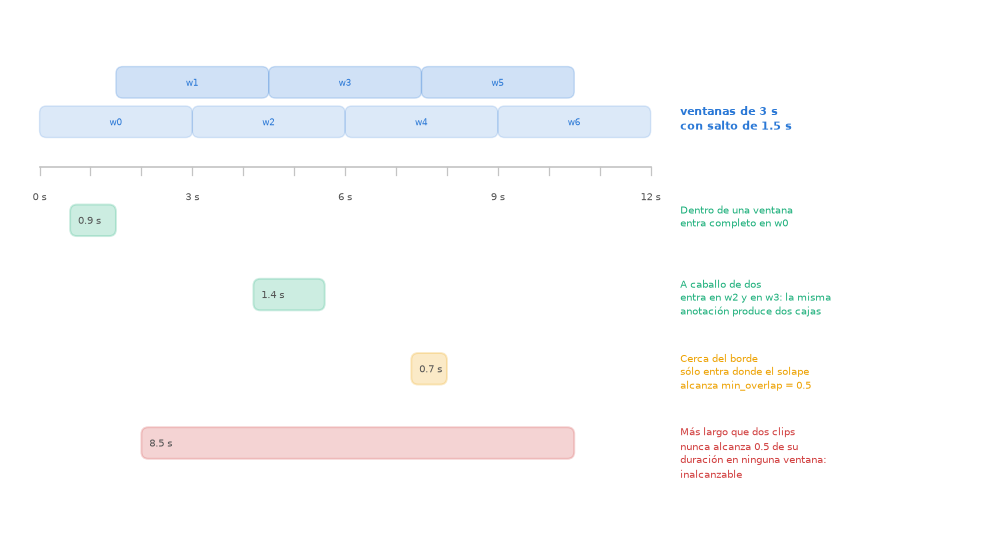

In [23]:
fig, ax = canvas(12.8, 6.8)
TOP = 100 * 6.8 / 12.8
SPAN_S = 12.0
X0, TIMELINE_W = 3.0, 62.0
SCALE = TIMELINE_W / SPAN_S
NOTE_X = X0 + TIMELINE_W + 3.0
AXIS_Y = TOP - 16


def t2x(t):
    return X0 + t * SCALE


starts = np.arange(0, SPAN_S - P.clip_len_s + 0.01, P.clip_hop_s)
for i, start in enumerate(starts):
    y = AXIS_Y + 3.0 + (i % 2) * 4.0
    ax.add_patch(
        FancyBboxPatch(
            (t2x(start), y),
            P.clip_len_s * SCALE,
            3.2,
            boxstyle="round,pad=0,rounding_size=0.7",
            facecolor=BLUE,
            alpha=0.16 + 0.06 * (i % 2),
            edgecolor=BLUE,
            linewidth=1.0,
        )
    )
    caption_at(ax, t2x(start + P.clip_len_s / 2), y + 1.6, f"w{i}", fs=6.8, color=BLUE)
caption_at(
    ax,
    NOTE_X,
    AXIS_Y + 5.0,
    f"ventanas de {P.clip_len_s:g} s\ncon salto de {P.clip_hop_s:g} s",
    fs=7.8,
    color=BLUE,
    ha="left",
    weight="bold",
)

ax.plot([X0, X0 + SPAN_S * SCALE], [AXIS_Y, AXIS_Y], color=BASELINE, linewidth=1.2)
for t in range(0, int(SPAN_S) + 1):
    ax.plot([t2x(t), t2x(t)], [AXIS_Y - 0.8, AXIS_Y], color=BASELINE, linewidth=0.9)
    if t % 3 == 0:
        caption_at(ax, t2x(t), AXIS_Y - 3.0, f"{t} s", fs=7.5)

EVENTS = [
    (0.6, 1.5, "Dentro de una ventana", GOOD, "entra completo en w0"),
    (
        4.2,
        5.6,
        "A caballo de dos",
        GOOD,
        "entra en w2 y en w3: la misma anotación produce dos cajas",
    ),
    (
        7.3,
        8.0,
        "Cerca del borde",
        WARNING,
        f"sólo entra donde el solape alcanza min_overlap = {P.min_overlap:g}",
    ),
    (
        2.0,
        10.5,
        "Más largo que dos clips",
        CRITICAL,
        f"nunca alcanza {P.min_overlap:g} de su duración en ninguna ventana: inalcanzable",
    ),
]
pitch = (AXIS_Y - 7.0) / len(EVENTS)
for i, (t0, t1, name, color, note) in enumerate(EVENTS):
    y = AXIS_Y - 7.0 - i * pitch
    ax.add_patch(
        FancyBboxPatch(
            (t2x(t0), y),
            (t1 - t0) * SCALE,
            3.2,
            boxstyle="round,pad=0,rounding_size=0.7",
            facecolor=color,
            alpha=0.22,
            edgecolor=color,
            linewidth=1.4,
        )
    )
    caption_at(ax, t2x(t0) + 0.8, y + 1.6, f"{t1 - t0:.1f} s", fs=7, color=INK_2, ha="left")
    caption_at(
        ax, NOTE_X, y + 3.4, f"{name}\n{note}", fs=7.4, color=color, ha="left", wrap=30, va="top"
    )

save(
    fig,
    "windowing",
    where="Cap. 4, sección 4.3.2 (El ventaneo y su defecto)",
    caption=(
        "Los cuatro destinos de una anotación bajo el ventaneo de "
        f"{P.clip_len_s:g}\\,s con salto de {P.clip_hop_s:g}\\,s. El cuarto caso es el "
        "defecto silencioso: los eventos que superan el doble de la longitud del clip no "
        "pueden asignarse a ninguna ventana y no llegan nunca al modelo."
    ),
)
plt.show()

### 5.4 `split_by_recording`

guardada -> research/figures/split_by_recording.png  (47 kB)


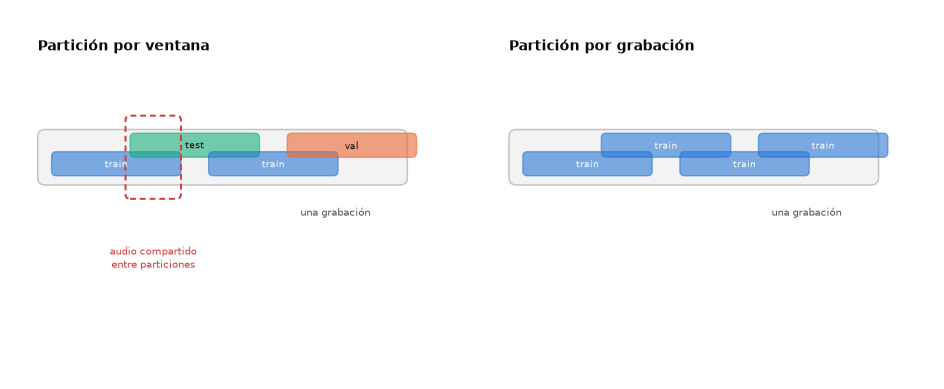

In [24]:
fig, ax = canvas(12.0, 4.8)
TOP = 100 * 4.8 / 12.0
BLOCK_Y = TOP - 19

for x0, title, ok in [(3, "Partición por ventana", False), (54, "Partición por grabación", True)]:
    caption_at(ax, x0, TOP - 4, title, fs=10, color=INK, ha="left", weight="bold")
    width = 40
    ax.add_patch(
        FancyBboxPatch(
            (x0, BLOCK_Y),
            width,
            6,
            boxstyle="round,pad=0,rounding_size=0.8",
            facecolor=PANEL,
            edgecolor=BASELINE,
            linewidth=1.1,
        )
    )
    caption_at(ax, x0 + width - 4, BLOCK_Y - 3.0, "una grabación", fs=7.5, ha="right")
    assignment = ["train"] * 4 if ok else ["train", "test", "train", "val"]
    tint = {"train": BLUE, "val": SERIES[1], "test": SERIES[2]}
    for i in range(4):
        start = x0 + 1.5 + i * 8.5
        ax.add_patch(
            FancyBboxPatch(
                (start, BLOCK_Y + 1 + (i % 2) * 2),
                14,
                2.6,
                boxstyle="round,pad=0,rounding_size=0.5",
                facecolor=tint[assignment[i]],
                alpha=0.6,
                edgecolor=tint[assignment[i]],
                linewidth=1.0,
            )
        )
        caption_at(
            ax,
            start + 7,
            BLOCK_Y + 2.3 + (i % 2) * 2,
            assignment[i],
            fs=6.4,
            color=SURFACE if assignment[i] == "train" else INK,
        )
    if not ok:
        ax.add_patch(
            FancyBboxPatch(
                (x0 + 9.5, BLOCK_Y - 1.5),
                6,
                9,
                boxstyle="round,pad=0,rounding_size=0.5",
                facecolor="none",
                edgecolor=CRITICAL,
                linewidth=1.4,
                linestyle=(0, (3, 2)),
            )
        )
        caption_at(
            ax,
            x0 + 12.5,
            BLOCK_Y - 6.5,
            "audio compartido\nentre particiones",
            fs=7,
            color=CRITICAL,
            va="top",
        )

save(
    fig,
    "split_by_recording",
    where="Cap. 4, sección 4.3.1 (Partición por archivo de grabación)",
    caption=(
        "Partición por ventana frente a partición por archivo. Con un salto igual a la "
        "mitad del clip, dos ventanas consecutivas comparten la mitad de su audio; "
        "asignarlas por separado filtraría material de entrenamiento a la partición de "
        "prueba."
    ),
)
plt.show()

### 5.5 `nesting_phrase` (Figura 1.4)

 frase sílaba  frases  frases con >=1 sílaba dentro  sílabas  sílabas dentro de una frase
 lw/cc  lw/cs     517                         0.996     2316                        0.988
 sm/fc  sm/fs     126                         0.968      691                        0.986
sb/pcs sb/ppc       8                         0.000     1151                        0.000
guardada -> research/figures/nesting_phrase.png  (308 kB)


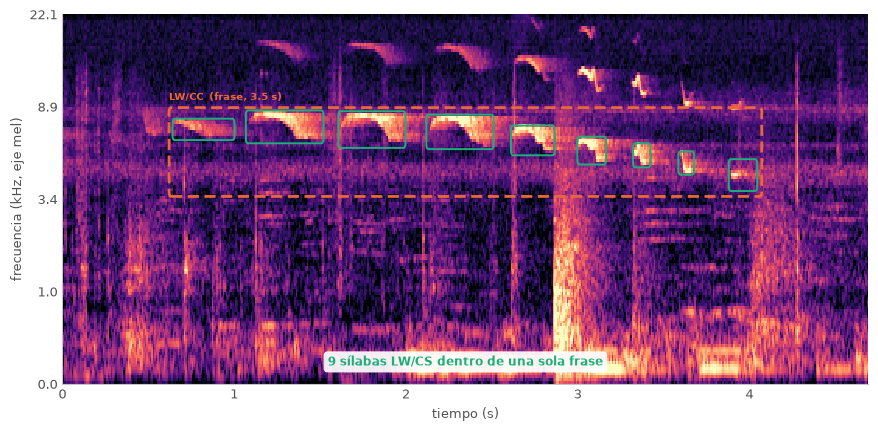

In [25]:
NESTED_PAIRS = [("lw/cc", "lw/cs"), ("sm/fc", "sm/fs"), ("sb/pcs", "sb/ppc")]

nesting_rows = []
for phrase_pair, syllable_pair in NESTED_PAIRS:
    phrases = annotations[annotations.pair == phrase_pair]
    syllables = annotations[annotations.pair == syllable_pair]
    if phrases.empty or syllables.empty:
        continue
    inside = 0
    for audio_path, group in syllables.groupby("audio_path"):
        window = phrases[phrases.audio_path == audio_path]
        if window.empty:
            continue
        mid = ((group.begin_time_s + group.end_time_s) / 2).to_numpy()[:, None]
        starts = window.begin_time_s.to_numpy()[None, :]
        ends = window.end_time_s.to_numpy()[None, :]
        inside += int(((mid >= starts) & (mid <= ends)).any(axis=1).sum())
    with_syllable = 0
    for audio_path, group in phrases.groupby("audio_path"):
        window = syllables[syllables.audio_path == audio_path]
        if window.empty:
            continue
        mid = ((window.begin_time_s + window.end_time_s) / 2).to_numpy()[None, :]
        starts = group.begin_time_s.to_numpy()[:, None]
        ends = group.end_time_s.to_numpy()[:, None]
        with_syllable += int(((mid >= starts) & (mid <= ends)).any(axis=1).sum())
    nesting_rows.append(
        {
            "frase": phrase_pair,
            "sílaba": syllable_pair,
            "frases": len(phrases),
            "frases con >=1 sílaba dentro": with_syllable / len(phrases),
            "sílabas": len(syllables),
            "sílabas dentro de una frase": inside / len(syllables),
        }
    )
nesting = pd.DataFrame(nesting_rows)
print(nesting.to_string(index=False))

phrase_pair, syllable_pair = NESTED_PAIRS[0]
phrases = annotations[annotations.pair == phrase_pair]
best = None
for r in phrases.itertuples():
    contained = annotations[
        (annotations.audio_path == r.audio_path)
        & (annotations.pair == syllable_pair)
        & (annotations.begin_time_s >= r.begin_time_s - 0.05)
        & (annotations.end_time_s <= r.end_time_s + 0.05)
    ]
    if best is None or len(contained) > len(best[1]):
        best = (r, contained)
phrase, syllables = best

pad = max(phrase.duration_s * 0.18, 0.25)
start_s = max(phrase.begin_time_s - pad, 0.0)
duration_s = phrase.duration_s + 2 * pad
waveform = load_segment(phrase.audio_path, start_s, duration_s)

fig, ax = plt.subplots(figsize=(10.4, 4.8))
draw_spectrogram(ax, log_mel(waveform), duration_s)
draw_box(
    ax,
    phrase.begin_time_s - start_s,
    phrase.end_time_s - start_s,
    phrase.low_freq_hz,
    phrase.high_freq_hz,
    color=SERIES[1],
    label=f"{phrase_pair.upper()}  (frase, {phrase.duration_s:.1f} s)",
    lw=2.0,
    dashed=True,
)
for r in syllables.itertuples():
    draw_box(
        ax,
        r.begin_time_s - start_s,
        r.end_time_s - start_s,
        r.low_freq_hz,
        r.high_freq_hz,
        color=GOOD,
        lw=1.4,
    )
ax.text(
    (phrase.begin_time_s - start_s + phrase.end_time_s - start_s) / 2,
    0.06,
    f"{len(syllables)} sílabas {syllable_pair.upper()} dentro de una sola frase",
    ha="center",
    va="center",
    fontsize=8.5,
    color=GOOD,
    fontweight="bold",
    zorder=6,
    bbox=dict(boxstyle="round,pad=0.35", facecolor=SURFACE, edgecolor="none", alpha=0.92),
)
phrase_share = nesting.set_index("frase").loc[phrase_pair, "frases con >=1 sílaba dentro"]
save(
    fig,
    "nesting_phrase",
    where="Cap. 4, sección 4.1.6 (Sílabas y frases) - referenciada desde el Cap. 1 (Figura 1.4)",
    width=r"0.92\textwidth",
    caption=(
        "Anidamiento entre frase y sílaba sobre una grabación real. La caja discontinua "
        "es la anotación de frase; las llenas son las sílabas anotadas por separado "
        f"dentro de ella: el {phrase_share:.0%} de las frases "
        f"{phrase_pair.upper()} contiene al menos una. Las clases de frase se excluyen "
        "del vocabulario porque un "
        "detector de conjunto plano no puede representar esa jerarquía."
    ),
)
plt.show()

### 5.6 `call_gallery`

guardada -> research/figures/call_gallery.png  (2118 kB)


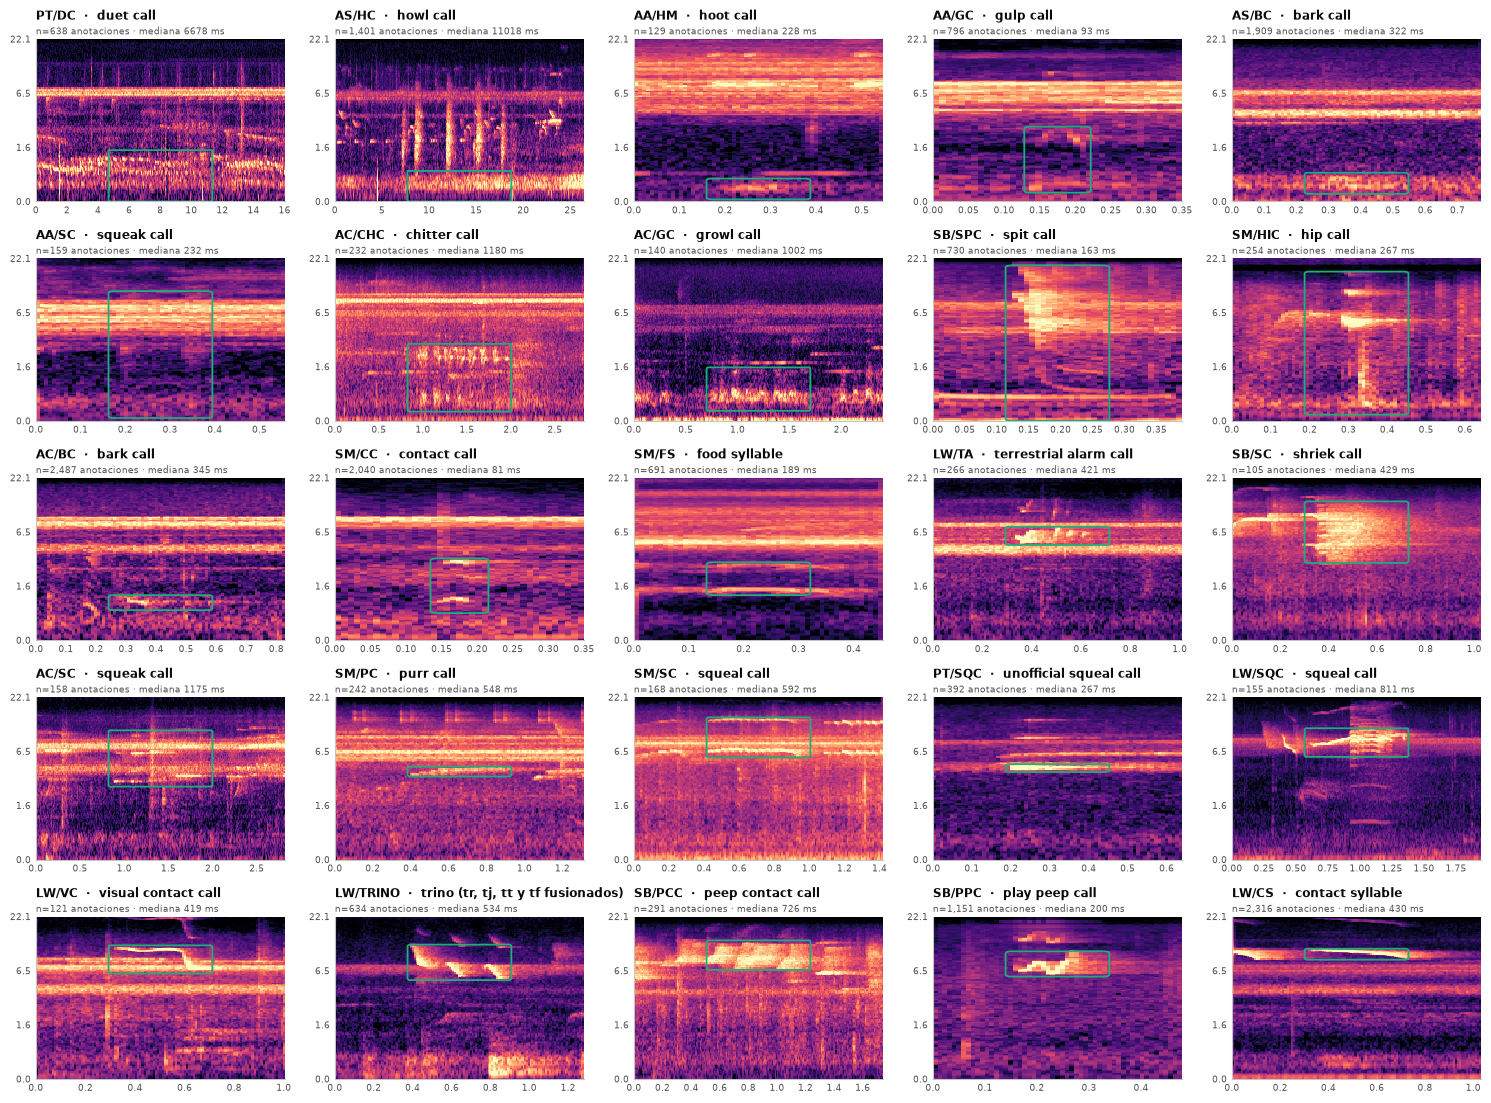

In [26]:
N_COLS = 5
n_rows = int(np.ceil(len(CLASSES) / N_COLS))
order = experiment.groupby("pair").low_freq_hz.median().sort_values().index.tolist()

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(3.0 * N_COLS, 2.35 * n_rows))
axes_flat = axes.ravel()
for ax, pair in zip(axes_flat, order):
    row = pick_annotation(pair, df=experiment)
    span = max(row.duration_s * 2.4, 0.35)
    start_s = max(row.begin_time_s - (span - row.duration_s) / 2, 0.0)
    try:
        waveform = load_segment(row.audio_path, start_s, span)
        draw_spectrogram(ax, log_mel(waveform), span, n_ticks=4)
        draw_box(
            ax,
            row.begin_time_s - start_s,
            row.end_time_s - start_s,
            row.low_freq_hz,
            row.high_freq_hz,
            color=GOOD,
            lw=1.3,
        )
    except Exception as exc:  # noqa: BLE001
        ax.text(0.5, 0.5, f"sin audio\n{exc}", ha="center", va="center", fontsize=7, color=CRITICAL)
    ax.set_title(f"{pair.upper()}  ·  {CALL_NAME.get(pair, '')}", fontsize=8.5, pad=14, loc="left")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=6.5)
    ax.text(
        0,
        1.015,
        f"n={int((experiment.pair == pair).sum()):,} anotaciones · mediana {row.duration_s * 1000:.0f} ms",
        transform=ax.transAxes,
        fontsize=6.8,
        color=INK_2,
        va="bottom",
    )

for ax in axes_flat[len(order) :]:
    ax.axis("off")

fig.tight_layout(rect=(0, 0, 1, 0.945))
save(
    fig,
    "call_gallery",
    where="Cap. 4, sección 4.1.3 (Composición del conjunto curado)",
    width=r"\textwidth",
    caption=(
        "Un ejemplo real de cada una de las clases del experimento, ordenadas por "
        "frecuencia mínima. La caja marca la anotación; el resto del panel es contexto. "
        "La comparación entre paneles muestra a la vez la separación por banda entre "
        "especies y la semejanza entre tipos de llamada de una misma especie."
    ),
)
plt.show()

## 6. Capítulo 5 — Arquitectura y pipelines

### 6.1 La geometría del modelo, leída del checkpoint

In [27]:
def pick_checkpoint():
    """El .pth cuyo número de clases coincide con el `labels.json` del caché."""
    candidates = sorted(CHECKPOINT_DIR.glob("*.pth"))
    if not candidates:
        return None
    wanted = len(CLASSES)
    scored = []
    for path in candidates:
        try:
            head = torch.load(path, map_location="cpu", weights_only=False)
        except Exception:
            continue
        scored.append((len(head.get("labels", [])) == wanted, path.stat().st_mtime, path))
    scored.sort(reverse=True)
    return scored[0][2] if scored else None


CHECKPOINT = pick_checkpoint()
if CHECKPOINT is not None:
    meta = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
    ARCH = {
        "dim": meta["dim"],
        "n_queries": meta["n_queries"],
        "n_levels": meta.get("n_levels", 3),
        "n_frames": meta.get("n_frames", P.n_frames),
        "time_stride": meta.get("time_stride", 5),
        "n_classes": len(meta["labels"]),
        "labels": list(meta["labels"]),
        "epoch": meta.get("epoch"),
        "recall_agn": meta.get("recall_agn"),
        "precision_agn": meta.get("precision_agn"),
        "config": meta.get("config", {}),
    }
    del meta
else:
    ARCH = {
        "dim": 128,
        "n_queries": 64,
        "n_levels": 3,
        "n_frames": P.n_frames,
        "time_stride": 2,
        "n_classes": len(CLASSES),
        "labels": CLASSES,
        "epoch": None,
        "recall_agn": None,
        "precision_agn": None,
        "config": {},
    }

PATCH, FREQ_STRIDE = 16, 10
FREQ_OUT = (P.n_mels - PATCH) // FREQ_STRIDE + 1
TIME_OUT = (ARCH["n_frames"] - PATCH) // ARCH["time_stride"] + 1
LEVELS = (
    [(FREQ_OUT * 2, TIME_OUT * 2), (FREQ_OUT, TIME_OUT), (FREQ_OUT // 2, TIME_OUT // 2)][
        3 - ARCH["n_levels"] :
    ]
    if ARCH["n_levels"] <= 3
    else []
)
LEVELS = [(FREQ_OUT * 2, TIME_OUT * 2), (FREQ_OUT, TIME_OUT), (FREQ_OUT // 2, TIME_OUT // 2)][
    : ARCH["n_levels"]
]

print("checkpoint:", CHECKPOINT.name if CHECKPOINT else "ninguno (se usan los valores por defecto)")
print(
    f"tokens AST: {FREQ_OUT} x {TIME_OUT} de dim 768 | pirámide: {LEVELS} | queries: {ARCH['n_queries']}"
)

checkpoint: 128d_64q_25cls_best_2.pth
tokens AST: 12 x 158 de dim 768 | pirámide: [(24, 316), (12, 158), (6, 79)] | queries: 64


### 6.2 `architecture` (Figura 5.1)

guardada -> research/figures/architecture.png  (110 kB)


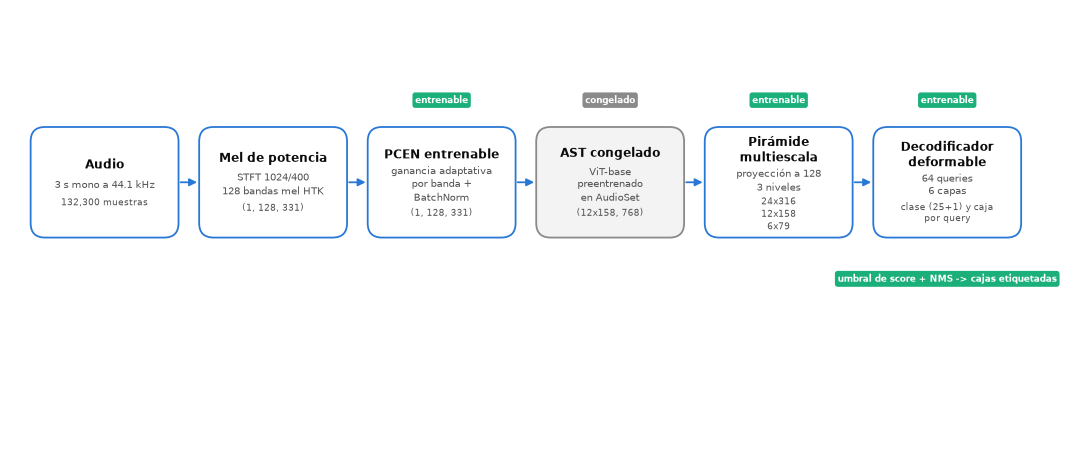

In [28]:
STAGES = [
    (
        "Audio",
        f"{P.clip_len_s:g} s mono a {P.target_sr / 1000:.1f} kHz",
        f"{P.clip_len_samples:,} muestras",
        None,
    ),
    (
        "Mel de potencia",
        f"STFT {P.win_length}/{P.hop_length}\n{P.n_mels} bandas mel HTK",
        f"(1, {P.n_mels}, {P.n_frames})",
        None,
    ),
    (
        "PCEN entrenable",
        "ganancia adaptativa\npor banda + BatchNorm",
        f"(1, {P.n_mels}, {P.n_frames})",
        "entrenable",
    ),
    (
        "AST congelado",
        "ViT-base preentrenado\nen AudioSet",
        f"({FREQ_OUT}x{TIME_OUT}, 768)",
        "congelado",
    ),
    (
        "Pirámide multiescala",
        f"proyección a {ARCH['dim']}\n{ARCH['n_levels']} niveles",
        "\n".join(f"{f}x{t}" for f, t in LEVELS),
        "entrenable",
    ),
    (
        "Decodificador\ndeformable",
        f"{ARCH['n_queries']} queries\n6 capas",
        f"clase ({ARCH['n_classes']}+1) y caja\npor query",
        "entrenable",
    ),
]

fig, ax = canvas(13.4, 5.6)
TOP = 100 * 5.6 / 13.4
cy = TOP * 0.60
boxes = flow_row(
    ax,
    [
        {
            "title": name,
            "body": detail,
            "foot": shape,
            "kw": {
                "fill": PANEL if state == "congelado" else SURFACE,
                "edge": MUTED if state == "congelado" else BLUE,
            },
        }
        for name, detail, shape, state in STAGES
    ],
    cy,
    margin=2.0,
    gap=2.0,
    wrap=19,
    lw=1.3,
    fs=8.4,
    body_fs=7.0,
    foot_fs=6.8,
    foot_ink=INK_2,
)
for (cx, _, w, h), (_, _, _, state) in zip(boxes, STAGES):
    if state:
        chip(ax, cx, cy + h / 2 + 2.6, state, MUTED if state == "congelado" else GOOD, fs=6.4)

box_h = boxes[0][3]
last_cx = boxes[-1][0]
chip(ax, last_cx, cy - box_h / 2 - 4.0, "umbral de score + NMS -> cajas etiquetadas", GOOD, fs=6.8)

save(
    fig,
    "architecture",
    where="Cap. 5, sección 5.1 (Figura 5.1)",
    caption=(
        "Arquitectura propuesta. El espectrograma log-mel pasa por una capa PCEN "
        "entrenable, un Audio Spectrogram Transformer congelado y una pirámide "
        "multiescala; el decodificador deformable emite un conjunto de "
        f"{ARCH['n_queries']} candidatos, cada uno con su clase y su caja. Sólo los "
        "bloques marcados como entrenables reciben gradiente."
    ),
)
plt.show()

### 6.3 `multiscale_pyramid`

guardada -> research/figures/multiscale_pyramid.png  (152 kB)


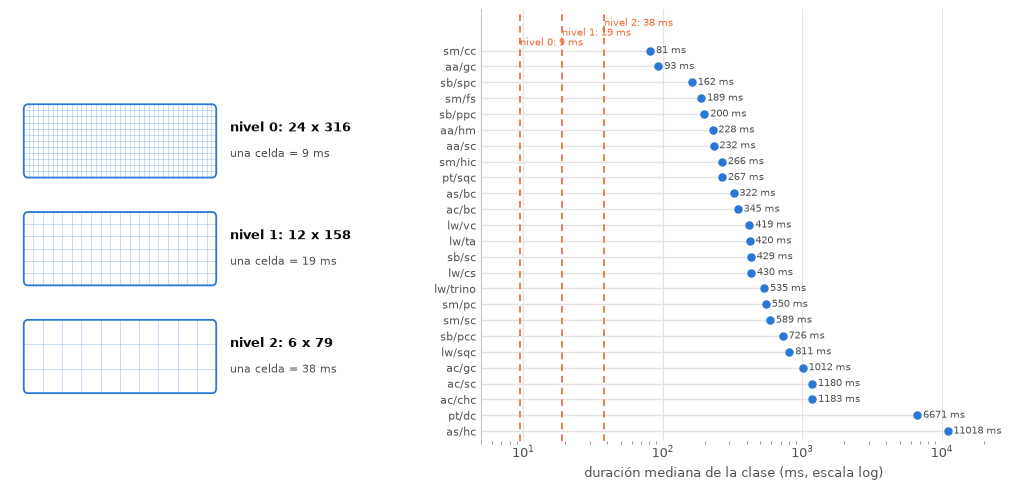

In [29]:
cell_ms = [P.clip_len_s * 1000 / t for _, t in LEVELS]
durations = experiment.groupby("pair").duration_s.median().sort_values() * 1000

fig, axes = plt.subplots(
    1, 2, figsize=(12.6, 5.6), gridspec_kw={"width_ratios": [0.85, 1.25], "wspace": 0.30}
)

ax = axes[0]
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis("off")
for i, ((f, t), ms) in enumerate(zip(LEVELS, cell_ms)):
    y = 70 - i * 25
    ax.add_patch(
        FancyBboxPatch(
            (4, y - 9),
            56,
            17,
            boxstyle="round,pad=0,rounding_size=1.2",
            facecolor=SURFACE,
            edgecolor=BLUE,
            linewidth=1.3,
        )
    )
    cols = max(4, int(round(40 * t / LEVELS[0][1])))
    rows = max(2, int(round(12 * f / LEVELS[0][0])))
    for c in range(1, cols):
        ax.plot([4 + 56 * c / cols] * 2, [y - 9, y + 8], color=BLUE, linewidth=0.4, alpha=0.45)
    for r in range(1, rows):
        ax.plot([4, 60], [y - 9 + 17 * r / rows] * 2, color=BLUE, linewidth=0.4, alpha=0.45)
    ax.text(
        64,
        y + 2.5,
        f"nivel {i}: {f} x {t}",
        fontsize=9.5,
        fontweight="bold",
        color=INK,
        va="center",
    )
    ax.text(64, y - 3.5, f"una celda = {ms:.0f} ms", fontsize=8.2, color=INK_2, va="center")

ax = axes[1]
ys = np.arange(len(durations))
ax.set_xscale("log")
ax.set_xlim(5, max(durations.max() * 1.9, 4000))
ax.set_ylim(len(durations) - 0.4, -2.6)
for y, (pair, value) in zip(ys, durations.items()):
    ax.plot([5, value], [y, y], color=GRID, linewidth=1.0, zorder=1)
    ax.scatter([value], [y], s=26, color=BLUE, zorder=3)
    ax.text(value * 1.10, y, f"{value:.0f} ms", va="center", fontsize=7, color=INK_2)
for i, ms in enumerate(cell_ms):
    ax.axvline(ms, color=SERIES[1], linewidth=1.2, linestyle=(0, (4, 3)), zorder=2)
    ax.text(
        ms,
        -0.5 - i * 0.62,
        f"nivel {i}: {ms:.0f} ms",
        color=SERIES[1],
        fontsize=7.5,
        ha="left",
        va="center",
    )
ax.set_yticks(ys, durations.index, fontsize=8)
ax.set_xlabel("duración mediana de la clase (ms, escala log)")
style_value_axis(ax, "x")

save(
    fig,
    "multiscale_pyramid",
    where="Cap. 5, sección 5.1 - junto a la tabla de desviaciones de la receta estándar",
    caption=(
        "La pirámide multiescala y las duraciones reales. Cada nivel reconstruye el mapa "
        "del AST a una resolución distinta; la columna de un nivel cubre entre "
        f"{min(cell_ms):.0f} y {max(cell_ms):.0f}\\,ms de audio, y las clases del "
        "experimento se reparten a ambos lados de esos pasos."
    ),
)
plt.show()

### 6.4 `deformable_sampling`

guardada -> research/figures/deformable_sampling.png  (46 kB)


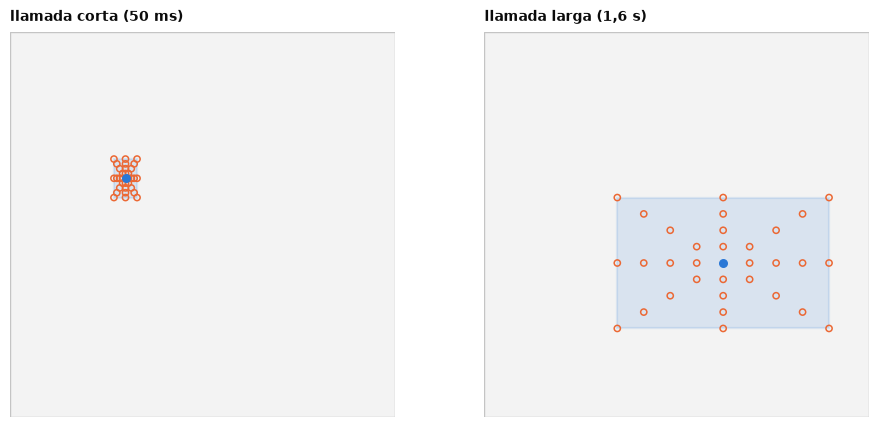

In [30]:
from architectures.deformable_detr import DeformableAttention  # noqa: E402

attention = DeformableAttention(dim=ARCH["dim"], n_heads=8, n_points=4, n_levels=ARCH["n_levels"])
offsets = attention.offsets.bias.detach().view(8, ARCH["n_levels"], 4, 2).numpy()

REFERENCES = [
    ((0.30, 0.62, 0.06, 0.10), "llamada corta (50 ms)"),
    ((0.62, 0.40, 0.55, 0.34), "llamada larga (1,6 s)"),
]

fig, axes = plt.subplots(1, 2, figsize=(11.4, 5.0), gridspec_kw={"wspace": 0.16})
for ax, (ref, name) in zip(axes, REFERENCES):
    cx, cy, w, h = ref
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=PANEL, edgecolor=BASELINE, linewidth=1.0))
    ax.add_patch(
        Rectangle(
            (cx - w / 2, cy - h / 2),
            w,
            h,
            facecolor=BLUE,
            alpha=0.13,
            edgecolor=BLUE,
            linewidth=1.6,
        )
    )
    ax.scatter([cx], [cy], s=30, color=BLUE, zorder=5)
    points = offsets[:, 0] / 4.0 * np.array([w, h]) * 0.5 + np.array([cx, cy])
    ax.scatter(
        points[..., 0].ravel(),
        points[..., 1].ravel(),
        s=20,
        marker="o",
        facecolor="none",
        edgecolors=SERIES[1],
        linewidths=1.1,
        zorder=4,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.set_title(name, fontsize=10, pad=8)

save(
    fig,
    "deformable_sampling",
    where="Cap. 5, sección 5.1 - al explicar la atención deformable",
    caption=(
        "Puntos de muestreo de una \\textit{query} en la inicialización radial de "
        "Zhu et al. Los desplazamientos se expresan como fracción de la caja de "
        "referencia, de modo que la vecindad que la \\textit{query} inspecciona crece con "
        "el evento que sigue: es lo que permite atender con el mismo mecanismo a llamadas "
        "de decenas de milisegundos y de segundos."
    ),
)
plt.show()

### 6.5 `decoder_layer`

guardada -> research/figures/decoder_layer.png  (84 kB)


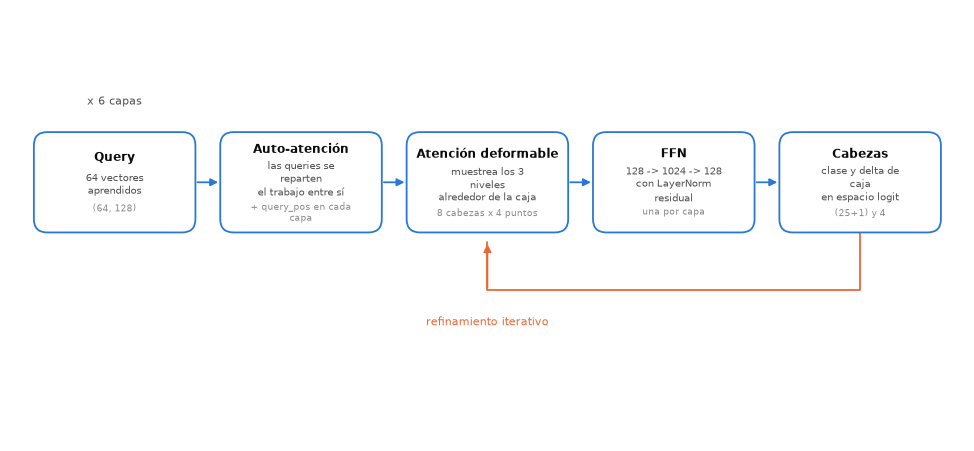

In [31]:
fig, ax = canvas(12.4, 5.6)
TOP = 100 * 5.6 / 12.4
cy = TOP * 0.60
blocks = flow_row(
    ax,
    [
        {
            "title": "Query",
            "body": f"{ARCH['n_queries']} vectores\naprendidos",
            "foot": f"({ARCH['n_queries']}, {ARCH['dim']})",
        },
        {
            "title": "Auto-atención",
            "body": "las queries se reparten\nel trabajo entre sí",
            "foot": "+ query_pos en cada capa",
        },
        {
            "title": "Atención deformable",
            "body": "muestrea los 3 niveles\nalrededor de la caja",
            "foot": "8 cabezas x 4 puntos",
        },
        {
            "title": "FFN",
            "body": f"{ARCH['dim']} -> 1024 -> {ARCH['dim']}\ncon LayerNorm residual",
            "foot": "una por capa",
        },
        {
            "title": "Cabezas",
            "body": "clase y delta de caja\nen espacio logit",
            "foot": f"({ARCH['n_classes']}+1) y 4",
        },
    ],
    cy,
    margin=2.5,
    gap=2.6,
    wrap=20,
    fill=SURFACE,
    edge=BLUE,
    lw=1.3,
    fs=8.6,
    body_fs=7.2,
    foot_fs=6.8,
)
h = blocks[0][3]
caption_at(ax, blocks[0][0], cy + h / 2 + 3.2, "x 6 capas", fs=8, color=INK_2)
elbow(
    ax,
    [
        (blocks[-1][0], cy - h / 2),
        (blocks[-1][0], cy - h / 2 - 6),
        (blocks[2][0], cy - h / 2 - 6),
        (blocks[2][0], cy - h / 2 - 1),
    ],
    color=SERIES[1],
)
caption_at(
    ax,
    blocks[2][0],
    cy - h / 2 - 8.5,
    "refinamiento iterativo",
    fs=7.6,
    color=SERIES[1],
    wrap=90,
    va="top",
)
save(
    fig,
    "decoder_layer",
    where="Cap. 5, sección 5.1 - junto a la tabla de desviaciones",
    caption=(
        "Una capa del decodificador y el refinamiento iterativo de la caja. Las seis "
        "capas comparten estructura y cada una emite su propia predicción; la caja "
        "predicha por una capa es la referencia de muestreo de la siguiente."
    ),
)
plt.show()

### 6.6 `hungarian_matching`

Las cajas del ejemplo son ilustrativas; el cálculo sale de `HungarianMatcher`.

guardada -> research/figures/hungarian_matching.png  (52 kB)


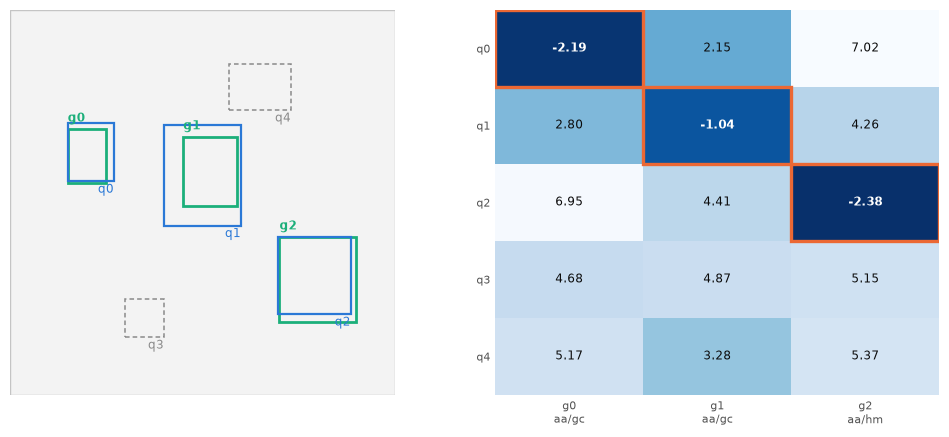

In [32]:
from architectures.criterion import HungarianMatcher  # noqa: E402
from scipy.optimize import linear_sum_assignment  # noqa: E402

truth_boxes = torch.tensor(
    [[0.20, 0.62, 0.10, 0.14], [0.52, 0.58, 0.14, 0.18], [0.80, 0.30, 0.20, 0.22]],
    dtype=torch.float32,
)
truth_labels = torch.tensor([0, 0, 1])
predicted_boxes = torch.tensor(
    [
        [0.21, 0.63, 0.12, 0.15],  # buena sobre la primera
        [0.50, 0.57, 0.20, 0.26],  # laxa sobre la segunda
        [0.79, 0.31, 0.19, 0.20],  # buena sobre la tercera
        [0.35, 0.20, 0.10, 0.10],  # fondo
        [0.65, 0.80, 0.16, 0.12],  # fondo
    ],
    dtype=torch.float32,
)
logits = torch.full((5, 3), -2.0)
logits[0, 0] = logits[2, 1] = 3.0
logits[1, 0] = 1.2
logits[3, 2] = logits[4, 2] = 2.5  # el canal de no-objeto

matcher = HungarianMatcher()
outputs = {"pred_logits": logits[None], "pred_boxes": predicted_boxes[None]}
targets = [{"labels": truth_labels, "boxes": truth_boxes}]
query_index, target_index = matcher(outputs, targets)[0]

probabilities = logits.softmax(-1)
cost_class = -probabilities[:, truth_labels]
cost_bbox = torch.cdist(predicted_boxes, truth_boxes, p=1)
from torchvision.ops import box_convert, generalized_box_iou  # noqa: E402

cost_iou = -generalized_box_iou(
    box_convert(predicted_boxes, "cxcywh", "xyxy"), box_convert(truth_boxes, "cxcywh", "xyxy")
)
cost = (
    matcher.cost_class * cost_class + matcher.cost_bbox * cost_bbox + matcher.cost_iou * cost_iou
).numpy()

fig, axes = plt.subplots(
    1, 2, figsize=(12.0, 5.0), gridspec_kw={"width_ratios": [1, 1.15], "wspace": 0.24}
)

ax = axes[0]
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=PANEL, edgecolor=BASELINE, linewidth=1.0))
for i, box in enumerate(truth_boxes.numpy()):
    cx, cy, w, h = box
    ax.add_patch(
        Rectangle((cx - w / 2, cy - h / 2), w, h, facecolor="none", edgecolor=GOOD, linewidth=2.0)
    )
    ax.text(cx - w / 2, cy + h / 2 + 0.02, f"g{i}", color=GOOD, fontsize=8.5, fontweight="bold")
for j, box in enumerate(predicted_boxes.numpy()):
    cx, cy, w, h = box
    matched = j in query_index.tolist()
    ax.add_patch(
        Rectangle(
            (cx - w / 2, cy - h / 2),
            w,
            h,
            facecolor="none",
            edgecolor=BLUE if matched else MUTED,
            linewidth=1.6 if matched else 1.1,
            linestyle="-" if matched else (0, (3, 2)),
        )
    )
    ax.text(
        cx + w / 2,
        cy - h / 2 - 0.03,
        f"q{j}",
        color=BLUE if matched else MUTED,
        fontsize=8.5,
        ha="right",
    )
ax.set_xticks([])
ax.set_yticks([])
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

ax = axes[1]
image = ax.imshow(cost, cmap="Blues_r", aspect="auto")
for j in range(cost.shape[0]):
    for i in range(cost.shape[1]):
        chosen = (j, i) in list(zip(query_index.tolist(), target_index.tolist()))
        ax.text(
            i,
            j,
            f"{cost[j, i]:.2f}",
            ha="center",
            va="center",
            fontsize=8.5,
            color=INK if cost[j, i] > cost.min() + (cost.max() - cost.min()) * 0.45 else SURFACE,
            fontweight="bold" if chosen else "normal",
        )
        if chosen:
            ax.add_patch(
                Rectangle(
                    (i - 0.5, j - 0.5), 1, 1, facecolor="none", edgecolor=SERIES[1], linewidth=2.4
                )
            )
ax.set_xticks(
    range(3),
    [f"g{i}\n{CLASSES[label]}" for i, label in enumerate(truth_labels.tolist())],
    fontsize=8,
)
ax.set_yticks(range(5), [f"q{j}" for j in range(5)], fontsize=8)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

save(
    fig,
    "hungarian_matching",
    where="Cap. 5, sección 5.2 (Pipeline de entrenamiento)",
    caption=(
        "Emparejamiento húngaro entre \\textit{queries} y anotaciones. El costo combina "
        "clase, distancia $L_1$ entre cajas y GIoU con los pesos de "
        "\\texttt{HungarianMatcher}; la asignación resultante es uno a uno, y las "
        "\\textit{queries} sin pareja se entrenan contra la clase de no-objeto. Las cajas "
        "del ejemplo son ilustrativas; el cálculo es el del código."
    ),
)
plt.show()

### 6.7 `training_pipeline` e `inference_pipeline`

Los hiperparámetros se importan de `train.py`.

guardada -> research/figures/training_pipeline.png  (98 kB)


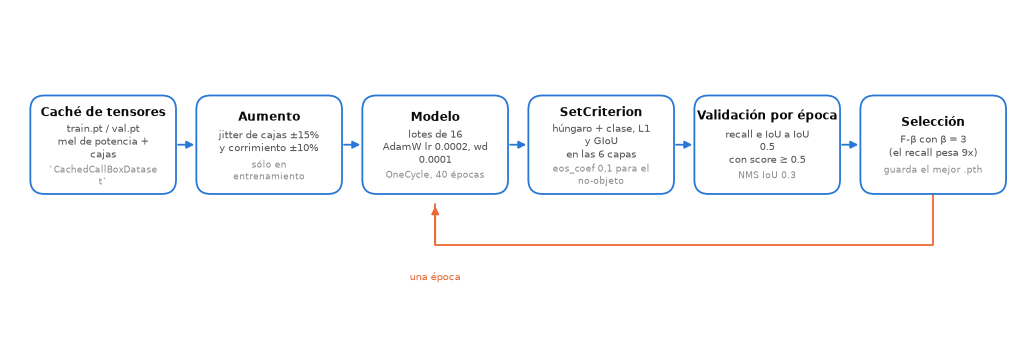

In [33]:
from train import (  # noqa: E402
    BATCH_SIZE,
    BOX_JITTER,
    CHECKPOINT_SELECTION_BETA,
    EPOCHS,
    LEARNING_RATE,
    METRIC_IOU_THRESHOLD,
    NMS_IOU,
    OPERATING_SCORE_THRESHOLD,
    WEIGHT_DECAY,
)

fig, ax = canvas(13.2, 4.4)
TOP = 100 * 4.4 / 13.2
cy = TOP * 0.60
boxes = flow_row(
    ax,
    [
        {
            "title": "Caché de tensores",
            "body": "train.pt / val.pt\nmel de potencia + cajas",
            "foot": "`CachedCallBoxDataset`",
        },
        {
            "title": "Aumento",
            "body": f"jitter de cajas ±{BOX_JITTER.scale:.0%}\ny corrimiento ±{BOX_JITTER.shift:.0%}",
            "foot": "sólo en entrenamiento",
        },
        {
            "title": "Modelo",
            "body": f"lotes de {BATCH_SIZE}\nAdamW lr {LEARNING_RATE:g}, wd {WEIGHT_DECAY:g}",
            "foot": f"OneCycle, {EPOCHS} épocas",
        },
        {
            "title": "SetCriterion",
            "body": "húngaro + clase, L1 y GIoU\nen las 6 capas",
            "foot": "eos_coef 0,1 para el no-objeto",
        },
        {
            "title": "Validación por época",
            "body": f"recall e IoU a IoU {METRIC_IOU_THRESHOLD:g}\ncon score ≥ {OPERATING_SCORE_THRESHOLD:g}",
            "foot": f"NMS IoU {NMS_IOU:g}",
        },
        {
            "title": "Selección",
            "body": f"F-β con β = {CHECKPOINT_SELECTION_BETA:g}\n(el recall pesa 9x)",
            "foot": "guarda el mejor .pth",
        },
    ],
    cy,
    margin=2.0,
    gap=2.0,
    wrap=20,
    fill=SURFACE,
    edge=BLUE,
    lw=1.3,
    fs=8.4,
    body_fs=7.0,
    foot_fs=6.7,
)
h = boxes[0][3]
elbow(
    ax,
    [
        (boxes[-1][0], cy - h / 2),
        (boxes[-1][0], cy - h / 2 - 5),
        (boxes[2][0], cy - h / 2 - 5),
        (boxes[2][0], cy - h / 2 - 1),
    ],
    color=SERIES[1],
)
caption_at(ax, boxes[2][0], cy - h / 2 - 7.5, "una época", fs=7.4, color=SERIES[1], va="top")
save(
    fig,
    "training_pipeline",
    where="Cap. 5, sección 5.2 (Pipeline de entrenamiento e inferencia)",
    caption=(
        "Pipeline de entrenamiento. El \\textit{checkpoint} se elige por una F-$\\beta$ "
        f"con $\\beta = {CHECKPOINT_SELECTION_BETA:g}$ sobre la partición de validación, "
        "que pondera el \\textit{recall} nueve veces más que la precisión; la partición "
        "de prueba se reserva para el reporte final."
    ),
)
plt.show()

guardada -> research/figures/inference_pipeline.png  (77 kB)


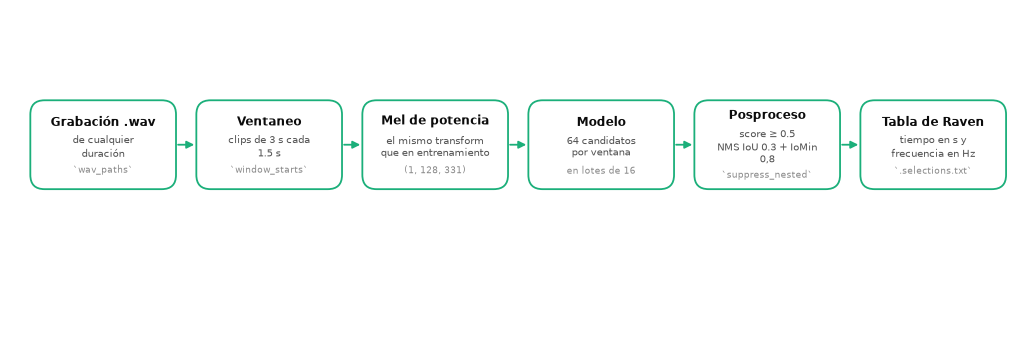

In [34]:
fig, ax = canvas(13.2, 4.4)
TOP = 100 * 4.4 / 13.2
cy = TOP * 0.60
boxes = flow_row(
    ax,
    [
        {"title": "Grabación .wav", "body": "de cualquier duración", "foot": "`wav_paths`"},
        {
            "title": "Ventaneo",
            "body": f"clips de {P.clip_len_s:g} s cada {P.clip_hop_s:g} s",
            "foot": "`window_starts`",
        },
        {
            "title": "Mel de potencia",
            "body": "el mismo transform\nque en entrenamiento",
            "foot": f"(1, {P.n_mels}, {P.n_frames})",
        },
        {
            "title": "Modelo",
            "body": f"{ARCH['n_queries']} candidatos\npor ventana",
            "foot": "en lotes de 16",
        },
        {
            "title": "Posproceso",
            "body": f"score ≥ {OPERATING_SCORE_THRESHOLD:g}\nNMS IoU {NMS_IOU:g} + IoMin 0,8",
            "foot": "`suppress_nested`",
        },
        {
            "title": "Tabla de Raven",
            "body": "tiempo en s y\nfrecuencia en Hz",
            "foot": "`.selections.txt`",
        },
    ],
    cy,
    margin=2.0,
    gap=2.0,
    wrap=20,
    fill=SURFACE,
    edge=SERIES[2],
    arrow_color=SERIES[2],
    lw=1.3,
    fs=8.4,
    body_fs=7.0,
    foot_fs=6.7,
)
save(
    fig,
    "inference_pipeline",
    where="Cap. 5, sección 5.2 y sección 5.5 (Exportación a Raven)",
    caption=(
        "Pipeline de inferencia. La grabación se recorre con el mismo ventaneo y el mismo "
        "preprocesamiento del entrenamiento; el posprocesamiento funde las detecciones "
        "repetidas entre ventanas solapadas y escribe una tabla de selección con las "
        "columnas que espera Raven."
    ),
)
plt.show()

## 7. Capítulo 5 — Resultados

Necesita `checkpoint` y el caché de `data/processed/`. Para las cifras de la tesis,
`MAX_EVAL_WINDOWS = None` y GPU.

In [35]:
MAX_EVAL_WINDOWS = 384  # None = la partición entera (obligatorio para las cifras finales)
EVAL_SPLIT = "test"
EVAL_BATCH = 8

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_MODEL = CHECKPOINT is not None and (CACHE_DIR / f"{EVAL_SPLIT}.pt").exists()
print(f"device: {DEVICE} | checkpoint: {CHECKPOINT.name if CHECKPOINT else 'ninguno'}")
print(f"caché {EVAL_SPLIT}.pt: {'sí' if (CACHE_DIR / f'{EVAL_SPLIT}.pt').exists() else 'no'}")
if not RUN_MODEL:
    print(
        "\nSin modelo o sin caché: la sección 7 se salta y las figuras de resultados no se regeneran."
    )

device: cpu | checkpoint: 128d_64q_25cls_best_2.pth
caché test.pt: sí


In [36]:
if RUN_MODEL:
    from torch.utils.data import DataLoader, Subset  # noqa: E402

    from torchvision.ops import box_convert  # noqa: E402

    from architectures.criterion import HungarianMatcher  # noqa: E402
    from architectures.iou import box_iou_pairwise, suppress_nested  # noqa: E402
    from domain.dataset import CachedCallBoxDataset, collate_fn  # noqa: E402
    from infer import load_model  # noqa: E402
    from pipelines.evaluation_pipeline import Boxes, _concat, _hits, _overlaps  # noqa: E402

    loaded = load_model(CHECKPOINT, DEVICE)
    label_names = loaded.labels.names
    dataset = CachedCallBoxDataset(CACHE_DIR / f"{EVAL_SPLIT}.pt")
    if MAX_EVAL_WINDOWS and MAX_EVAL_WINDOWS < len(dataset):
        index = np.random.default_rng(42).choice(len(dataset), MAX_EVAL_WINDOWS, replace=False)
        subset = Subset(dataset, sorted(index.tolist()))
    else:
        subset = dataset
    loader = DataLoader(subset, batch_size=EVAL_BATCH, shuffle=False, collate_fn=collate_fn)
    EVAL_NOTE = (
        ""
        if len(subset) == len(dataset)
        else f" · MUESTRA de {len(subset):,} de {len(dataset):,} ventanas: las clases con pocas cajas son ruidosas"
    )
    print(
        f"{len(subset):,} de {len(dataset):,} ventanas de {EVAL_SPLIT} · "
        f"score de operación {loaded.score_threshold:g} · NMS {loaded.nms_iou:g}"
    )
    if EVAL_NOTE:
        print("Para las cifras de la tesis, poné MAX_EVAL_WINDOWS = None y corré con GPU.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

384 de 8,007 ventanas de test · score de operación 0.5 · NMS 0.3
Para las cifras de la tesis, poné MAX_EVAL_WINDOWS = None y corré con GPU.


### 7.1 Una pasada que alimenta todas las figuras de resultados

Usa las funciones de `pipelines.evaluation_pipeline`, así que coincide con `src/eval.py`.

In [37]:
if RUN_MODEL:
    from architectures.deformable_detr import predict_scores  # noqa: E402
    from tqdm.auto import tqdm  # noqa: E402

    @torch.no_grad()
    def collect(model, loader, matcher, n_classes, nms_iou, device, keep_windows=48):
        model.eval()
        predicted_chunks, truth_chunks, windows = [], [], []
        matched_iou, true_classes, predicted_classes = [], [], []
        image_id = 0
        for images, targets in tqdm(loader, desc="inferencia", unit="lote"):
            images = images.to(device)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            outputs = model(images)
            boxes = outputs["pred_boxes"]
            scores, labels = predict_scores(outputs)
            decided = outputs["pred_logits"].argmax(-1)

            for b, (query_idx, target_idx) in enumerate(matcher(outputs, targets)):
                target = targets[b]
                if len(query_idx):
                    matched_iou.append(
                        box_iou_pairwise(
                            box_convert(boxes[b, query_idx], "cxcywh", "xyxy"),
                            box_convert(target["boxes"][target_idx], "cxcywh", "xyxy"),
                        ).cpu()
                    )
                    true_classes.append(target["labels"][target_idx].cpu())
                    predicted_classes.append(decided[b, query_idx].cpu())

                keep = suppress_nested(
                    box_convert(boxes[b], "cxcywh", "xyxy"), scores[b], labels[b], nms_iou
                )
                kept = boxes[b][keep]
                predicted_chunks.append(
                    Boxes(
                        kept,
                        torch.full((len(kept),), image_id, device=kept.device),
                        labels[b][keep],
                        scores[b][keep],
                    )
                )
                n_target = len(target["labels"])
                truth_chunks.append(
                    Boxes(
                        target["boxes"],
                        torch.full((n_target,), image_id, device=target["boxes"].device),
                        target["labels"],
                        torch.ones(n_target, device=target["boxes"].device),
                    )
                )
                if len(windows) < keep_windows:
                    windows.append(
                        {
                            "image": images[b, 0].cpu().numpy(),
                            "truth_boxes": target["boxes"].cpu().numpy(),
                            "truth_labels": target["labels"].cpu().numpy(),
                            "boxes": kept.cpu().numpy(),
                            "labels": labels[b][keep].cpu().numpy(),
                            "scores": scores[b][keep].cpu().numpy(),
                        }
                    )
                image_id += 1

        predictions = _concat(predicted_chunks)
        predictions = predictions.select(predictions.scores.argsort(descending=True, stable=True))
        truth = _concat(truth_chunks)
        confusion = torch.zeros(n_classes, n_classes + 1, dtype=torch.int64)
        if true_classes:
            confusion.index_put_(
                (torch.cat(true_classes), torch.cat(predicted_classes)),
                torch.ones(len(torch.cat(true_classes)), dtype=torch.int64),
                accumulate=True,
            )
        return {
            "predictions": predictions,
            "truth": truth,
            "matched_iou": torch.cat(matched_iou).numpy() if matched_iou else np.zeros(0),
            "confusion": confusion,
            "windows": windows,
            "n_windows": image_id,
        }

    matcher = HungarianMatcher()
    result = collect(loaded.model, loader, matcher, len(label_names), loaded.nms_iou, DEVICE)
    print(
        f"{len(result['predictions'].boxes):,} predicciones · {len(result['truth'].boxes):,} "
        f"anotaciones · IoU medio de los pares emparejados {result['matched_iou'].mean():.3f}"
    )

inferencia:   0%|          | 0/48 [00:00<?, ?lote/s]

8,066 predicciones · 379 anotaciones · IoU medio de los pares emparejados 0.694


### 7.2 `score_sweep`

punto de operación score ≥ 0.5: recall 0.694 · precisión 0.492 · FP/TP 1.03
guardada -> research/figures/score_sweep.png  (86 kB)


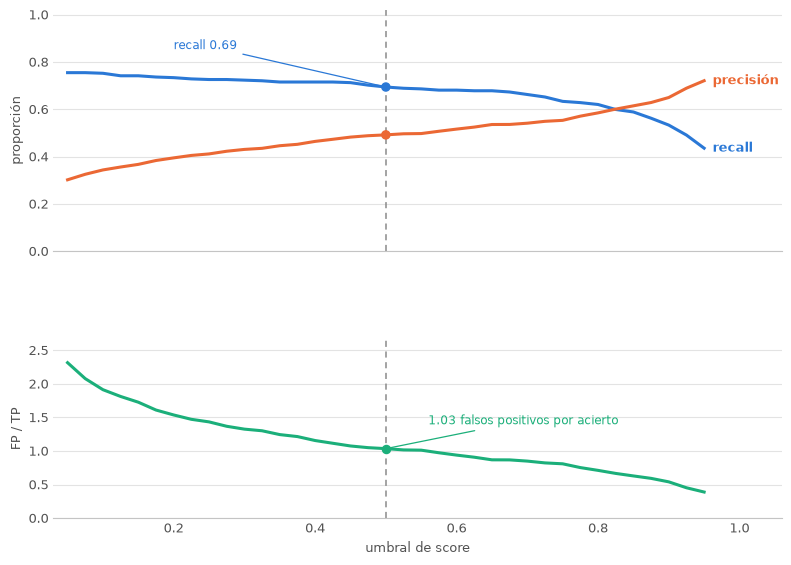

In [38]:
if RUN_MODEL:
    predictions, truth = result["predictions"], result["truth"]
    n_gt = len(truth.boxes)
    n_pred = len(predictions.boxes)
    iou_threshold = float(loaded.config.get("metric_iou_threshold", 0.5))

    hits_agnostic = _hits(_overlaps(predictions, truth), n_pred, iou_threshold)
    hits_by_class = _hits(_overlaps(predictions, truth, class_aware=True), n_pred, iou_threshold)
    scores = predictions.scores.numpy()

    def metrics_at(threshold, hits=None):
        hits = hits_agnostic if hits is None else hits
        k = int((scores >= threshold).sum())
        tp = float(hits[:k].sum())
        recall = tp / n_gt if n_gt else float("nan")
        precision = tp / k if k else float("nan")
        return {
            "k": k,
            "tp": tp,
            "recall": recall,
            "precision": precision,
            "fp_per_tp": (k - tp) / tp if tp else float("nan"),
        }

    operating = loaded.score_threshold
    grid = np.linspace(0.05, 0.95, 37)
    sweep = pd.DataFrame([metrics_at(t) for t in grid], index=grid)
    point = metrics_at(operating)
    print(
        f"punto de operación score ≥ {operating:g}: recall {point['recall']:.3f} · "
        f"precisión {point['precision']:.3f} · FP/TP {point['fp_per_tp']:.2f}"
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(9.4, 6.6),
        sharex=True,
        gridspec_kw={"height_ratios": [1.35, 1], "hspace": 0.42},
    )

    ax = axes[0]
    for column, color, name in (("recall", BLUE, "recall"), ("precision", SERIES[1], "precisión")):
        ax.plot(sweep.index, sweep[column], color=color, linewidth=2.2)
        ax.text(
            sweep.index[-1] + 0.012,
            sweep[column].iloc[-1],
            name,
            color=color,
            fontsize=9,
            va="center",
            fontweight="bold",
        )
    ax.axvline(operating, color=MUTED, linewidth=1.1, linestyle=(0, (4, 3)))
    ax.scatter(
        [operating, operating],
        [point["recall"], point["precision"]],
        s=34,
        color=[BLUE, SERIES[1]],
        zorder=5,
    )
    ax.annotate(
        f"recall {point['recall']:.2f}",
        xy=(operating, point["recall"]),
        xytext=(operating - 0.30, min(point["recall"] + 0.16, 0.98)),
        color=BLUE,
        fontsize=8.5,
        arrowprops=dict(arrowstyle="-", color=BLUE, linewidth=0.9),
    )
    ax.set_ylim(0, 1.02)
    ax.set_xlim(0.03, 1.06)
    ax.set_ylabel("proporción")
    style_value_axis(ax, "y")

    ax = axes[1]
    ax.plot(sweep.index, sweep.fp_per_tp, color=SERIES[2], linewidth=2.2)
    ax.axvline(operating, color=MUTED, linewidth=1.1, linestyle=(0, (4, 3)))
    ax.scatter([operating], [point["fp_per_tp"]], s=34, color=SERIES[2], zorder=5)
    ax.annotate(
        f"{point['fp_per_tp']:.2f} falsos positivos por acierto",
        xy=(operating, point["fp_per_tp"]),
        xytext=(operating + 0.06, point["fp_per_tp"] * 1.35),
        color=SERIES[2],
        fontsize=8.5,
        arrowprops=dict(arrowstyle="-", color=SERIES[2], linewidth=0.9),
    )
    ax.set_ylim(0, min(np.nanmax(sweep.fp_per_tp) * 1.15, 12))
    ax.set_xlabel("umbral de score")
    ax.set_ylabel("FP / TP")
    style_value_axis(ax, "y")

    save(
        fig,
        "score_sweep",
        where="Cap. 5, sección 5.3 (Protocolo de evaluación) o 5.4 (Resultados)",
        width=r"0.9\textwidth",
        caption=(
            "Efecto del umbral de confianza sobre el \\textit{recall}, la precisión y la "
            "carga de revisión. La línea vertical marca el punto de operación con el que "
            "se seleccionó el \\textit{checkpoint} y con el que se reportan todas las "
            "cifras."
        ),
    )
    plt.show()

### 7.3 `recall_per_class` (Figura 5.2)

La causa de cada caída se calcula desde el propio conjunto.

   clase  recall  cajas                                     nota
   aa/hm   1.000      2                                         
   as/hc   0.935     93                 82% inalcanzable (> 6 s)
  sm/hic   0.800      5 geometría heterogénea (CV de banda 0.54)
   pt/dc   0.778     36                 58% inalcanzable (> 6 s)
   lw/cs   0.756     45   anidada en una clase de frase excluida
  pt/sqc   0.750      4                                         
   sm/fs   0.714      7   anidada en una clase de frase excluida
   ac/bc   0.690     29 geometría heterogénea (CV de banda 0.60)
lw/trino   0.625      8                                         
   as/bc   0.583     24                                         
   aa/gc   0.571     14                         mediana de 93 ms
   sm/cc   0.550     40                         mediana de 81 ms
  sb/ppc   0.524     21   anidada en una clase de frase excluida
  sb/spc   0.500     10                                         
   lw/vc   0.500      2  

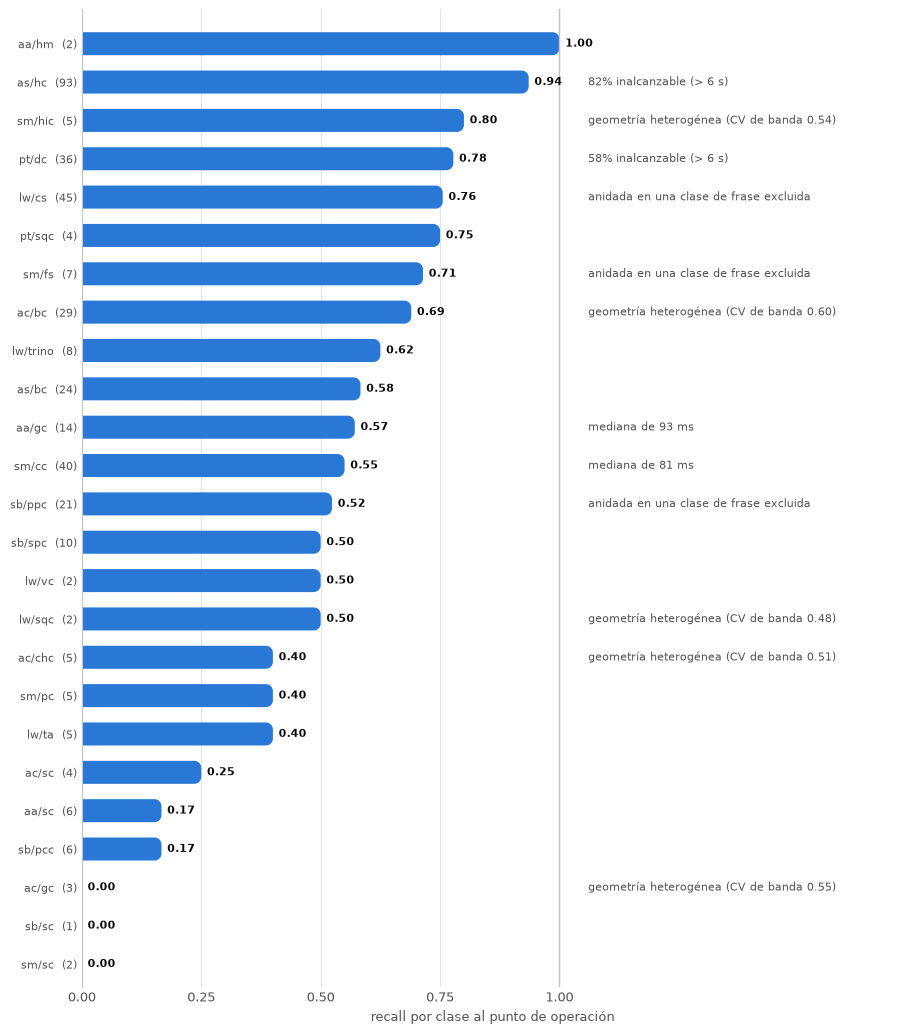

In [39]:
if RUN_MODEL:
    unreachable = (
        experiment.assign(long=experiment.duration_s > 2 * P.clip_len_s).groupby("pair").long.mean()
    )
    bandwidth_cv = (
        experiment.groupby("pair").bandwidth_hz.std()
        / experiment.groupby("pair").bandwidth_hz.mean()
    )
    median_ms = experiment.groupby("pair").duration_s.median() * 1000
    nested_children = {syllable for _, syllable in NESTED_PAIRS}

    def attribute(pair):
        if unreachable.get(pair, 0) > 0.2:
            return f"{unreachable[pair]:.0%} inalcanzable (> {2 * P.clip_len_s:g} s)"
        if pair in nested_children:
            return "anidada en una clase de frase excluida"
        if bandwidth_cv.get(pair, 0) > 0.45:
            return f"geometría heterogénea (CV de banda {bandwidth_cv[pair]:.2f})"
        if median_ms.get(pair, 1e9) < 120:
            return f"mediana de {median_ms[pair]:.0f} ms"
        return ""

    rows = []
    predicted_labels = predictions.labels.numpy()
    k = int((scores >= operating).sum())
    for class_id, name in enumerate(label_names):
        class_gt = int((truth.labels == class_id).sum())
        if not class_gt:
            continue
        tp = float(hits_by_class[:k][predicted_labels[:k] == class_id].sum())
        rows.append(
            {
                "clase": name,
                "recall": tp / class_gt,
                "cajas": class_gt,
                "nota": attribute(name),
            }
        )
    per_class = pd.DataFrame(rows).sort_values("recall", ascending=False).reset_index(drop=True)
    print(per_class.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10.6, 0.42 * len(per_class) + 2.2))
    ys = np.arange(len(per_class))
    ax.set_xlim(0, 1.72)
    ax.set_ylim(len(per_class) - 0.4, -0.9)
    barh(ax, ys, per_class.recall.values, BLUE, height=0.6)
    for y, row in per_class.iterrows():
        ax.text(
            row.recall + 0.012,
            y,
            f"{row.recall:.2f}",
            va="center",
            fontsize=8,
            color=INK,
            fontweight="bold",
        )
        if row.nota:
            ax.text(1.06, y, row.nota, va="center", fontsize=7.6, color=INK_2)
    ax.axvline(1.0, color=BASELINE, linewidth=1.0)
    ax.set_yticks(
        ys, [f"{row.clase}  ({row.cajas:,})" for _, row in per_class.iterrows()], fontsize=8
    )
    ax.set_xticks(np.arange(0, 1.01, 0.25))
    style_value_axis(ax, "x")
    ax.set_xlabel("recall por clase al punto de operación")
    save(
        fig,
        "recall_per_class",
        where="Cap. 5, sección 5.4 (Figura 5.2)",
        caption=(
            "\\textit{Recall} por clase al punto de operación, con la causa atribuida a "
            "cada caída. Las causas se calculan sobre el propio conjunto: fracción de "
            "anotaciones que el ventaneo no alcanza, anidamiento en una clase de frase "
            "excluida, heterogeneidad geométrica y duración mediana."
        ),
    )
    plt.show()

### 7.4 `confusion_matrix`

Sobre las queries emparejadas: mide etiqueta, no detección.

guardada -> research/figures/confusion_matrix.png  (179 kB)


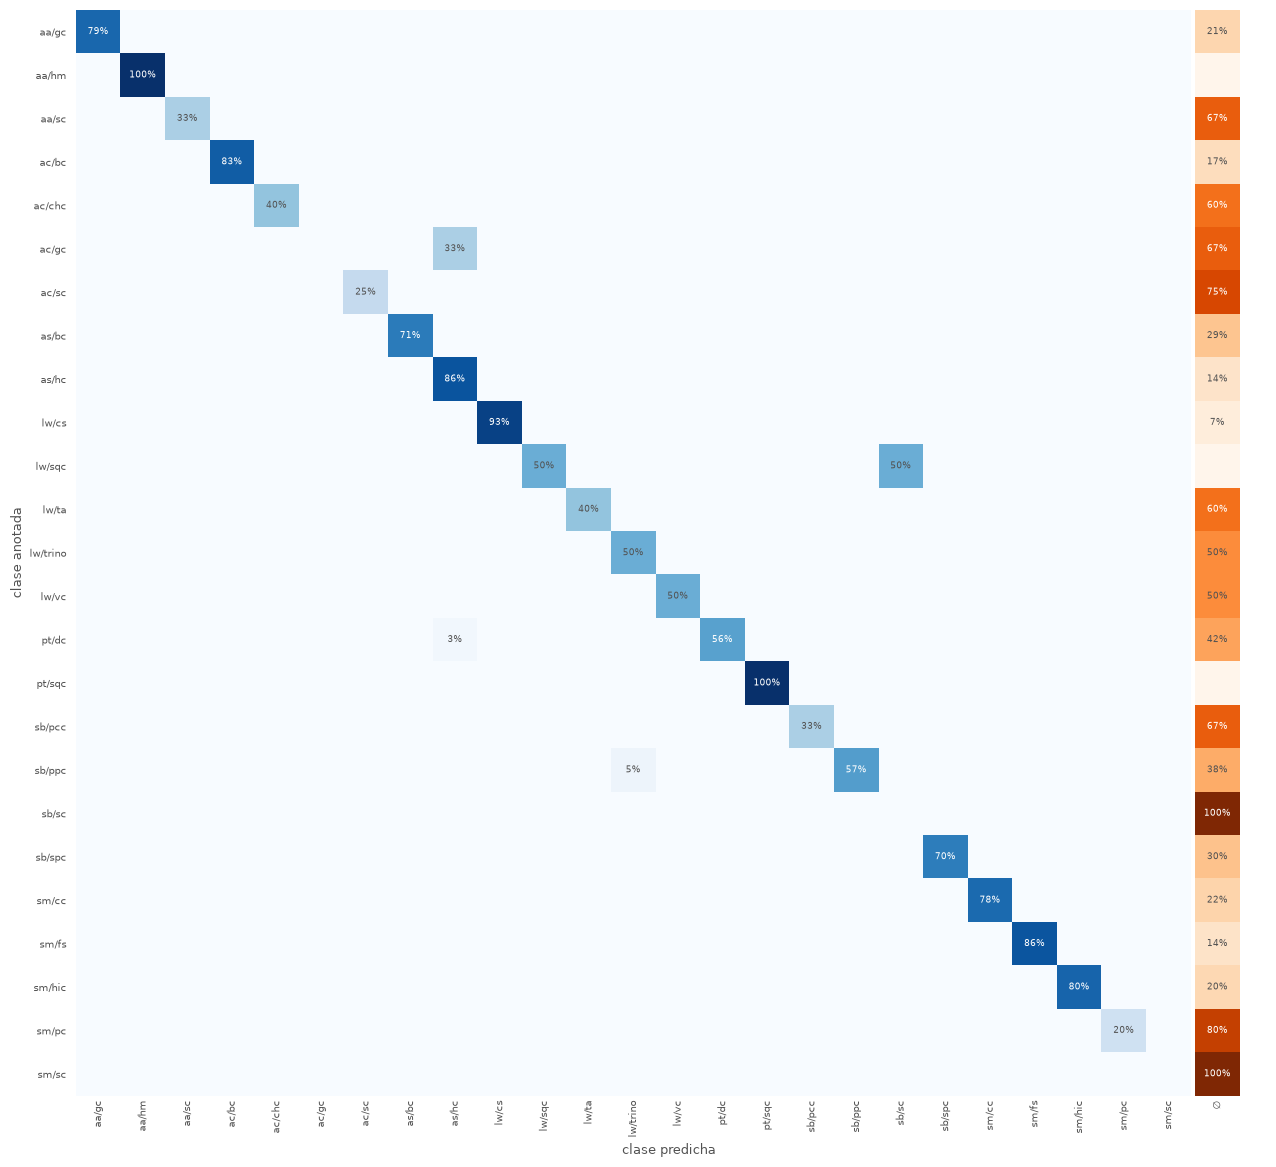

In [40]:
if RUN_MODEL:
    confusion = result["confusion"].numpy()
    totals = confusion.sum(axis=1, keepdims=True)
    normalized = np.divide(confusion, np.maximum(totals, 1))
    present = totals[:, 0] > 0
    names_present = [n for n, keep in zip(label_names, present) if keep]
    matrix = normalized[present]

    fig, ax = plt.subplots(
        figsize=(0.46 * (len(label_names) + 2) + 3.0, 0.46 * len(names_present) + 2.6)
    )
    ax.imshow(matrix[:, :-1], cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.imshow(
        matrix[:, -1:],
        cmap="Oranges",
        vmin=0,
        vmax=1,
        aspect="auto",
        extent=(
            len(label_names) + 0.1 - 0.5,
            len(label_names) + 1.1 - 0.5,
            len(names_present) - 0.5,
            -0.5,
        ),
    )
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            if value < 0.005:
                continue
            x = j if j < matrix.shape[1] - 1 else len(label_names) + 0.6 - 0.5
            ax.text(
                x,
                i,
                f"{value:.0%}",
                ha="center",
                va="center",
                fontsize=6.8,
                color=SURFACE if value > 0.55 else INK_2,
            )
    ax.set_xlim(-0.6, len(label_names) + 1.2)
    ax.set_xticks(
        list(range(len(label_names))) + [len(label_names) + 0.6 - 0.5],
        label_names + ["∅"],
        rotation=90,
        fontsize=7.5,
    )
    ax.set_yticks(range(len(names_present)), names_present, fontsize=7.5)
    ax.set_xlabel("clase predicha")
    ax.set_ylabel("clase anotada")
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    save(
        fig,
        "confusion_matrix",
        where="Cap. 5, sección 5.4 (Resultados) y 5.8 (Análisis de errores)",
        caption=(
            "Matriz de confusión sobre las \\textit{queries} que el emparejamiento "
            "húngaro asignó a una anotación, normalizada por fila. Mide la etiqueta, no "
            "la detección: la última columna recoge las \\textit{queries} emparejadas que "
            "aun así decidieron no-objeto."
        ),
    )
    plt.show()

### 7.5 `iou_distribution`

guardada -> research/figures/iou_distribution.png  (77 kB)


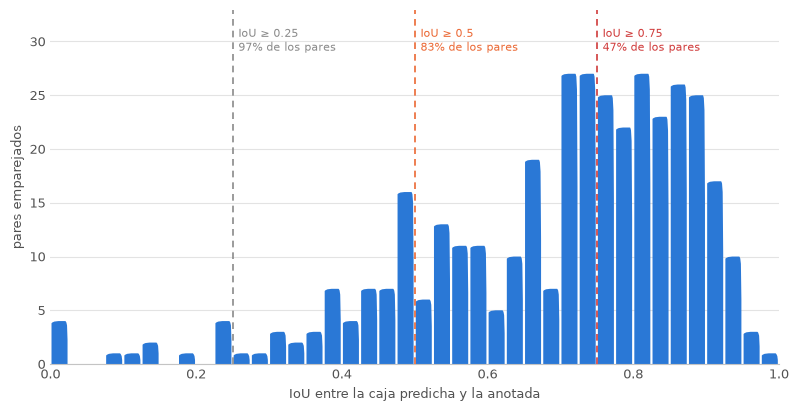

In [41]:
if RUN_MODEL:
    values = result["matched_iou"]
    fig, ax = plt.subplots(figsize=(9.4, 4.6))
    counts, edges = np.histogram(values, bins=np.linspace(0, 1, 41))
    centres = (edges[:-1] + edges[1:]) / 2
    ax.set_xlim(0, 1)
    ax.set_ylim(0, counts.max() * 1.22)
    barv(ax, centres, counts, BLUE, width=(edges[1] - edges[0]) * 0.88)
    for threshold, color in ((0.25, MUTED), (0.5, SERIES[1]), (0.75, CRITICAL)):
        share = float((values >= threshold).mean())
        ax.axvline(threshold, color=color, linewidth=1.2, linestyle=(0, (4, 3)), zorder=3)
        ax.text(
            threshold + 0.008,
            counts.max() * 1.16,
            f"IoU ≥ {threshold:g}\n{share:.0%} de los pares",
            color=color,
            fontsize=8,
            va="top",
        )
    ax.set_xlabel("IoU entre la caja predicha y la anotada")
    ax.set_ylabel("pares emparejados")
    style_value_axis(ax, "y")
    save(
        fig,
        "iou_distribution",
        where="Cap. 5, sección 5.4 - junto a la tabla de resultados por eje",
        width=r"0.9\textwidth",
        caption=(
            "Distribución del IoU sobre los pares que el emparejamiento húngaro "
            "seleccionó. La masa se concentra por encima de 0,5 y cae antes de 0,75: el "
            "cuello de botella del sistema es el encuadre, no la detección."
        ),
    )
    plt.show()

### 7.6 `qualitative_detections` (Figura 5.3)

Cuatro casos elegidos por criterio, incluido uno que sale mal.

guardada -> research/figures/qualitative_detections.png  (729 kB)


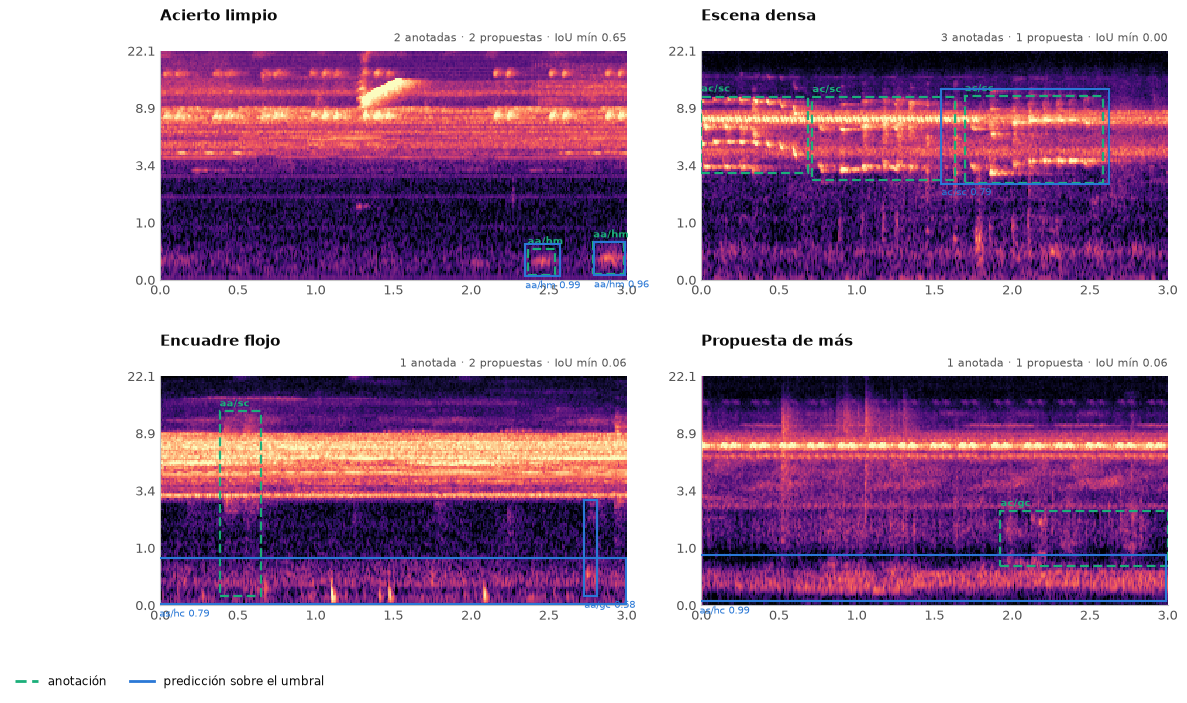

In [42]:
if RUN_MODEL:
    from torchvision.ops import box_iou  # noqa: E402

    def window_stats(window, threshold):
        keep = window["scores"] >= threshold
        predicted = window["boxes"][keep]
        truth_boxes = window["truth_boxes"]
        best = np.zeros(len(truth_boxes))
        best_class = np.zeros(len(truth_boxes), dtype=bool)
        if len(predicted) and len(truth_boxes):
            iou = box_iou(
                box_convert(torch.tensor(predicted), "cxcywh", "xyxy"),
                box_convert(torch.tensor(truth_boxes), "cxcywh", "xyxy"),
            ).numpy()
            best = iou.max(axis=0) if len(predicted) else best
            argmax = iou.argmax(axis=0)
            best_class = window["labels"][keep][argmax] == window["truth_labels"]
        unmatched = []
        if len(predicted):
            iou_pred = (
                box_iou(
                    box_convert(torch.tensor(predicted), "cxcywh", "xyxy"),
                    box_convert(torch.tensor(truth_boxes), "cxcywh", "xyxy"),
                )
                .numpy()
                .max(axis=1)
                if len(truth_boxes)
                else np.zeros(len(predicted))
            )
            unmatched = window["scores"][keep][iou_pred < 0.25]
        return {
            "n_truth": len(truth_boxes),
            "n_pred": int(keep.sum()),
            "best_iou": best,
            "class_ok": best_class,
            "top_false": float(unmatched.max()) if len(unmatched) else 0.0,
        }

    stats = [window_stats(w, operating) for w in result["windows"]]

    def choose(predicate, key, default_key=None):
        candidates = [(i, s) for i, s in enumerate(stats) if predicate(s)]
        if not candidates:
            return None
        return max(candidates, key=lambda pair: key(pair[1]))[0]

    picks = [
        (
            "Acierto limpio",
            choose(
                lambda s: (
                    s["n_truth"] >= 1
                    and len(s["best_iou"])
                    and s["best_iou"].min() >= 0.6
                    and s["class_ok"].all()
                ),
                lambda s: s["n_truth"],
            ),
        ),
        (
            "Escena densa",
            choose(
                lambda s: s["n_truth"] >= 3, lambda s: (s["n_truth"], (s["best_iou"] >= 0.5).sum())
            ),
        ),
        (
            "Encuadre flojo",
            choose(
                lambda s: (
                    s["n_truth"] >= 1 and len(s["best_iou"]) and 0.05 < s["best_iou"].min() < 0.5
                ),
                lambda s: -s["best_iou"].min(),
            ),
        ),
        (
            "Propuesta de más",
            choose(lambda s: s["top_false"] > 0.6, lambda s: s["top_false"]),
        ),
    ]
    picks = [(name, index) for name, index in picks if index is not None]

    fig, axes = plt.subplots(
        2, 2, figsize=(13.0, 7.2), gridspec_kw={"hspace": 0.42, "wspace": 0.16}
    )
    for ax, (name, index) in zip(axes.ravel(), picks):
        window = result["windows"][index]
        stat = stats[index]
        draw_spectrogram(ax, np.log(window["image"] + P.eps), P.clip_len_s)
        for box, label in zip(window["truth_boxes"], window["truth_labels"]):
            cx, cy, w, h = box
            ax.add_patch(
                Rectangle(
                    ((cx - w / 2) * P.clip_len_s, cy - h / 2),
                    w * P.clip_len_s,
                    h,
                    facecolor="none",
                    edgecolor=GOOD,
                    linewidth=1.6,
                    linestyle=(0, (4, 2)),
                    zorder=4,
                )
            )
            ax.text(
                (cx - w / 2) * P.clip_len_s,
                cy + h / 2 + 0.012,
                label_names[int(label)],
                color=GOOD,
                fontsize=7,
                fontweight="bold",
                va="bottom",
            )
        keep = window["scores"] >= operating
        for box, label, score in zip(
            window["boxes"][keep], window["labels"][keep], window["scores"][keep]
        ):
            cx, cy, w, h = box
            ax.add_patch(
                Rectangle(
                    ((cx - w / 2) * P.clip_len_s, cy - h / 2),
                    w * P.clip_len_s,
                    h,
                    facecolor="none",
                    edgecolor=BLUE,
                    linewidth=1.5,
                    zorder=5,
                )
            )
            ax.text(
                (cx - w / 2) * P.clip_len_s,
                cy - h / 2 - 0.018,
                f"{label_names[int(label)]} {score:.2f}",
                color=BLUE,
                fontsize=7,
                va="top",
            )
        detail = (
            f"{stat['n_truth']} anotada{'s' if stat['n_truth'] != 1 else ''} · "
            f"{stat['n_pred']} propuesta{'s' if stat['n_pred'] != 1 else ''}"
            + (f" · IoU mín {stat['best_iou'].min():.2f}" if len(stat["best_iou"]) else "")
        )
        ax.set_title(name, fontsize=10.5, pad=22)
        ax.annotate(
            detail,
            xy=(1, 1),
            xytext=(0, 5),
            xycoords="axes fraction",
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=8,
            color=INK_2,
        )
        ax.set_xlabel("")
        ax.set_ylabel("")

    handles = [
        plt.Line2D([], [], color=GOOD, linewidth=2, linestyle=(0, (4, 2)), label="anotación"),
        plt.Line2D([], [], color=BLUE, linewidth=2, label="predicción sobre el umbral"),
    ]
    fig.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.005, -0.02), ncol=2)
    save(
        fig,
        "qualitative_detections",
        where="Cap. 5, sección 5.4 (Figura 5.3)",
        caption=(
            "Cuatro ventanas de la partición de prueba con la anotación y la predicción "
            "superpuestas. Los casos se eligen por criterio e incluyen deliberadamente un "
            "encuadre flojo y una propuesta de alta confianza sin anotación detrás, que "
            "es la categoría que el análisis de errores tiene que resolver."
        ),
    )
    plt.show()

### 7.7 `training_curves`

Lee el `metrics.jsonl` de `logs/<fecha>/`.

In [43]:
runs = sorted(LOG_DIR.glob("*/metrics.jsonl"))
if not runs:
    print(f"sin corridas en {LOG_DIR}: la figura de curvas no se genera")
    print(
        "copiá el metrics.jsonl de la máquina de entrenamiento a logs/<fecha>/ y volvé a correr esta celda"
    )
else:
    run_path = runs[-1]
    records = [json.loads(line) for line in run_path.read_text().splitlines() if line.strip()]
    history = pd.DataFrame(
        {
            "epoch": [r["epoch"] for r in records],
            "train": [r["train"]["total"] for r in records],
            "val": [r["val"]["losses"]["total"] for r in records],
            "recall": [r["val"]["recall_agnostic"] for r in records],
            "precision": [r["val"]["precision_agnostic"] for r in records],
            "score": [r["val"]["operating_score"] for r in records],
            "iou": [r["val"]["mean_iou"] for r in records],
        }
    )
    best = int(history.score.idxmax())
    print(
        f"{run_path.parent.name}: {len(history)} épocas · mejor score en la época {history.epoch[best]}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6), gridspec_kw={"wspace": 0.24})
    ax = axes[0]
    for column, color, name in (("train", BLUE, "entrenamiento"), ("val", SERIES[1], "validación")):
        ax.plot(history.epoch, history[column], color=color, linewidth=2)
        ax.text(
            history.epoch.iloc[-1] + 0.4,
            history[column].iloc[-1],
            name,
            color=color,
            fontsize=8.5,
            va="center",
            fontweight="bold",
        )
    ax.set_xlabel("época")
    ax.set_ylabel("pérdida total")
    style_value_axis(ax, "y")

    ax = axes[1]
    for column, color, name in (
        ("recall", BLUE, "recall"),
        ("precision", SERIES[1], "precisión"),
        ("iou", SERIES[2], "IoU medio"),
    ):
        ax.plot(history.epoch, history[column], color=color, linewidth=2)
        ax.text(
            history.epoch.iloc[-1] + 0.4,
            history[column].iloc[-1],
            name,
            color=color,
            fontsize=8.5,
            va="center",
            fontweight="bold",
        )
    ax.axvline(history.epoch[best], color=MUTED, linewidth=1.1, linestyle=(0, (4, 3)))
    ax.annotate(
        f"checkpoint elegido\n(época {history.epoch[best]}, F-β = {history.score[best]:.3f})",
        xy=(history.epoch[best], history.recall[best]),
        xytext=(history.epoch[best] * 0.55, 0.25),
        color=INK_2,
        fontsize=8,
        arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.9),
    )
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("época")
    ax.set_ylabel("proporción")
    style_value_axis(ax, "y")

    save(
        fig,
        "training_curves",
        where="Cap. 5, sección 5.2 (Pipeline de entrenamiento)",
        caption=(
            "Curvas de la corrida que produjo el \\textit{checkpoint} reportado. La línea "
            "vertical marca la época seleccionada por la F-$\\beta$ de validación; no es "
            "la de menor pérdida, porque el criterio de selección pondera el "
            "\\textit{recall}."
        ),
    )
    plt.show()

sin corridas en /home/nhrot/Prog/tesis-primate/logs: la figura de curvas no se genera
copiá el metrics.jsonl de la máquina de entrenamiento a logs/<fecha>/ y volvé a correr esta celda


### 7.8 `ablation_progression`

**Editá `ABLATION`**: hoy son las cifras del reporte de avance (10 clases).

guardada -> research/figures/ablation_progression.png  (88 kB)


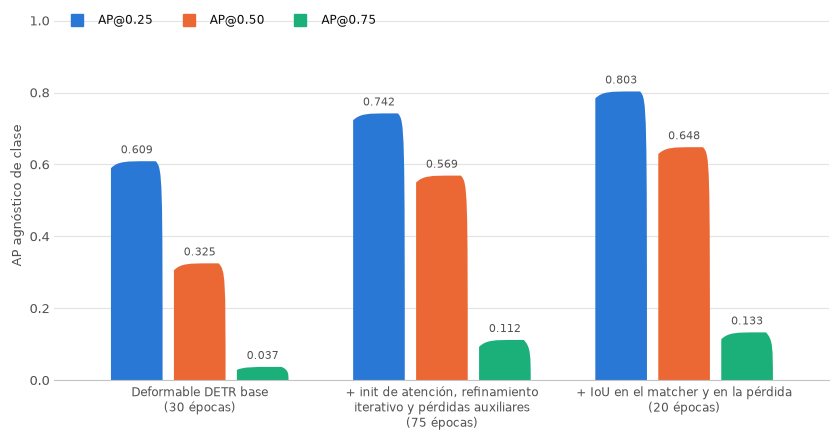

In [44]:
ABLATION = {
    "Deformable DETR base": {"AP@0.25": 0.609, "AP@0.50": 0.325, "AP@0.75": 0.037, "épocas": 30},
    "+ init de atención, refinamiento\niterativo y pérdidas auxiliares": {
        "AP@0.25": 0.742,
        "AP@0.50": 0.569,
        "AP@0.75": 0.112,
        "épocas": 75,
    },
    "+ IoU en el matcher y en la pérdida": {
        "AP@0.25": 0.803,
        "AP@0.50": 0.648,
        "AP@0.75": 0.133,
        "épocas": 20,
    },
}
ABLATION_SOURCE = "reporte de avance, subconjunto de 10 clases"

table = pd.DataFrame(ABLATION).T
metrics = ["AP@0.25", "AP@0.50", "AP@0.75"]
fig, ax = plt.subplots(figsize=(10.0, 4.8))
xs = np.arange(len(table))
step = 0.26
ax.set_ylim(0, table[metrics].values.max() * 1.28)
ax.set_xlim(-0.6, len(table) - 0.4)
for i, (metric, color) in enumerate(zip(metrics, SERIES)):
    barv(ax, xs + (i - 1) * step, table[metric].values, color, width=step * 0.82)
    for x, value in zip(xs + (i - 1) * step, table[metric].values):
        ax.text(
            x, value + 0.015, f"{value:.3f}", ha="center", va="bottom", fontsize=7.6, color=INK_2
        )
ax.set_xticks(
    xs, [f"{name}\n({int(row['épocas'])} épocas)" for name, row in table.iterrows()], fontsize=8.5
)
ax.set_ylabel("AP agnóstico de clase")
style_value_axis(ax, "y")
handles = [
    plt.Line2D([], [], marker="s", linestyle="", markersize=8, color=c, label=m)
    for c, m in zip(SERIES, metrics)
]
ax.legend(handles=handles, loc="upper left", ncol=3, bbox_to_anchor=(0, 1.02))
save(
    fig,
    "ablation_progression",
    where="Cap. 5, sección 5.4 - junto a la tabla de ablación",
    width=r"0.92\textwidth",
    caption=(
        "Efecto acumulado de las tres decisiones de diseño sobre la precisión media "
        "agnóstica a la clase. Cada configuración incluye a la anterior; la última "
        "mejora los tres umbrales y además reduce el entrenamiento a una cuarta parte de "
        "las épocas."
    ),
)
plt.show()

### 7.9 `detection_timeline` (Figura 5.4) y la tabla de selección

Inferencia completa sobre una grabación de prueba con el `predict` de `src/infer.py`.
La tabla de selección se emite como `tabular`, no como figura; la captura de Raven
abriendo el `.txt` hay que tomarla a mano.

In [45]:
if RUN_MODEL and splits:
    from pipelines.inference_pipeline import predict  # noqa: E402

    durations = recordings.set_index("audio_path").duration_s
    test_files = {w.audio_path for w in splits["test"]}
    counts = experiment[experiment.audio_path.isin(test_files)].audio_path.value_counts()
    candidates = [
        (path, n) for path, n in counts.items() if 4 <= n <= 14 and durations.get(path, 1e9) <= 90
    ]
    if not candidates:
        candidates = [(counts.index[0], counts.iloc[0])]
    recording_path, n_annotations = min(candidates, key=lambda pair: abs(pair[1] - 8))
    recording_duration = float(durations.get(recording_path, 30.0))
    print(f"{Path(recording_path).name} · {recording_duration:.0f} s · {n_annotations} anotaciones")

    table = predict(
        loaded.model,
        recording_path,
        loaded.labels,
        DEVICE,
        score_threshold=loaded.score_threshold,
        nms_iou=loaded.nms_iou,
        batch_size=8,
    )
    print(f"{len(table)} detecciones sobre la grabación completa")
    display(table.head(8))

20240219_103940.wav · 52 s · 8 anotaciones
36 detecciones sobre la grabación completa


,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Species,Call type,Score
0,1,Spectrogram 1,1,0.252,0.604,849.926,"2,461.865",AC,BC,0.983
1,2,Spectrogram 1,1,1.591,2.274,294.329,"4,719.555",AC,BC,0.518
2,3,Spectrogram 1,1,6.479,6.760,177.111,"18,123.289",SB,SPC,0.948
3,4,Spectrogram 1,1,6.914,7.071,"6,213.685","9,734.530",SB,PPC,0.556
4,5,Spectrogram 1,1,7.797,7.883,"6,329.804","11,010.316",SB,PPC,0.966
5,6,Spectrogram 1,1,7.798,8.017,101.408,"17,137.168",SB,SPC,0.583
6,7,Spectrogram 1,1,8.455,8.600,38.248,"17,021.201",SB,SPC,0.673
7,8,Spectrogram 1,1,8.763,9.007,602.570,"20,983.545",SB,SPC,0.612


guardada -> research/figures/detection_timeline.png  (649 kB)


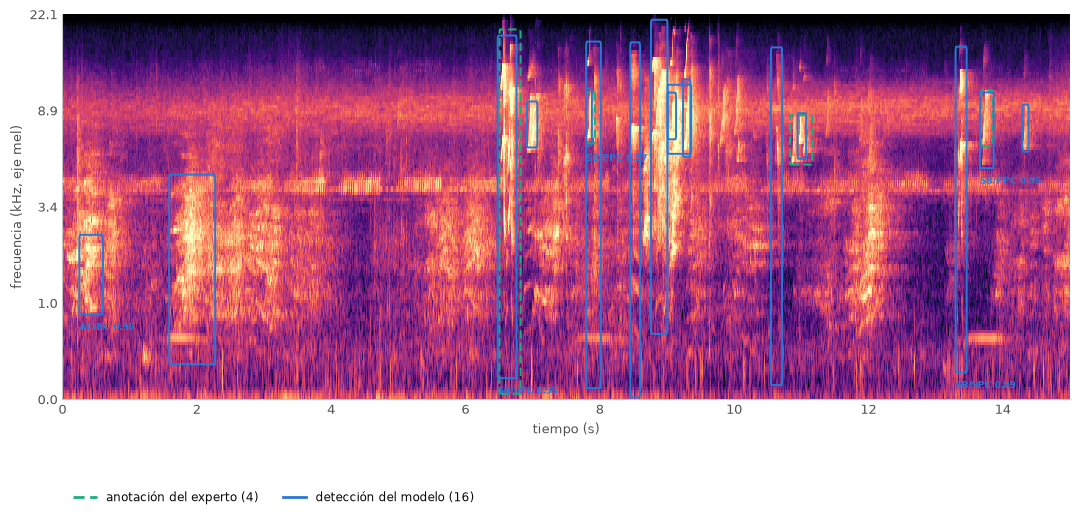

In [46]:
if RUN_MODEL and splits:
    span = min(recording_duration, 15.0)
    waveform = load_segment(recording_path, 0.0, span)
    truth_rows = experiment[
        (experiment.audio_path == recording_path) & (experiment.begin_time_s < span)
    ]

    fig, ax = plt.subplots(figsize=(13.0, 5.0))
    draw_spectrogram(ax, log_mel(waveform), span)
    for r in truth_rows.itertuples():
        draw_box(
            ax,
            r.begin_time_s,
            min(r.end_time_s, span),
            r.low_freq_hz,
            r.high_freq_hz,
            color=GOOD,
            lw=1.5,
            dashed=True,
        )
    shown = table[table["Begin Time (s)"] < span]
    labelled = set(shown.nlargest(min(5, len(shown)), "Score").index)
    for index, r in shown.iterrows():
        draw_box(
            ax,
            r["Begin Time (s)"],
            min(r["End Time (s)"], span),
            r["Low Freq (Hz)"],
            r["High Freq (Hz)"],
            color=BLUE,
            lw=1.4,
            label=(
                f"{r['Species']}/{r['Call type']} {r['Score']:.2f}" if index in labelled else None
            ),
            fs=6.5,
            label_below=True,
        )
    handles = [
        plt.Line2D(
            [],
            [],
            color=GOOD,
            linewidth=2,
            linestyle=(0, (4, 2)),
            label=f"anotación del experto ({len(truth_rows)})",
        ),
        plt.Line2D([], [], color=BLUE, linewidth=2, label=f"detección del modelo ({len(shown)})"),
    ]
    ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0, -0.30), ncol=2)
    save(
        fig,
        "detection_timeline",
        where="Cap. 5, sección 5.5 (Exportación a Raven)",
        caption=(
            "Salida del modelo sobre una grabación completa que no participó del "
            "entrenamiento, con la anotación del experto superpuesta. Es la forma en que "
            "el analista ve la pre-anotación antes de aceptarla o corregirla."
        ),
    )
    plt.show()

In [47]:
if RUN_MODEL and splits:
    preview = table.head(10)

    def cell_text(value):
        return f"{value:.3f}" if isinstance(value, float) else str(value)

    print(
        tabular(
            list(preview.columns),
            [[cell_text(v) for v in row] for row in preview.itertuples(index=False)],
            "l" * len(preview.columns),
            f"Primeras {len(preview)} de {len(table)} detecciones de "
            f"\\texttt{{{Path(recording_path).name}}}: las columnas exactas que Raven "
            "espera más la de confianza, que ordena la revisión.",
            "tab:raven-preview",
        )
    )

\begin{table}[htbp]
    \centering
    \caption{Primeras 10 de 36 detecciones de \texttt{20240219_103940.wav}: las columnas exactas que Raven espera más la de confianza, que ordena la revisión.}
    \label{tab:raven-preview}
    \begin{tabular}{llllllllll}
    \toprule
    Selection & View & Channel & Begin Time (s) & End Time (s) & Low Freq (Hz) & High Freq (Hz) & Species & Call type & Score \\
    \midrule
    1 & Spectrogram 1 & 1 & 0.252 & 0.604 & 849.926 & 2461.865 & AC & BC & 0.983 \\
    2 & Spectrogram 1 & 1 & 1.591 & 2.274 & 294.329 & 4719.555 & AC & BC & 0.518 \\
    3 & Spectrogram 1 & 1 & 6.479 & 6.760 & 177.111 & 18123.289 & SB & SPC & 0.948 \\
    4 & Spectrogram 1 & 1 & 6.914 & 7.071 & 6213.685 & 9734.530 & SB & PPC & 0.556 \\
    5 & Spectrogram 1 & 1 & 7.797 & 7.883 & 6329.804 & 11010.316 & SB & PPC & 0.966 \\
    6 & Spectrogram 1 & 1 & 7.798 & 8.017 & 101.408 & 17137.168 & SB & SPC & 0.583 \\
    7 & Spectrogram 1 & 1 & 8.455 & 8.600 & 38.248 & 17021.201 & SB & SPC &

## 8. OE3 y anexo — plantillas

Todavía sin datos reales: estructura correcta y valores de ejemplo. Cada celda avisa.

### 8.1 `review_time` (RE3.1, RE3.2)

AVISO: `review_time` sale con valores de ejemplo. Reemplazá REVIEW_TIME y poné REVIEW_TIME_IS_REAL = True.
guardada -> research/figures/review_time.png  (48 kB)


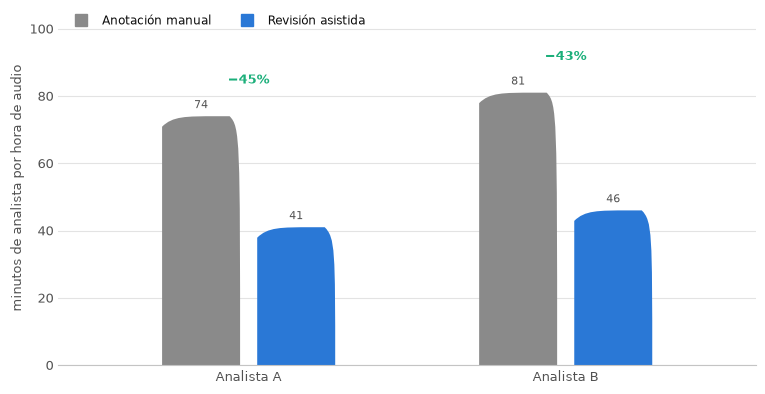

In [48]:
REVIEW_TIME = {  # minutos de analista por hora de audio  <- REEMPLAZAR CON LA MEDICIÓN
    "Anotación manual": {"Analista A": 74.0, "Analista B": 81.0},
    "Revisión asistida": {"Analista A": 41.0, "Analista B": 46.0},
}
REVIEW_TIME_IS_REAL = False

conditions = list(REVIEW_TIME)
analysts = list(REVIEW_TIME[conditions[0]])
fig, ax = plt.subplots(figsize=(9.0, 4.6))
xs = np.arange(len(analysts))
step = 0.30
peak = max(v for c in conditions for v in REVIEW_TIME[c].values())
ax.set_ylim(0, peak * 1.30)
ax.set_xlim(-0.6, len(analysts) - 0.4)
for i, (condition, color) in enumerate(zip(conditions, (MUTED, BLUE))):
    values = [REVIEW_TIME[condition][a] for a in analysts]
    barv(ax, xs + (i - 0.5) * step, values, color, width=step * 0.82)
    for x, value in zip(xs + (i - 0.5) * step, values):
        ax.text(
            x,
            value + peak * 0.02,
            f"{value:.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=INK_2,
        )
for x, analyst in zip(xs, analysts):
    manual = REVIEW_TIME[conditions[0]][analyst]
    assisted = REVIEW_TIME[conditions[1]][analyst]
    ax.annotate(
        f"−{(manual - assisted) / manual:.0%}",
        xy=(x, max(manual, assisted) + peak * 0.12),
        ha="center",
        fontsize=9.5,
        color=GOOD,
        fontweight="bold",
    )
ax.set_xticks(xs, analysts)
ax.set_ylabel("minutos de analista por hora de audio")
style_value_axis(ax, "y")
handles = [
    plt.Line2D([], [], marker="s", linestyle="", markersize=8, color=c, label=n)
    for c, n in zip((MUTED, BLUE), conditions)
]
ax.legend(handles=handles, loc="upper left", ncol=2, bbox_to_anchor=(0, 1.02))
if not REVIEW_TIME_IS_REAL:
    print(
        "AVISO: `review_time` sale con valores de ejemplo. Reemplazá REVIEW_TIME y poné REVIEW_TIME_IS_REAL = True."
    )
save(
    fig,
    "review_time",
    where="Cap. 5, sección 5.7 (Tiempo de revisión)",
    width=r"0.85\textwidth",
    caption=(
        "Minutos de analista por hora de audio, anotación manual frente a revisión "
        "asistida sobre el mismo material. El diseño de la prueba controla el efecto de "
        "aprendizaje alternando el orden de las condiciones entre analistas."
    ),
)
plt.show()

### 8.2 `false_positive_analysis` (RE3.3)

AVISO: `false_positive_analysis` sale con valores de ejemplo. Reemplazá FALSE_POSITIVES.
guardada -> research/figures/false_positive_analysis.png  (28 kB)


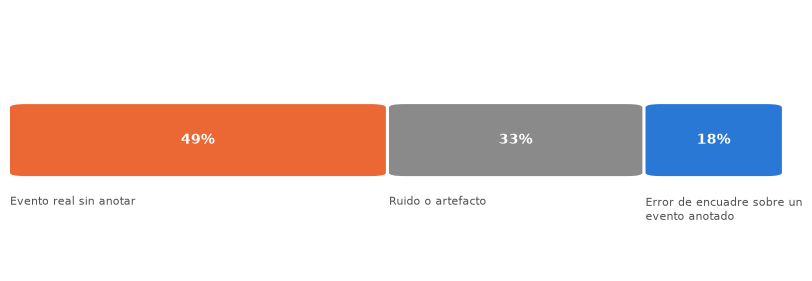

In [49]:
FALSE_POSITIVES = {  # muestra de FP de alta confianza revisada por el experto <- REEMPLAZAR
    "Evento real sin anotar": 0.489,
    "Ruido o artefacto": 0.331,
    "Error de encuadre sobre un evento anotado": 0.180,
}
FALSE_POSITIVES_N = 90
FALSE_POSITIVES_IS_REAL = False

fig, ax = plt.subplots(figsize=(10.0, 3.4))
ax.set_xlim(0, 1)
ax.set_ylim(-0.8, 0.8)
left = 0.0
gap = 0.004
for (name, share), color in zip(FALSE_POSITIVES.items(), (SERIES[1], MUTED, BLUE)):
    ax.add_patch(
        FancyBboxPatch(
            (left, -0.22),
            share - gap,
            0.44,
            boxstyle="round,pad=0,rounding_size=0.02",
            facecolor=color,
            edgecolor="none",
        )
    )
    ax.text(
        left + (share - gap) / 2,
        0,
        f"{share:.0%}",
        ha="center",
        va="center",
        fontsize=10,
        color=SURFACE,
        fontweight="bold",
    )
    ax.text(left, -0.34, wrap_text(name, 26), ha="left", va="top", fontsize=8.2, color=INK_2)
    left += share
ax.axis("off")
if not FALSE_POSITIVES_IS_REAL:
    print(
        "AVISO: `false_positive_analysis` sale con valores de ejemplo. Reemplazá FALSE_POSITIVES."
    )
save(
    fig,
    "false_positive_analysis",
    where="Cap. 5, sección 5.8 (Análisis de errores)",
    width=r"0.9\textwidth",
    caption=(
        f"Reparto de una muestra de {FALSE_POSITIVES_N} falsos positivos de alta "
        "confianza entre las tres "
        "categorías del protocolo. La primera categoría es la que cambia la "
        "interpretación de toda cifra de precisión: son eventos que el modelo encontró y "
        "la referencia no registra."
    ),
)
plt.show()

### 8.3 `wbs_tree`

guardada -> research/figures/wbs_tree.png  (170 kB)


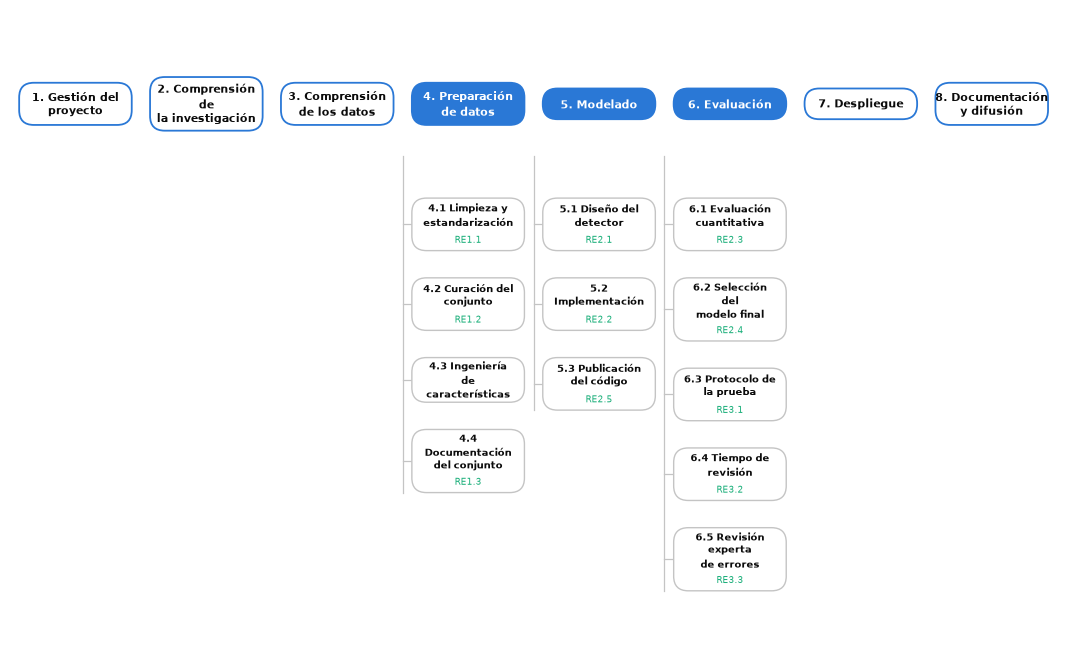

In [50]:
WBS = [
    ("1", "Gestión del\nproyecto", []),
    ("2", "Comprensión de\nla investigación", []),
    ("3", "Comprensión\nde los datos", []),
    (
        "4",
        "Preparación\nde datos",
        [
            ("4.1", "Limpieza y\nestandarización", "RE1.1"),
            ("4.2", "Curación del\nconjunto", "RE1.2"),
            ("4.3", "Ingeniería de\ncaracterísticas", ""),
            ("4.4", "Documentación\ndel conjunto", "RE1.3"),
        ],
    ),
    (
        "5",
        "Modelado",
        [
            ("5.1", "Diseño del\ndetector", "RE2.1"),
            ("5.2", "Implementación", "RE2.2"),
            ("5.3", "Publicación\ndel código", "RE2.5"),
        ],
    ),
    (
        "6",
        "Evaluación",
        [
            ("6.1", "Evaluación\ncuantitativa", "RE2.3"),
            ("6.2", "Selección del\nmodelo final", "RE2.4"),
            ("6.3", "Protocolo de\nla prueba", "RE3.1"),
            ("6.4", "Tiempo de\nrevisión", "RE3.2"),
            ("6.5", "Revisión experta\nde errores", "RE3.3"),
        ],
    ),
    ("7", "Despliegue", []),
    ("8", "Documentación\ny difusión", []),
]

fig, ax = canvas(13.6, 8.2)
TOP = 100 * 8.2 / 13.6
column = 100 / len(WBS)
parent_y = TOP - 9
for i, (code, name, children) in enumerate(WBS):
    cx = column * (i + 0.5)
    has_children = bool(children)
    node(
        ax,
        cx,
        parent_y,
        column * 0.86,
        None,
        f"{code}. {name}",
        wrap=16,
        fill=BLUE if has_children else SURFACE,
        edge=BLUE,
        ink=SURFACE if has_children else INK,
        lw=1.3,
        fs=8.0,
    )
    spine_x = cx - column * 0.50
    top_y = parent_y - 5
    child_y = parent_y - 9
    for child_code, child_name, deliverable in children:
        height = node_height(
            ax,
            f"{child_code} {child_name}",
            None,
            deliverable or None,
            fs=7.4,
            foot_fs=6.8,
            wrap=16,
            pad_pt=6.0,
        )
        centre = child_y - height / 2
        node(
            ax,
            cx,
            centre,
            column * 0.86,
            height,
            f"{child_code} {child_name}",
            None,
            deliverable or None,
            wrap=16,
            fill=SURFACE,
            edge=BASELINE,
            lw=1.0,
            fs=7.4,
            foot_fs=6.8,
            foot_ink=SERIES[2],
            pad_pt=6.0,
        )
        ax.plot(
            [spine_x, cx - column * 0.43], [centre, centre], color=BASELINE, linewidth=0.9, zorder=0
        )
        child_y -= height + 2.6
    if children:
        ax.plot([spine_x, spine_x], [top_y, child_y + 2.6], color=BASELINE, linewidth=0.9, zorder=0)

save(
    fig,
    "wbs_tree",
    where="Anexo A, sección A.3.1 - junto a la Tabla A.5",
    caption=(
        "Estructura de desglose del trabajo. Los paquetes de nivel superior siguen las "
        "fases de CRISP-DM; los de segundo nivel llevan el resultado esperado que "
        "entregan."
    ),
)
plt.show()

### 8.4 `gantt`

**Plantilla**: semanas relativas. Reemplazá `SCHEDULE` con las fechas reales.

AVISO: `gantt` sale con semanas relativas de ejemplo. Reemplazá SCHEDULE con las fechas reales.
guardada -> research/figures/gantt.png  (156 kB)


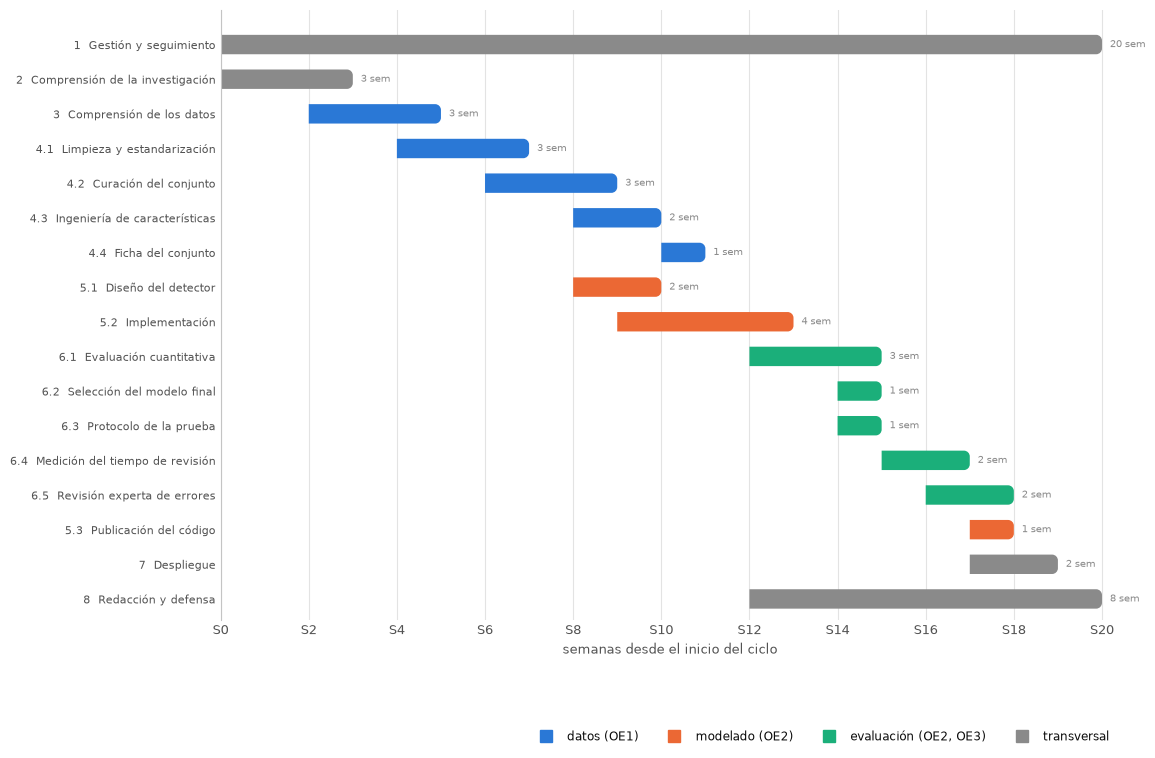

In [51]:
SCHEDULE = [  # (paquete, tarea, semana de inicio, duración en semanas)
    ("1", "Gestión y seguimiento", 0, 20),
    ("2", "Comprensión de la investigación", 0, 3),
    ("3", "Comprensión de los datos", 2, 3),
    ("4.1", "Limpieza y estandarización", 4, 3),
    ("4.2", "Curación del conjunto", 6, 3),
    ("4.3", "Ingeniería de características", 8, 2),
    ("4.4", "Ficha del conjunto", 10, 1),
    ("5.1", "Diseño del detector", 8, 2),
    ("5.2", "Implementación", 9, 4),
    ("6.1", "Evaluación cuantitativa", 12, 3),
    ("6.2", "Selección del modelo final", 14, 1),
    ("6.3", "Protocolo de la prueba", 14, 1),
    ("6.4", "Medición del tiempo de revisión", 15, 2),
    ("6.5", "Revisión experta de errores", 16, 2),
    ("5.3", "Publicación del código", 17, 1),
    ("7", "Despliegue", 17, 2),
    ("8", "Redacción y defensa", 12, 8),
]
SCHEDULE_IS_REAL = False

GROUP_COLOR = {
    "1": MUTED,
    "2": MUTED,
    "3": BLUE,
    "4": BLUE,
    "5": SERIES[1],
    "6": SERIES[2],
    "7": MUTED,
    "8": MUTED,
}
weeks = max(start + length for _, _, start, length in SCHEDULE)

fig, ax = plt.subplots(figsize=(11.6, 0.36 * len(SCHEDULE) + 1.8))
ys = np.arange(len(SCHEDULE))
ax.set_xlim(0, weeks + 0.4)
ax.set_ylim(len(SCHEDULE) - 0.4, -1.0)
for y, (package, task, start, length) in zip(ys, SCHEDULE):
    color = GROUP_COLOR[package.split(".")[0]]
    barh(ax, [y], [length], color, height=0.56, left=[start])
    ax.text(start + length + 0.18, y, f"{length} sem", va="center", fontsize=7, color=MUTED)
ax.set_yticks(ys, [f"{package}  {task}" for package, task, _, _ in SCHEDULE], fontsize=8)
ax.set_xticks(range(0, weeks + 1, 2), [f"S{w}" for w in range(0, weeks + 1, 2)])
style_value_axis(ax, "x")
ax.set_xlabel("semanas desde el inicio del ciclo")
handles = [
    plt.Line2D([], [], marker="s", linestyle="", markersize=8, color=color, label=name)
    for color, name in (
        (BLUE, "datos (OE1)"),
        (SERIES[1], "modelado (OE2)"),
        (SERIES[2], "evaluación (OE2, OE3)"),
        (MUTED, "transversal"),
    )
]
ax.legend(handles=handles, loc="lower right", ncol=4, bbox_to_anchor=(1.0, -0.22))
if not SCHEDULE_IS_REAL:
    print(
        "AVISO: `gantt` sale con semanas relativas de ejemplo. Reemplazá SCHEDULE con las fechas reales."
    )
save(
    fig,
    "gantt",
    where="Anexo A, sección A.3.2 (Cronograma) - donde está el TODO CRONOGRAMA",
    caption=(
        "Cronograma por paquete de trabajo. Las dependencias se respetan por "
        "construcción: la preparación de datos precede al modelado, el modelado a la "
        "evaluación, y la medición del tiempo de revisión al análisis de errores."
    ),
)
plt.show()

### 8.5 `risk_matrix`

guardada -> research/figures/risk_matrix.png  (55 kB)


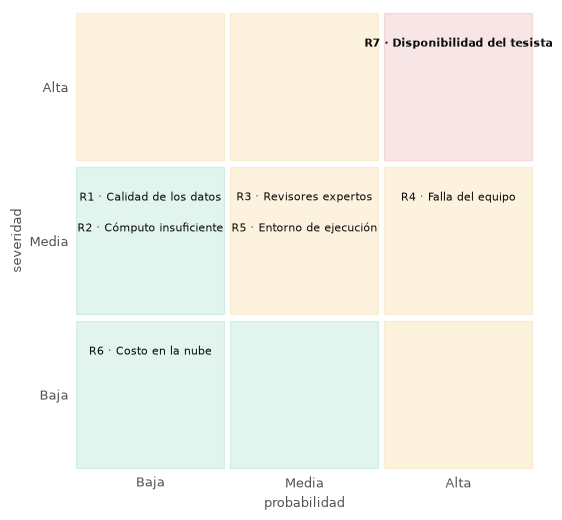

In [52]:
RISKS = [
    ("R1", "Calidad de los datos", "Baja", "Media"),
    ("R2", "Cómputo insuficiente", "Baja", "Media"),
    ("R3", "Revisores expertos", "Media", "Media"),
    ("R4", "Falla del equipo", "Alta", "Media"),
    ("R5", "Entorno de ejecución", "Media", "Media"),
    ("R6", "Costo en la nube", "Baja", "Baja"),
    ("R7", "Disponibilidad del tesista", "Alta", "Alta"),
]
LEVELS_ORDER = ["Baja", "Media", "Alta"]
ZONE = {
    (0, 0): GOOD,
    (1, 0): GOOD,
    (2, 0): WARNING,
    (0, 1): GOOD,
    (1, 1): WARNING,
    (2, 1): WARNING,
    (0, 2): WARNING,
    (1, 2): WARNING,
    (2, 2): CRITICAL,
}

fig, ax = plt.subplots(figsize=(8.6, 6.0))
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 2.5)
ax.set_aspect("equal")
for i in range(3):
    for j in range(3):
        ax.add_patch(
            Rectangle(
                (i - 0.48, j - 0.48),
                0.96,
                0.96,
                facecolor=ZONE[(i, j)],
                alpha=0.13,
                edgecolor=ZONE[(i, j)],
                linewidth=1.0,
            )
        )
for code, name, probability, severity in RISKS:
    i, j = LEVELS_ORDER.index(probability), LEVELS_ORDER.index(severity)
    same = [r for r in RISKS if LEVELS_ORDER.index(r[2]) == i and LEVELS_ORDER.index(r[3]) == j]
    offset = same.index((code, name, probability, severity))
    ax.text(
        i,
        j + 0.28 - offset * 0.20,
        f"{code} · {name}",
        ha="center",
        va="center",
        fontsize=8,
        color=INK,
        fontweight="bold" if ZONE[(i, j)] == CRITICAL else "normal",
    )
ax.set_xticks(range(3), LEVELS_ORDER)
ax.set_yticks(range(3), LEVELS_ORDER)
ax.set_xlabel("probabilidad")
ax.set_ylabel("severidad")
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)
save(
    fig,
    "risk_matrix",
    where="Anexo A, sección A.3.5 - junto a la Tabla A.9",
    width=r"0.75\textwidth",
    caption=(
        "Riesgos del proyecto sobre el plano de probabilidad y severidad. La celda de "
        "probabilidad y severidad altas la ocupa un solo riesgo, la disponibilidad del "
        "tesista, que es el que gobierna la holgura del cronograma."
    ),
)
plt.show()

## 9. Índice de lo generado

También escribe `research/figures/GENERATED.md`.

In [53]:
index = pd.DataFrame(FIGURES)[["name", "kb", "where"]]
index.columns = ["figura", "kB", "destino sugerido"]
display(index.style.hide(axis="index").format({"kB": "{:.0f}"}))

figura,kB,destino sugerido
annotation_example,147,"Cap. 1, sección 1.1 (Figura 1.1) - antes de la Tabla 1.1"
output_forms,339,"Cap. 1, sección 1.1.3 (Figura 1.2) - cierre de 'Investigaciones anteriores'"
problem_tree,223,"Cap. 1, sección 1.2 (Figura 1.3) - tras el párrafo que cita a Veselý"
crisp_dm,137,"Cap. 1, sección 1.6.1 - junto a la Tabla 1.6"
recorded_vs_annotated,139,"Cap. 1, sección 1.1.1 (evidencia local) y Cap. 4, sección 4.1.3"
signal_chain,98,"Cap. 2, apertura del Marco Conceptual (sección 2.2)"
stft_tradeoff,266,"Cap. 2, sección 2.1.2 - o junto a la tabla de preprocesamiento del Cap. 4"
mel_axis,140,"Cap. 2, sección 2.2.3 (De la señal a la representación)"
pcen_vs_logmel,351,"Cap. 2, sección 2.2.3 - donde se declara el criterio de comparación"
box_coordinates,214,"Cap. 4, sección 4.3.4 (Representación y normalización de las cajas)"


In [54]:
def latex_block(entry):
    return "\n".join(
        [
            r"\begin{figure}[htbp]",
            r"    \centering",
            f"    \\includegraphics[width={entry['width']}]{{figures/{entry['name']}.png}}",
            "    \\caption{" + entry["caption"] + "}",
            f"    \\label{{{entry['label']}}}",
            r"\end{figure}",
        ]
    )


lines = [
    "# Figuras generadas",
    "",
    "Producidas por `notebooks/thesis_figures.ipynb` (diagramas, figuras de datos y de",
    "resultados) y por `notebooks/dataset_report.ipynb` (figuras del conjunto).",
    "No edites los PNG a mano: se regeneran corriendo el cuaderno.",
    "",
]
for entry in FIGURES:
    lines += [
        f"## `{entry['name']}.png`",
        "",
        f"- **Dónde va**: {entry['where']}",
        f"- **Etiqueta**: `{entry['label']}`",
        "",
        "```latex",
        latex_block(entry),
        "```",
        "",
    ]
(FIGURE_DIR / "GENERATED.md").write_text("\n".join(lines), encoding="utf-8")
print(f"{len(FIGURES)} figuras · índice en research/figures/GENERATED.md\n")
for entry in FIGURES:
    print(f"% --- {entry['name']} -> {entry['where']}")
    print(latex_block(entry))
    print()

36 figuras · índice en research/figures/GENERATED.md

% --- annotation_example -> Cap. 1, sección 1.1 (Figura 1.1) - antes de la Tabla 1.1
\begin{figure}[htbp]
    \centering
    \includegraphics[width=0.85\textwidth]{figures/annotation_example.png}
    \caption{Ejemplo de anotación tiempo--frecuencia tal como la produce el analista en Raven: cada evento se delimita en tiempo y en banda de frecuencia, y se etiqueta con especie y tipo de llamada. Las cuatro coordenadas rotuladas son las cuatro primeras componentes de la ecuación~\eqref{eq:tupla}.}
    \label{fig:annotation-example}
\end{figure}

% --- output_forms -> Cap. 1, sección 1.1.3 (Figura 1.2) - cierre de 'Investigaciones anteriores'
\begin{figure}[htbp]
    \centering
    \includegraphics[width=\textwidth]{figures/output_forms.png}
    \caption{Las tres formas de salida que la literatura llama detección de eventos sonoros, sobre el mismo fragmento. Sólo la tercera devuelve la tupla completa de la ecuación~\eqref{eq:tupla} y pue